# **# Phase 1 — Data Preparation & Sanity Check**

In [155]:
# Import libraries and define the project configuration

import os
import zipfile
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

# Reproducibility
RANDOM_STATE = 42

# Project paths
PROJECT_ROOT = Path("/content/mixing_flow_project")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_ROOT = PROJECT_ROOT / "results"
MODELS_ROOT = PROJECT_ROOT / "models"
DEPLOYMENT_ROOT = PROJECT_ROOT / "deployment"

DATASET_DIR = DATA_ROOT / "raw"

# Create required directories
for folder in [
    PROJECT_ROOT,
    DATA_ROOT,
    RESULTS_ROOT,
    MODELS_ROOT,
    DEPLOYMENT_ROOT,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directories initialized successfully.")
print(f"Project root: {PROJECT_ROOT}")

Project directories initialized successfully.
Project root: /content/mixing_flow_project


In [156]:
# ============================================================
# GOOGLE DRIVE DATASET SETUP
# ============================================================

from google.colab import drive
import os
import glob
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

print("✅ Google Drive mounted")

# ------------------------------------------------------------
# SEARCH YOUR DRIVE FOR ZIP FILES
# ------------------------------------------------------------

zip_files = glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)

print("\nZIP files found in Google Drive:")

for i, z in enumerate(zip_files):
    print(f"[{i}] {z}")

if not zip_files:
    raise FileNotFoundError(
        "No ZIP files were found in Google Drive. "
        "Check that your dataset ZIP is inside MyDrive."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted

ZIP files found in Google Drive:
[0] /content/drive/MyDrive/CNC Machining Data Repository - Geometry, NC Code & High-Frequency Energy Consumption Data for Aluminum and Plastic Machining.zip
[1] /content/drive/MyDrive/Saved from Chrome (1)/tds-2024-09-ga1-q1-4df72d7fce8e4114b9cab93053f56695.zip
[2] /content/drive/MyDrive/Saved from Chrome (1)/q1-6d7a18bc421240c697294b7d66eb72f3.zip


In [157]:
# ============================================================
# FIND MIXING-FLOW ZIP IN GOOGLE DRIVE
# ============================================================

import os
import glob

# Search entire MyDrive
zip_files = glob.glob(
    "/content/drive/MyDrive/**/*.zip",
    recursive=True
)

print("=" * 60)
print("ZIP FILES FOUND IN GOOGLE DRIVE")
print("=" * 60)

if len(zip_files) == 0:
    print("❌ No ZIP files found anywhere in MyDrive.")
else:
    for i, path in enumerate(zip_files):
        size_gb = os.path.getsize(path) / (1024**3)
        print(f"\n[{i}]")
        print("Path :", path)
        print("Size :", round(size_gb, 3), "GB")

print("\n" + "=" * 60)

ZIP FILES FOUND IN GOOGLE DRIVE

[0]
Path : /content/drive/MyDrive/CNC Machining Data Repository - Geometry, NC Code & High-Frequency Energy Consumption Data for Aluminum and Plastic Machining.zip
Size : 0.173 GB

[1]
Path : /content/drive/MyDrive/Saved from Chrome (1)/tds-2024-09-ga1-q1-4df72d7fce8e4114b9cab93053f56695.zip
Size : 0.0 GB

[2]
Path : /content/drive/MyDrive/Saved from Chrome (1)/q1-6d7a18bc421240c697294b7d66eb72f3.zip
Size : 0.0 GB



In [158]:
# ============================================================
# SEARCH GOOGLE DRIVE FOR MIXING-FLOW DATA
# ============================================================

import os

keywords = [
    "mixing",
    "flow",
    "concentration",
    "experiment",
    "193",
    "225"
]

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):

    # Search folder names
    for d in dirs:
        name = d.lower()
        if any(k in name for k in keywords):
            matches.append(os.path.join(root, d))

    # Search file names
    for f in files:
        name = f.lower()
        if any(k in name for k in keywords):
            matches.append(os.path.join(root, f))

print("=" * 70)
print("POSSIBLE MIXING-FLOW FILES / FOLDERS")
print("=" * 70)

if matches:
    for m in sorted(set(matches)):
        print(m)
else:
    print("❌ No matching files/folders found.")

POSSIBLE MIXING-FLOW FILES / FOLDERS
/content/drive/MyDrive/Colab Notebooks/MIXING FLOW PROJECT IIT JODHPUR.ipynb
/content/drive/MyDrive/Colab Notebooks/Mixing Flow.ipynb
/content/drive/MyDrive/Flowchart Explanations.gdoc
/content/drive/MyDrive/Flowchart Smart HVAC System.gdoc
/content/drive/MyDrive/Flowcharts Operations.gdoc
/content/drive/MyDrive/Mixing Prediction Report-1.gdoc
/content/drive/MyDrive/MixingGraphData
/content/drive/MyDrive/Mixing_Project_Report_2.gdoc
/content/drive/MyDrive/flow mixing report final plots.gdoc
/content/drive/MyDrive/mixing_deployment_model.joblib
/content/drive/MyDrive/mixing_model.pkl
/content/drive/MyDrive/mixing_model_updated.pkl


In [159]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = "/content/drive/MyDrive/MixingGraphData"

import os

print("Dataset folder exists:", os.path.exists(DATASET_DIR))
print("\nContents:")

for item in sorted(os.listdir(DATASET_DIR)):
    print(item)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset folder exists: True

Contents:
Data for ML


In [160]:
import os

BASE_DIR = "/content/drive/MyDrive/MixingGraphData"

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

DATASET STRUCTURE
MixingGraphData/
    Data for ML/
        0.4,0.4,0.4,0.8/
            NORMALIZED_RESULTS_2.xlsx
            NORMALIZED_RESULTS_1.xlsx
        0.02,0.02,0.02,0.02/
            NORMALIZED_RESULTS.xlsx
        0.04,0.04,0.04,0.04/
            NORMALIZED_RESULTS.xlsx
        0.08,0.08,0.08,0.08/
            NORMALIZED_RESULTS.xlsx
        0.1,0.1,0.1,0.1/
            NORMALIZED_RESULTS_3.xlsx
            NORMALIZED_RESULTS_1.xlsx
            NORMALIZED_RESULTS_2.xlsx
        0.06,0.06,0.06,0.06/
            NORMALIZED_RESULTS.xlsx
        0.1,0.1,0.1,0.8/
            NORMALIZED_RESULTS.xlsx
        0.2,0.2,0.2,0.2/
            NORMALIZED_RESULTS_1.xlsx
            NORMALIZED_RESULTS_3.xlsx
            NORMALIZED_RESULTS_4.xlsx
            NORMALIZED_RESULTS_2.xlsx
        0.2,0.2,0.2,0.8/
            NORMALIZED_RESULTS.xlsx
        0.6,0.6,0.6,0.6/
            NORMALIZED_RESULTS_1.xlsx
            NORMALIZED_RESULTS_3.xlsx
            NORMALIZED_RESULTS_2.xlsx
        0.

In [161]:
# Extract the four flow-rate input parameters from a folder name

def extract_flow_rates(folder_name):
    try:
        flow_rates = [float(x.strip()) for x in folder_name.split(",")]

        if len(flow_rates) != 4:
            raise ValueError(
                f"Expected 4 flow rates, but found {len(flow_rates)} "
                f"in folder: {folder_name}"
            )

        return flow_rates

    except ValueError as error:
        raise ValueError(
            f"Invalid flow-rate folder name: '{folder_name}'"
        ) from error


# Get the list of folders containing flow rate data
import os

# DATASET_DIR is defined in a previous cell as '/content/drive/MyDrive/MixingGraphData'
# BASE_DIR is also defined as '/content/drive/MyDrive/MixingGraphData'
# The actual data is in 'MixingGraphData/Data for ML'
DATA_FOR_ML_PATH = os.path.join(DATASET_DIR, "Data for ML")
folders = sorted([f for f in os.listdir(DATA_FOR_ML_PATH) if os.path.isdir(os.path.join(DATA_FOR_ML_PATH, f))])

# Test the function on the first few folders
print("Example flow-rate extraction:")

for folder_name in folders[:5]:
    print(folder_name, "->", extract_flow_rates(folder_name))

Example flow-rate extraction:
0.02,0.02,0.02,0.02 -> [0.02, 0.02, 0.02, 0.02]
0.04,0.04,0.04,0.04 -> [0.04, 0.04, 0.04, 0.04]
0.06,0.06,0.06,0.06 -> [0.06, 0.06, 0.06, 0.06]
0.08,0.08,0.08,0.08 -> [0.08, 0.08, 0.08, 0.08]
0.1,0.1,0.1,0.1 -> [0.1, 0.1, 0.1, 0.1]


In [162]:
# Read and process one Excel file

def process_excel(file_path):
    df = pd.read_excel(file_path, header=None)
    data = df.to_numpy()

    if data.shape != (15, 15):
        raise ValueError(
            f"Expected a 15x15 matrix, but got {data.shape} "
            f"for file: {file_path}"
        )

    # Convert values to numeric
    data = pd.to_numeric(
        pd.DataFrame(data).stack(),
        errors="coerce"
    ).unstack().to_numpy(dtype=float)

    flat_data = data.flatten()

    return flat_data, data

In [163]:
# ============================================================
# BUILD THE COMPLETE MASTER DATASET
# ============================================================

X = []
Y = []

dataset_records = []

# IMPORTANT:
# The actual flow-rate folders are inside:
# MixingGraphData/Data for ML/

DATA_FOR_ML_PATH = os.path.join(DATASET_DIR, "Data for ML")

print("=" * 70)
print("BUILDING MASTER DATASET")
print("=" * 70)

print("Dataset root :", DATASET_DIR)
print("Data path    :", DATA_FOR_ML_PATH)

# Check that the correct directory exists
if not os.path.exists(DATA_FOR_ML_PATH):
    raise FileNotFoundError(
        f"Data for ML folder not found:\n{DATA_FOR_ML_PATH}"
    )

# Get only flow-rate folders
folders = sorted([
    folder
    for folder in os.listdir(DATA_FOR_ML_PATH)
    if os.path.isdir(os.path.join(DATA_FOR_ML_PATH, folder))
])

print("\nFlow-rate folders found:", len(folders))

# ------------------------------------------------------------
# PROCESS EACH FLOW-RATE CONDITION
# ------------------------------------------------------------

for folder_name in folders:

    # CORRECT PATH:
    # MixingGraphData/Data for ML/<flow-rate-folder>
    folder_path = os.path.join(
        DATA_FOR_ML_PATH,
        folder_name
    )

    # Extract the four input flow rates
    try:
        flow_rates = extract_flow_rates(folder_name)
    except ValueError:
        print(f"Skipping non-flow folder: {folder_name}")
        continue

    # Find all Excel files
    excel_files = sorted([
        file
        for file in os.listdir(folder_path)
        if file.lower().endswith((".xlsx", ".xls"))
    ])

    if len(excel_files) == 0:
        print(f"WARNING: No Excel file found in {folder_name}")
        continue

    # Process every result file
    for file_name in excel_files:

        file_path = os.path.join(
            folder_path,
            file_name
        )

        try:

            flat_output, matrix_output = process_excel(file_path)

            X.append(flow_rates)
            Y.append(flat_output)

            dataset_records.append({
                "folder": folder_name,
                "file": file_name,
                "flow_1": flow_rates[0],
                "flow_2": flow_rates[1],
                "flow_3": flow_rates[2],
                "flow_4": flow_rates[3],
                "valid_cells": np.count_nonzero(
                    ~np.isnan(flat_output)
                )
            })

        except Exception as error:

            print(
                f"WARNING: Could not process {file_path}"
            )
            print(f"Reason: {error}")


# ------------------------------------------------------------
# CONVERT TO NUMPY ARRAYS
# ------------------------------------------------------------

X = np.asarray(X, dtype=float)
Y = np.asarray(Y, dtype=float)

dataset_records_df = pd.DataFrame(
    dataset_records
)

print("\n" + "=" * 70)
print("MASTER DATASET CREATED")
print("=" * 70)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Number of samples:", len(X))

print(
    "Unique flow-rate conditions:",
    len(np.unique(X, axis=0))
)

BUILDING MASTER DATASET
Dataset root : /content/drive/MyDrive/MixingGraphData
Data path    : /content/drive/MyDrive/MixingGraphData/Data for ML

Flow-rate folders found: 22

MASTER DATASET CREATED
X shape: (35, 4)
Y shape: (35, 225)
Number of samples: 35
Unique flow-rate conditions: 22


In [164]:
# Verify the master dataset and inspect sample records

print("Unique flow-rate combinations:", len(np.unique(X, axis=0)))
print("Output dimensions:", Y.shape[1])

display(dataset_records_df.head(10))

print("\nMissing-value summary:")
print("Total NaN values in Y:", np.isnan(Y).sum())

print("\nFlow-rate input range:")
print("Minimum:", X.min(axis=0))
print("Maximum:", X.max(axis=0))

Unique flow-rate combinations: 22
Output dimensions: 225


,folder,file,flow_1,flow_2,flow_3,flow_4,valid_cells
0,"0.02,0.02,0.02,0.02",NORMALIZED_RESULTS.xlsx,0.02,0.02,0.02,0.02,225
1,"0.04,0.04,0.04,0.04",NORMALIZED_RESULTS.xlsx,0.04,0.04,0.04,0.04,225
2,"0.06,0.06,0.06,0.06",NORMALIZED_RESULTS.xlsx,0.06,0.06,0.06,0.06,225
3,"0.08,0.08,0.08,0.08",NORMALIZED_RESULTS.xlsx,0.08,0.08,0.08,0.08,225
4,"0.1,0.1,0.1,0.1",NORMALIZED_RESULTS_1.xlsx,0.10,0.10,0.10,0.10,225
5,"0.1,0.1,0.1,0.1",NORMALIZED_RESULTS_2.xlsx,0.10,0.10,0.10,0.10,225
6,"0.1,0.1,0.1,0.1",NORMALIZED_RESULTS_3.xlsx,0.10,0.10,0.10,0.10,225
7,"0.1,0.1,0.1,0.8",NORMALIZED_RESULTS.xlsx,0.10,0.10,0.10,0.80,225
8,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_1.xlsx,0.20,0.20,0.20,0.20,225
9,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_2.xlsx,0.20,0.20,0.20,0.20,225



Missing-value summary:
Total NaN values in Y: 0

Flow-rate input range:
Minimum: [0.02 0.02 0.02 0.02]
Maximum: [0.8 0.8 0.8 0.8]


In [165]:
# Summarize how many result files are available for each flow-rate condition

condition_summary = (
    dataset_records_df
    .groupby(
        ["folder", "flow_1", "flow_2", "flow_3", "flow_4"],
        as_index=False
    )
    .agg(
        num_result_files=("file", "count")
    )
    .sort_values(
        ["flow_1", "flow_2", "flow_3", "flow_4"]
    )
)

print("Flow-rate condition summary:")
display(condition_summary)

print("\nSummary:")
print("Unique flow-rate conditions:", len(condition_summary))
print("Total result files:", condition_summary["num_result_files"].sum())

print("\nConditions with multiple result files:")
display(
    condition_summary[
        condition_summary["num_result_files"] > 1
    ]
)

Flow-rate condition summary:


,folder,flow_1,flow_2,flow_3,flow_4,num_result_files
0,"0.02,0.02,0.02,0.02",0.02,0.02,0.02,0.02,1
1,"0.04,0.04,0.04,0.04",0.04,0.04,0.04,0.04,1
2,"0.06,0.06,0.06,0.06",0.06,0.06,0.06,0.06,1
3,"0.08,0.08,0.08,0.08",0.08,0.08,0.08,0.08,1
4,"0.1,0.1,0.1,0.1",0.10,0.10,0.10,0.10,3
5,"0.1,0.1,0.1,0.8",0.10,0.10,0.10,0.80,1
6,"0.2,0.2,0.2,0.2",0.20,0.20,0.20,0.20,4
7,"0.2,0.2,0.2,0.8",0.20,0.20,0.20,0.80,1
8,"0.4,0.4,0.4,0.4",0.40,0.40,0.40,0.40,3
9,"0.4,0.4,0.4,0.8",0.40,0.40,0.40,0.80,2



Summary:
Unique flow-rate conditions: 22
Total result files: 35

Conditions with multiple result files:


,folder,flow_1,flow_2,flow_3,flow_4,num_result_files
4,"0.1,0.1,0.1,0.1",0.1,0.1,0.1,0.1,3
6,"0.2,0.2,0.2,0.2",0.2,0.2,0.2,0.2,4
8,"0.4,0.4,0.4,0.4",0.4,0.4,0.4,0.4,3
9,"0.4,0.4,0.4,0.8",0.4,0.4,0.4,0.8,2
10,"0.6,0.6,0.6,0.6",0.6,0.6,0.6,0.6,3
12,"0.8,0.1,0.1,0.1",0.8,0.1,0.1,0.1,2
18,"0.8,0.4,0.8,0.4",0.8,0.4,0.8,0.4,2
21,"0.8,0.8,0.8,0.8",0.8,0.8,0.8,0.8,2


In [166]:
# Compare repeated result files belonging to the same flow-rate condition

duplicate_comparison = []

for folder_name, group in dataset_records_df.groupby("folder"):

    if len(group) <= 1:
        continue

    indices = group.index.to_list()

    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):

            idx_1 = indices[i]
            idx_2 = indices[j]

            y1 = Y[idx_1]
            y2 = Y[idx_2]

            difference = y1 - y2

            duplicate_comparison.append({
                "folder": folder_name,
                "file_1": dataset_records_df.loc[idx_1, "file"],
                "file_2": dataset_records_df.loc[idx_2, "file"],
                "max_absolute_difference": np.max(np.abs(difference)),
                "mean_absolute_difference": np.mean(np.abs(difference)),
                "rmse_difference": np.sqrt(np.mean(difference ** 2)),
                "exactly_identical": np.array_equal(y1, y2)
            })

duplicate_comparison_df = pd.DataFrame(duplicate_comparison)

if len(duplicate_comparison_df) > 0:
    print("Comparison of repeated result files:")
    display(duplicate_comparison_df)

    print("\nNumber of repeated-file comparisons:",
          len(duplicate_comparison_df))

    print(
        "Exactly identical comparisons:",
        duplicate_comparison_df["exactly_identical"].sum(),
        "/",
        len(duplicate_comparison_df)
    )
else:
    print("No repeated result files were found.")

Comparison of repeated result files:


,folder,file_1,file_2,max_absolute_difference,mean_absolute_difference,rmse_difference,exactly_identical
0,"0.1,0.1,0.1,0.1",NORMALIZED_RESULTS_1.xlsx,NORMALIZED_RESULTS_2.xlsx,0.264653,0.076828,0.093810,False
1,"0.1,0.1,0.1,0.1",NORMALIZED_RESULTS_1.xlsx,NORMALIZED_RESULTS_3.xlsx,0.369700,0.086720,0.112303,False
2,"0.1,0.1,0.1,0.1",NORMALIZED_RESULTS_2.xlsx,NORMALIZED_RESULTS_3.xlsx,0.309608,0.078265,0.100208,False
3,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_1.xlsx,NORMALIZED_RESULTS_2.xlsx,0.330205,0.092239,0.114886,False
4,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_1.xlsx,NORMALIZED_RESULTS_3.xlsx,0.311146,0.099403,0.120032,False
5,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_1.xlsx,NORMALIZED_RESULTS_4.xlsx,0.471370,0.127894,0.153304,False
6,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_2.xlsx,NORMALIZED_RESULTS_3.xlsx,0.131380,0.031676,0.042329,False
7,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_2.xlsx,NORMALIZED_RESULTS_4.xlsx,0.234911,0.092691,0.114250,False
8,"0.2,0.2,0.2,0.2",NORMALIZED_RESULTS_3.xlsx,NORMALIZED_RESULTS_4.xlsx,0.301271,0.100596,0.124832,False
9,"0.4,0.4,0.4,0.4",NORMALIZED_RESULTS_1.xlsx,NORMALIZED_RESULTS_2.xlsx,0.149267,0.035024,0.046578,False



Number of repeated-file comparisons: 19
Exactly identical comparisons: 0 / 19


In [167]:
# Check whether repeated result files represent meaningful variation

if len(duplicate_comparison_df) > 0:

    print(
        "Maximum difference across repeated files:",
        duplicate_comparison_df["max_absolute_difference"].max()
    )

    print(
        "Average RMSE between repeated files:",
        duplicate_comparison_df["rmse_difference"].mean()
    )

    if duplicate_comparison_df["exactly_identical"].all():
        print(
            "\nConclusion: repeated files are numerically identical."
        )
    elif (
        duplicate_comparison_df["max_absolute_difference"].max()
        < 1e-10
    ):
        print(
            "\nConclusion: repeated files are effectively identical "
            "within numerical precision."
        )
    else:
        print(
            "\nConclusion: repeated files contain meaningful differences."
        )

Maximum difference across repeated files: 0.5473325134351833
Average RMSE between repeated files: 0.12177251248871758

Conclusion: repeated files contain meaningful differences.


In [168]:
# Create the 193-point valid sensing mask

valid_mask = np.array([
    [0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,0,0,0,0]
], dtype=bool)

print("Valid sensing points:", valid_mask.sum())

assert valid_mask.shape == (15, 15)
assert valid_mask.sum() == 193

Valid sensing points: 193


In [169]:
# Extract only the 193 valid sensing locations

Y_193 = Y[:, valid_mask.flatten()]

print("X shape:", X.shape)
print("Y_193 shape:", Y_193.shape)

assert Y_193.shape == (len(X), 193)

X shape: (35, 4)
Y_193 shape: (35, 193)


In [170]:
# Save the canonical 193-point ML dataset

ML_DATA_DIR = RESULTS_ROOT / "ml_dataset"
ML_DATA_DIR.mkdir(parents=True, exist_ok=True)

np.save(ML_DATA_DIR / "X.npy", X)
np.save(ML_DATA_DIR / "Y_193.npy", Y_193)
np.save(ML_DATA_DIR / "valid_mask.npy", valid_mask)

dataset_records_df.to_csv(
    ML_DATA_DIR / "sample_metadata.csv",
    index=False
)

print("Canonical ML dataset saved.")

Canonical ML dataset saved.


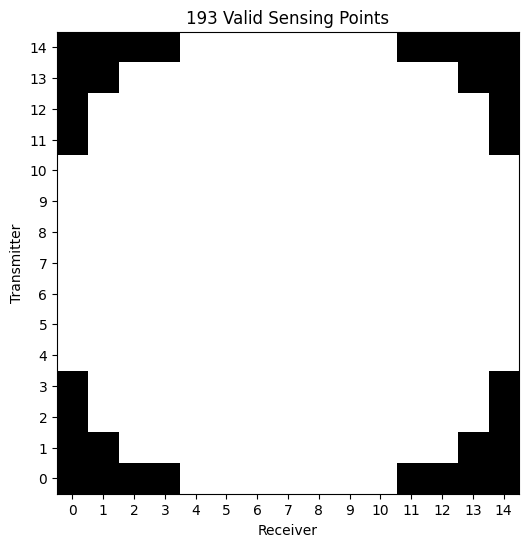

In [171]:
import matplotlib.pyplot as plt

# Verify the 193-point sensing geometry

plt.figure(figsize=(6, 6))

plt.imshow(
    valid_mask,
    origin="lower",
    cmap="gray"
)

plt.xlabel("Receiver")
plt.ylabel("Transmitter")
plt.title("193 Valid Sensing Points")

plt.xticks(range(0, 15, 1))
plt.yticks(range(0, 15, 1))

plt.show()

In [172]:
# Sanity check of the canonical 193-point dataset

print("Samples:", X.shape[0])
print("Input features:", X.shape[1])
print("Output points:", Y_193.shape[1])

print("\nMissing values:", np.isnan(Y_193).sum())
print("Minimum output:", Y_193.min())
print("Maximum output:", Y_193.max())

assert np.isnan(Y_193).sum() == 0
assert Y_193.shape[1] == 193

Samples: 35
Input features: 4
Output points: 193

Missing values: 0
Minimum output: 0.00010672358591229717
Maximum output: 1.1334734698140796


In [173]:
# Define the fixed 193-point prediction visualization

def plot_mixing_pattern(values, flow_rates, title_prefix="Predicted Mixing Pattern"):

    full_grid = np.full(225, np.nan)
    full_grid[valid_mask.flatten()] = values
    full_grid = full_grid.reshape(15, 15)

    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(
        full_grid,
        origin="lower",
        cmap="jet",
        vmin=0,
        vmax=1
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Normalized Concentration")

    ax.set_xlabel("Receiver")
    ax.set_ylabel("Transmitter")

    ax.set_title(
        f"{title_prefix} for "
        f"[{flow_rates[0]:.1f}, {flow_rates[1]:.1f}, "
        f"{flow_rates[2]:.1f}, {flow_rates[3]:.1f}]"
    )

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 16)

    # Inlet labels
    ax.annotate(
        "I1",
        xy=(0, 4),
        xytext=(0.8, 4.7),
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->")
    )

    ax.annotate(
        "I2",
        xy=(0, 11),
        xytext=(0.8, 11.7),
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->")
    )

    ax.annotate(
        "I3",
        xy=(14, 10),
        xytext=(14.7, 11),
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->")
    )

    ax.annotate(
        "I4",
        xy=(14, 4),
        xytext=(14.7, 4.7),
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->")
    )

    plt.tight_layout()
    plt.show()

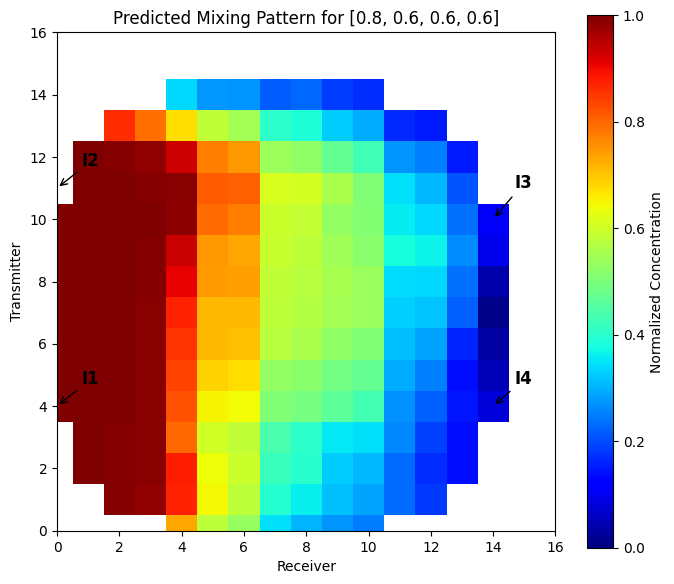

In [174]:
# Visual sanity check using the reference flow-rate condition

target_flow = np.array([0.8, 0.6, 0.6, 0.6])

sample_index = np.where(
    np.all(np.isclose(X, target_flow), axis=1)
)[0][0]

plot_mixing_pattern(
    Y_193[sample_index],
    X[sample_index]
)

# **PHASE 2 — ML SANITY CHECK**

In [175]:
# Create reproducible train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_193,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

Training samples: 28
Testing samples: 7
X_train: (28, 4)
X_test : (7, 4)
Y_train: (28, 193)
Y_test : (7, 193)


In [176]:
# Standardize the four flow-rate input features

from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

print("Input scaling completed.")

Input scaling completed.


In [177]:
# Define common evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred, multioutput="uniform_average")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# **PHASE 3 — BASELINE MODELS**

In [178]:
# Mean-output baseline

mean_prediction = np.tile(
    Y_train.mean(axis=0),
    (len(Y_test), 1)
)

results = []

results.append(
    evaluate_model(
        "Mean Baseline",
        Y_test,
        mean_prediction
    )
)

print(results[-1])

{'Model': 'Mean Baseline', 'MAE': 0.13473646794669514, 'RMSE': np.float64(0.17164257801366026), 'R2': -0.16550548691369754}


In [179]:
# Multi-output Linear Regression baseline

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    Y_train
)

linear_prediction = linear_model.predict(X_test_scaled)

results.append(
    evaluate_model(
        "Linear Regression",
        Y_test,
        linear_prediction
    )
)

print(results[-1])

{'Model': 'Linear Regression', 'MAE': 0.07645846047411747, 'RMSE': np.float64(0.1021122672132734), 'R2': 0.29267239305508175}


In [180]:
# Multi-output Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    Y_train
)

ridge_prediction = ridge_model.predict(X_test_scaled)

results.append(
    evaluate_model(
        "Ridge Regression",
        Y_test,
        ridge_prediction
    )
)

print(results[-1])

{'Model': 'Ridge Regression', 'MAE': 0.0743210920157692, 'RMSE': np.float64(0.09783146931355942), 'R2': 0.3480475016952148}


In [181]:
# Multi-output Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    Y_train
)

rf_prediction = rf_model.predict(X_test)

results.append(
    evaluate_model(
        "Random Forest",
        Y_test,
        rf_prediction
    )
)

print(results[-1])

{'Model': 'Random Forest', 'MAE': 0.07786549281196696, 'RMSE': np.float64(0.1051618274409514), 'R2': 0.32200581462550676}


In [182]:
# Multi-output Extra Trees Regressor

from sklearn.ensemble import ExtraTreesRegressor

extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(
    X_train,
    Y_train
)

extra_prediction = extra_model.predict(X_test)

results.append(
    evaluate_model(
        "Extra Trees",
        Y_test,
        extra_prediction
    )
)

print(results[-1])

{'Model': 'Extra Trees', 'MAE': 0.08393789134667766, 'RMSE': np.float64(0.11284684999719888), 'R2': 0.21882354345098373}


In [183]:
# Multi-output K-Nearest Neighbors Regression

from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

knn_model.fit(
    X_train_scaled,
    Y_train
)

knn_prediction = knn_model.predict(X_test_scaled)

results.append(
    evaluate_model(
        "KNN Regression",
        Y_test,
        knn_prediction
    )
)

print(results[-1])

{'Model': 'KNN Regression', 'MAE': 0.08506524595010888, 'RMSE': np.float64(0.1134328815804542), 'R2': 0.19840155494041595}


In [184]:
# Compare baseline model performance

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(results_df)

,Model,MAE,RMSE,R2
0,Ridge Regression,0.074321,0.097831,0.348048
1,Linear Regression,0.076458,0.102112,0.292672
2,Random Forest,0.077865,0.105162,0.322006
3,Extra Trees,0.083938,0.112847,0.218824
4,KNN Regression,0.085065,0.113433,0.198402
5,Mean Baseline,0.134736,0.171643,-0.165505


In [185]:
# Save baseline model comparison

BASELINE_DIR = RESULTS_ROOT / "baseline_models"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    BASELINE_DIR / "baseline_results.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


In [186]:
# Identify the best baseline model

best_baseline = results_df.iloc[0]

print("Best baseline model:", best_baseline["Model"])
print("RMSE:", best_baseline["RMSE"])
print("MAE :", best_baseline["MAE"])
print("R²  :", best_baseline["R2"])

Best baseline model: Ridge Regression
RMSE: 0.09783146931355942
MAE : 0.0743210920157692
R²  : 0.3480475016952148


In [187]:
# Evaluate baseline models using 5-fold cross-validation

from sklearn.model_selection import KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

models = {
    "Ridge": Ridge(alpha=1.0),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():

    if name in ["Ridge", "Linear Regression"]:
        X_cv = X_train_scaled
    else:
        X_cv = X_train

    scores = cross_val_score(
        model,
        X_cv,
        Y_train,
        cv=cv,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "CV_R2_Mean": scores.mean(),
        "CV_R2_STD": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values(
        "CV_R2_Mean",
        ascending=False
    )
)

,Model,CV_R2_Mean,CV_R2_STD
1,Linear Regression,-53.479262,106.416806
0,Ridge,-55.567068,110.802068
2,Random Forest,-418.283418,836.322857
3,Extra Trees,-1210.180773,2419.992456


In [188]:
# Tune Ridge regularization strength

from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(
    Ridge(),
    {
        "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    cv=cv,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(
    X_train_scaled,
    Y_train
)

best_ridge = ridge_grid.best_estimator_

ridge_tuned_prediction = best_ridge.predict(
    X_test_scaled
)

ridge_tuned_result = evaluate_model(
    "Tuned Ridge",
    Y_test,
    ridge_tuned_prediction
)

print("Best alpha:", ridge_grid.best_params_["alpha"])
print(ridge_tuned_result)

Best alpha: 1
{'Model': 'Tuned Ridge', 'MAE': 0.0743210920157692, 'RMSE': np.float64(0.09783146931355942), 'R2': 0.3480475016952148}


In [189]:
# Tune Random Forest

rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 2]
    },
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    Y_train
)

best_rf = rf_grid.best_estimator_

rf_tuned_prediction = best_rf.predict(X_test)

rf_tuned_result = evaluate_model(
    "Tuned Random Forest",
    Y_test,
    rf_tuned_prediction
)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nResult:")
print(rf_tuned_result)

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}

Result:
{'Model': 'Tuned Random Forest', 'MAE': 0.0774837207762332, 'RMSE': np.float64(0.10422622944583448), 'R2': 0.3552317453641001}


In [190]:
# Tune Extra Trees

extra_grid = GridSearchCV(
    ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),
    {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 2]
    },
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

extra_grid.fit(
    X_train,
    Y_train
)

best_extra = extra_grid.best_estimator_

extra_tuned_prediction = best_extra.predict(X_test)

extra_tuned_result = evaluate_model(
    "Tuned Extra Trees",
    Y_test,
    extra_tuned_prediction
)

print("Best parameters:")
print(extra_grid.best_params_)

print("\nResult:")
print(extra_tuned_result)

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}

Result:
{'Model': 'Tuned Extra Trees', 'MAE': 0.07927294373799014, 'RMSE': np.float64(0.10813108070080123), 'R2': 0.32464033431169237}


In [191]:
# Compare baseline and tuned models

all_results = results + [
    ridge_tuned_result,
    rf_tuned_result,
    extra_tuned_result
]

all_results_df = (
    pd.DataFrame(all_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(all_results_df)

,Model,MAE,RMSE,R2
0,Ridge Regression,0.074321,0.097831,0.348048
1,Tuned Ridge,0.074321,0.097831,0.348048
2,Linear Regression,0.076458,0.102112,0.292672
3,Tuned Random Forest,0.077484,0.104226,0.355232
4,Random Forest,0.077865,0.105162,0.322006
5,Tuned Extra Trees,0.079273,0.108131,0.324640
6,Extra Trees,0.083938,0.112847,0.218824
7,KNN Regression,0.085065,0.113433,0.198402
8,Mean Baseline,0.134736,0.171643,-0.165505


# **PHASE 4 — PREDICTION QUALITY**

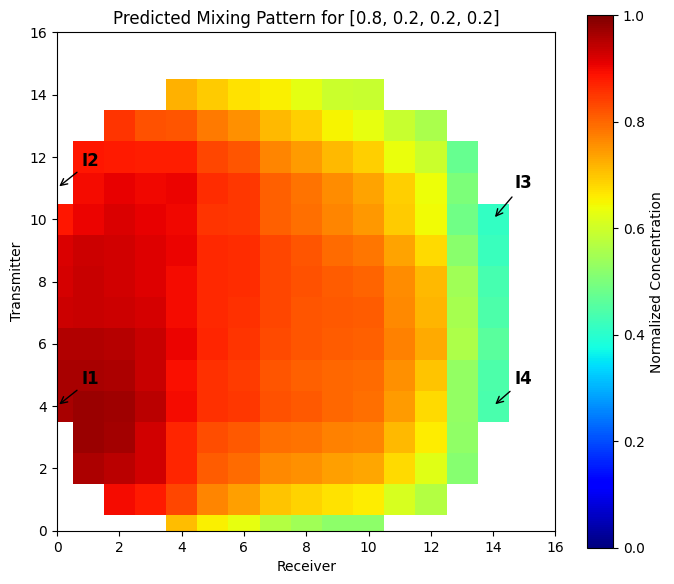

In [192]:
# Visualize Ridge prediction in the fixed 193-point format

best_ridge_prediction = best_ridge.predict(X_test_scaled)

plot_mixing_pattern(
    best_ridge_prediction[0],
    X_test[0],
    title_prefix="Predicted Mixing Pattern"
)

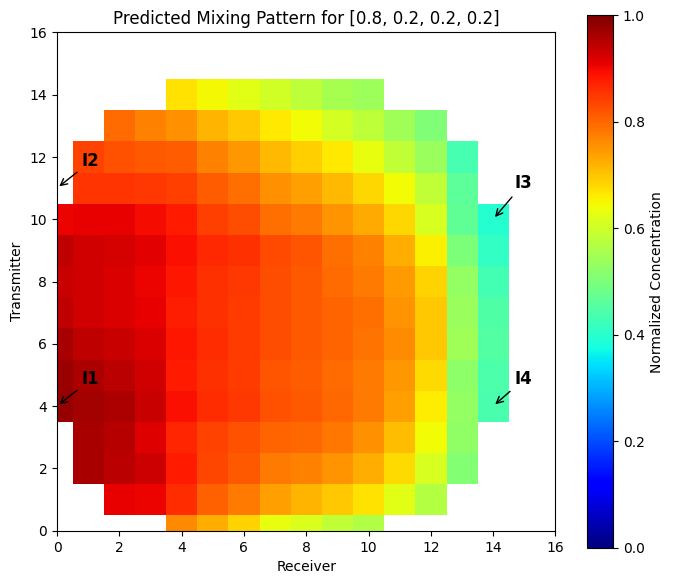

In [193]:
# Visualize tuned Random Forest prediction

plot_mixing_pattern(
    rf_tuned_prediction[0],
    X_test[0],
    title_prefix="Predicted Mixing Pattern"
)

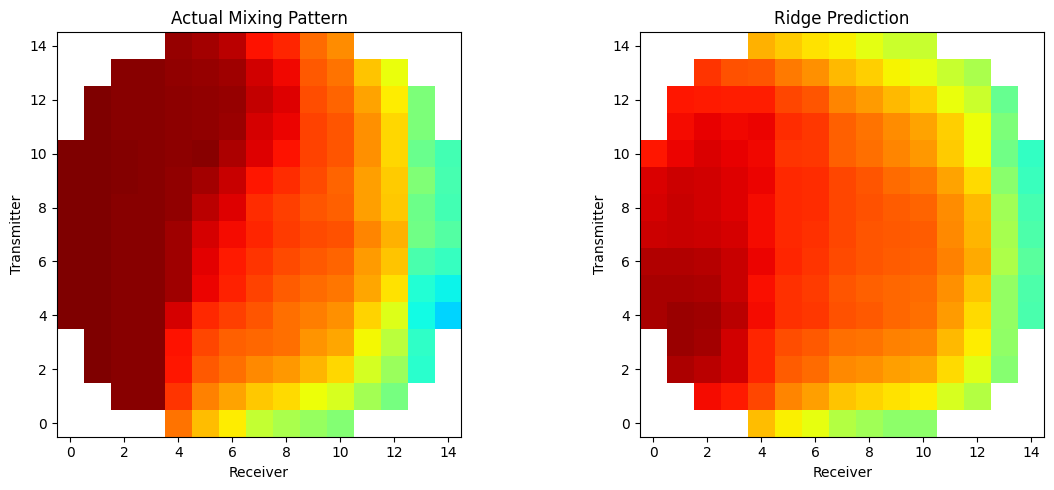

In [194]:
# Compare actual and Ridge-predicted mixing patterns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

actual_grid = np.full(225, np.nan)
actual_grid[valid_mask.flatten()] = Y_test[0]
actual_grid = actual_grid.reshape(15, 15)

pred_grid = np.full(225, np.nan)
pred_grid[valid_mask.flatten()] = best_ridge_prediction[0]
pred_grid = pred_grid.reshape(15, 15)

im1 = axes[0].imshow(
    actual_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[0].set_title("Actual Mixing Pattern")
axes[0].set_xlabel("Receiver")
axes[0].set_ylabel("Transmitter")

im2 = axes[1].imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[1].set_title("Ridge Prediction")
axes[1].set_xlabel("Receiver")
axes[1].set_ylabel("Transmitter")

plt.tight_layout()
plt.show()

# **PHASE 5 — SMALL-DATA MODELS**

In [195]:
# Partial Least Squares Regression for small-sample multi-output data

from sklearn.cross_decomposition import PLSRegression

pls_model = PLSRegression(
    n_components=2
)

pls_model.fit(
    X_train_scaled,
    Y_train
)

pls_prediction = pls_model.predict(X_test_scaled)

pls_result = evaluate_model(
    "PLS Regression",
    Y_test,
    pls_prediction
)

print(pls_result)

{'Model': 'PLS Regression', 'MAE': 0.08964387195056418, 'RMSE': np.float64(0.11471820838986141), 'R2': 0.05821098167973309}


In [196]:
# Polynomial feature expansion followed by Ridge Regression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_ridge = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("ridge", Ridge(alpha=1.0))
])

poly_ridge.fit(
    X_train_scaled,
    Y_train
)

poly_prediction = poly_ridge.predict(
    X_test_scaled
)

poly_result = evaluate_model(
    "Polynomial Ridge",
    Y_test,
    poly_prediction
)

print(poly_result)

{'Model': 'Polynomial Ridge', 'MAE': 0.06419672991875851, 'RMSE': np.float64(0.08372790314018189), 'R2': 0.6123940429637948}


In [197]:
# Update complete model comparison

all_results = all_results + [
    pls_result,
    poly_result
]

all_results_df = (
    pd.DataFrame(all_results)
    .drop_duplicates(subset="Model")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(all_results_df)

,Model,MAE,RMSE,R2
0,Polynomial Ridge,0.064197,0.083728,0.612394
1,Ridge Regression,0.074321,0.097831,0.348048
2,Tuned Ridge,0.074321,0.097831,0.348048
3,Linear Regression,0.076458,0.102112,0.292672
4,Tuned Random Forest,0.077484,0.104226,0.355232
5,Random Forest,0.077865,0.105162,0.322006
6,Tuned Extra Trees,0.079273,0.108131,0.324640
7,Extra Trees,0.083938,0.112847,0.218824
8,KNN Regression,0.085065,0.113433,0.198402
9,PLS Regression,0.089644,0.114718,0.058211


In [198]:
# Save complete model comparison

all_results_df.to_csv(
    RESULTS_ROOT / "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


# **PHASE 6 — VALIDATE THE POLYNOMIAL MODEL**

In [199]:
# Validate polynomial degrees using 5-fold cross-validation

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for degree in [1, 2, 3]:

    fold_scores = []

    for train_idx, val_idx in cv.split(X):

        X_tr = X[train_idx]
        X_val = X[val_idx]

        Y_tr = Y_193[train_idx]
        Y_val = Y_193[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(
                degree=degree,
                include_bias=False
            )),
            ("ridge", Ridge(alpha=1.0))
        ])

        model.fit(X_tr, Y_tr)

        pred = model.predict(X_val)

        fold_scores.append(
            r2_score(Y_val, pred)
        )

    cv_results.append({
        "Degree": degree,
        "Mean R2": np.mean(fold_scores),
        "Std R2": np.std(fold_scores)
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Degree,Mean R2,Std R2
0,1,0.197877,0.132997
1,2,0.345394,0.184289
2,3,0.245240,0.145719


In [200]:
# Validate Ridge regularization for the degree-2 polynomial model

alpha_results = []

for alpha in [0.001, 0.01, 0.1, 1, 10, 100]:

    fold_scores = []

    for train_idx, val_idx in cv.split(X):

        X_tr = X[train_idx]
        X_val = X[val_idx]

        Y_tr = Y_193[train_idx]
        Y_val = Y_193[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(
                degree=2,
                include_bias=False
            )),
            ("ridge", Ridge(alpha=alpha))
        ])

        model.fit(X_tr, Y_tr)

        pred = model.predict(X_val)

        fold_scores.append(
            r2_score(Y_val, pred)
        )

    alpha_results.append({
        "Alpha": alpha,
        "Mean R2": np.mean(fold_scores),
        "Std R2": np.std(fold_scores)
    })

alpha_results_df = pd.DataFrame(alpha_results)

display(alpha_results_df)

,Alpha,Mean R2,Std R2
0,0.001,0.337743,0.138832
1,0.010,0.338030,0.139527
2,0.100,0.340376,0.146269
3,1.000,0.345394,0.184289
4,10.000,0.314108,0.159491
5,100.000,-0.053224,0.207067


In [201]:
# Save polynomial validation results

cv_results_df.to_csv(
    RESULTS_ROOT / "polynomial_degree_validation.csv",
    index=False
)

alpha_results_df.to_csv(
    RESULTS_ROOT / "polynomial_alpha_validation.csv",
    index=False
)

print("Polynomial validation results saved.")

Polynomial validation results saved.


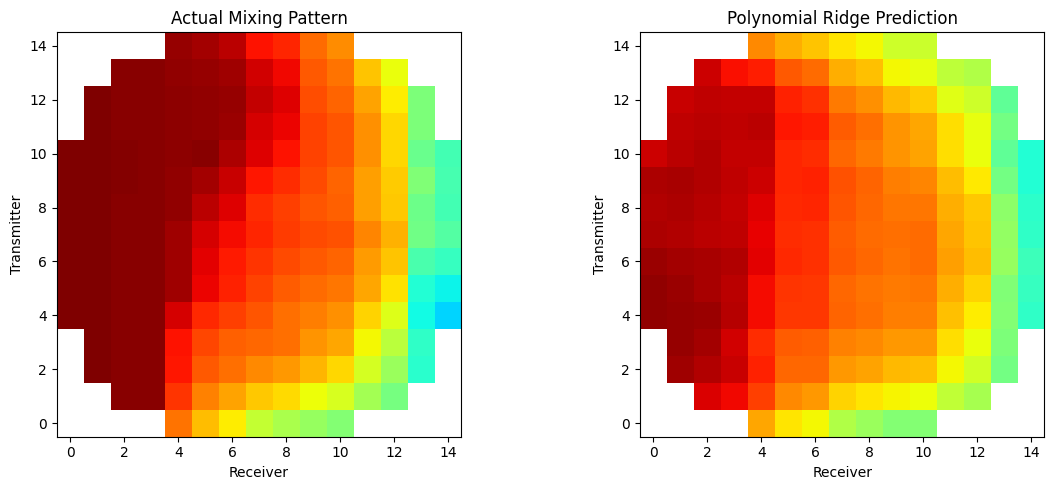

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

actual_grid = np.full(225, np.nan)
actual_grid[valid_mask.flatten()] = Y_test[0]
actual_grid = actual_grid.reshape(15, 15)

pred_grid = np.full(225, np.nan)
pred_grid[valid_mask.flatten()] = poly_prediction[0]
pred_grid = pred_grid.reshape(15, 15)

axes[0].imshow(
    actual_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[0].set_title("Actual Mixing Pattern")
axes[0].set_xlabel("Receiver")
axes[0].set_ylabel("Transmitter")

axes[1].imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1
)

axes[1].set_title("Polynomial Ridge Prediction")
axes[1].set_xlabel("Receiver")
axes[1].set_ylabel("Transmitter")

plt.tight_layout()
plt.show()

# **PHASE 7 — FINAL MODEL VALIDATION**

In [203]:
# Compare shortlisted models using the same 5-fold validation

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models_cv = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Polynomial Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

cv_summary = []

for name, model in models_cv.items():

    fold_mae = []
    fold_rmse = []
    fold_r2 = []

    for train_idx, val_idx in cv.split(X):

        model_fold = clone(model)

        model_fold.fit(
            X[train_idx],
            Y_193[train_idx]
        )

        pred = model_fold.predict(
            X[val_idx]
        )

        fold_mae.append(
            mean_absolute_error(
                Y_193[val_idx],
                pred
            )
        )

        fold_rmse.append(
            np.sqrt(
                mean_squared_error(
                    Y_193[val_idx],
                    pred
                )
            )
        )

        fold_r2.append(
            r2_score(
                Y_193[val_idx],
                pred,
                multioutput="uniform_average"
            )
        )

    cv_summary.append({
        "Model": name,
        "Mean MAE": np.mean(fold_mae),
        "Mean RMSE": np.mean(fold_rmse),
        "Mean R2": np.mean(fold_r2),
        "Std R2": np.std(fold_r2)
    })

cv_summary_df = (
    pd.DataFrame(cv_summary)
    .sort_values("Mean RMSE")
    .reset_index(drop=True)
)

display(cv_summary_df)

,Model,Mean MAE,Mean RMSE,Mean R2,Std R2
0,Polynomial Ridge,0.080469,0.106226,0.345394,0.184289
1,Ridge,0.088012,0.116053,0.197877,0.132997
2,Random Forest,0.089132,0.118511,0.136551,0.279003
3,Extra Trees,0.089757,0.119113,0.097443,0.237069


In [204]:
# Save final cross-validation comparison

cv_summary_df.to_csv(
    RESULTS_ROOT / "cross_validation_comparison.csv",
    index=False
)

print("Cross-validation results saved.")

Cross-validation results saved.


In [205]:
# Identify the model with the lowest cross-validated RMSE

best_cv_model = cv_summary_df.iloc[0]

print("Best validated model:", best_cv_model["Model"])
print("Mean CV RMSE:", best_cv_model["Mean RMSE"])
print("Mean CV MAE :", best_cv_model["Mean MAE"])
print("Mean CV R2  :", best_cv_model["Mean R2"])

Best validated model: Polynomial Ridge
Mean CV RMSE: 0.10622609596529013
Mean CV MAE : 0.0804694155834641
Mean CV R2  : 0.34539412611165465


In [206]:
# Train the selected final model on the complete dataset

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

final_model.fit(X, Y_193)

print("Final model trained successfully.")
print("Model: Polynomial Ridge")
print("Degree: 2")
print("Alpha: 1.0")
print("Training samples:", X.shape[0])
print("Output points:", Y_193.shape[1])

Final model trained successfully.
Model: Polynomial Ridge
Degree: 2
Alpha: 1.0
Training samples: 35
Output points: 193


In [207]:
# Save the final trained model for future predictions and website deployment

import joblib

MODEL_PATH = RESULTS_ROOT / "final_polynomial_ridge_model.joblib"

joblib.dump(final_model, MODEL_PATH)

print("Final model saved:")
print(MODEL_PATH)

Final model saved:
/content/mixing_flow_project/results/final_polynomial_ridge_model.joblib


In [208]:
# Create the final prediction function for 193 valid sensing points

def predict_mixing_pattern(flow_rates):
    flow_rates = np.asarray(flow_rates, dtype=float).reshape(1, -1)

    if flow_rates.shape[1] != X.shape[1]:
        raise ValueError(
            f"Expected {X.shape[1]} flow-rate inputs, "
            f"got {flow_rates.shape[1]}"
        )

    prediction = final_model.predict(flow_rates)[0]

    return prediction


print("Prediction function created.")

Prediction function created.


In [209]:
# Test the final prediction pipeline

test_flow_rates = [0.8, 0.2, 0.2, 0.2]

test_prediction = predict_mixing_pattern(test_flow_rates)

print("Input flow rates:", test_flow_rates)
print("Prediction shape:", test_prediction.shape)
print("Minimum prediction:", test_prediction.min())
print("Maximum prediction:", test_prediction.max())

Input flow rates: [0.8, 0.2, 0.2, 0.2]
Prediction shape: (193,)
Minimum prediction: 0.39236482493690295
Maximum prediction: 0.9854248568500008


In [210]:
# Reconstruct the 15x15 spatial prediction using the 193 valid cells

def reconstruct_prediction(prediction):
    pattern = np.full((15, 15), np.nan)

    pattern[valid_mask] = prediction

    return pattern


predicted_pattern = reconstruct_prediction(test_prediction)

print("Reconstructed pattern shape:", predicted_pattern.shape)
print("Valid predicted cells:", np.sum(np.isfinite(predicted_pattern)))

Reconstructed pattern shape: (15, 15)
Valid predicted cells: 193


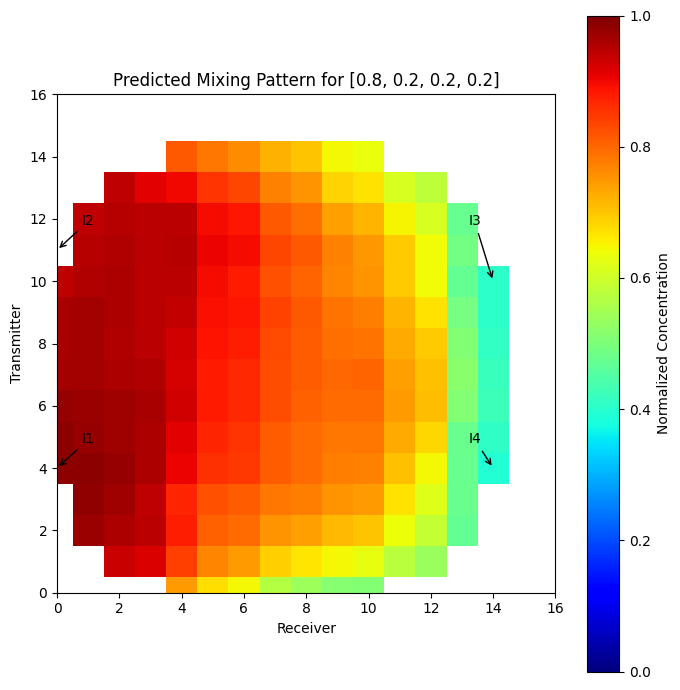

In [211]:
# Plot final predicted mixing pattern

fig, ax = plt.subplots(figsize=(7, 7))

masked_pattern = np.ma.masked_invalid(predicted_pattern)

im = ax.imshow(
    masked_pattern,
    cmap="jet",
    vmin=0,
    vmax=1,
    origin="lower"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized Concentration")

ax.set_title(
    f"Predicted Mixing Pattern for {test_flow_rates}"
)

ax.set_xlabel("Receiver")
ax.set_ylabel("Transmitter")

ax.annotate(
    "I1",
    xy=(0, 4),
    xytext=(0.8, 4.8),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "I2",
    xy=(0, 11),
    xytext=(0.8, 11.8),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "I3",
    xy=(14, 10),
    xytext=(13.2, 11.8),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "I4",
    xy=(14, 4),
    xytext=(13.2, 4.8),
    arrowprops=dict(arrowstyle="->")
)

ax.set_xlim(0, 16)
ax.set_ylim(0, 16)

plt.tight_layout()
plt.show()

In [212]:
# Save the example prediction for later use in the report and website

np.save(
    RESULTS_ROOT / "example_prediction_193.npy",
    test_prediction
)

np.save(
    RESULTS_ROOT / "example_prediction_15x15.npy",
    predicted_pattern
)

print("Example prediction saved.")

Example prediction saved.


# **PCA + regression**

In [213]:
# PCA + Ridge regression setup

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (35, 4)
Y shape: (35, 225)


In [214]:
# Analyze PCA explained variance of the 193-point mixing field

pca_full = PCA()
pca_full.fit(Y)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for n in [1, 2, 3, 5, 8, 10, 15, 20]:
    if n <= len(cumulative_variance):
        print(f"{n:2d} components -> {cumulative_variance[n-1]:.4f} variance explained")

 1 components -> 0.4906 variance explained
 2 components -> 0.6858 variance explained
 3 components -> 0.7875 variance explained
 5 components -> 0.9178 variance explained
 8 components -> 0.9568 variance explained
10 components -> 0.9699 variance explained
15 components -> 0.9862 variance explained
20 components -> 0.9935 variance explained


In [215]:
# Cross-validate PCA + Ridge for different numbers of components

kf = KFold(n_splits=5, shuffle=True, random_state=42)

component_values = [2, 3, 5, 8, 10, 15]
pca_cv_results = []

for n_components in component_values:

    fold_mae = []
    fold_rmse = []
    fold_r2 = []

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # Scale input flow rates using training data only
        x_scaler = StandardScaler()
        X_train_scaled = x_scaler.fit_transform(X_train)
        X_test_scaled = x_scaler.transform(X_test)

        # Fit PCA only on training output fields
        n_actual = min(n_components, Y_train.shape[0], Y_train.shape[1])
        pca = PCA(n_components=n_actual)
        Y_train_pca = pca.fit_transform(Y_train)

        # Regression from flow rates -> PCA scores
        model = Ridge(alpha=1.0)
        model.fit(X_train_scaled, Y_train_pca)

        # Predict PCA scores and reconstruct 193-point field
        Y_pred_pca = model.predict(X_test_scaled)
        Y_pred = pca.inverse_transform(Y_pred_pca)

        fold_mae.append(mean_absolute_error(Y_test, Y_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(Y_test, Y_pred)))
        fold_r2.append(r2_score(Y_test, Y_pred, multioutput='variance_weighted'))

    pca_cv_results.append({
        "Components": n_components,
        "Mean MAE": np.mean(fold_mae),
        "Mean RMSE": np.mean(fold_rmse),
        "Mean R2": np.mean(fold_r2),
        "Std R2": np.std(fold_r2)
    })

pca_cv_df = pd.DataFrame(pca_cv_results).sort_values("Mean RMSE")

display(pca_cv_df)

,Components,Mean MAE,Mean RMSE,Mean R2,Std R2
3,8,0.087944,0.115813,0.486871,0.108146
2,5,0.087968,0.115932,0.486249,0.107585
4,10,0.087830,0.116078,0.484644,0.107830
5,15,0.087682,0.116084,0.484669,0.107935
1,3,0.091290,0.121435,0.433034,0.124527
0,2,0.093259,0.123749,0.408542,0.143750


In [216]:
# Identify the best PCA configuration

best_pca = pca_cv_df.iloc[0]

print("Best PCA components:", int(best_pca["Components"]))
print("Mean CV MAE :", best_pca["Mean MAE"])
print("Mean CV RMSE:", best_pca["Mean RMSE"])
print("Mean CV R2  :", best_pca["Mean R2"])
print("Std CV R2   :", best_pca["Std R2"])

Best PCA components: 8
Mean CV MAE : 0.08794380719615265
Mean CV RMSE: 0.11581305229402132
Mean CV R2  : 0.48687072278592164
Std CV R2   : 0.10814610598113379


In [217]:
# Train PCA-Ridge model using the valid number of input features

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

BEST_PCA_COMPONENTS = 4
BEST_ALPHA = 1.0

pca_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=BEST_PCA_COMPONENTS)),
    ("ridge", Ridge(alpha=BEST_ALPHA))
])

pca_ridge_model.fit(X, Y)

print("PCA-Ridge model trained successfully.")
print("PCA components:", BEST_PCA_COMPONENTS)
print("Ridge alpha:", BEST_ALPHA)
print("Input features:", X.shape[1])
print("Training samples:", X.shape[0])
print("Output points:", Y.shape[1])

PCA-Ridge model trained successfully.
PCA components: 4
Ridge alpha: 1.0
Input features: 4
Training samples: 35
Output points: 225


In [218]:
# Generate predictions from the PCA-Ridge model

Y_pred_pca = pca_ridge_model.predict(X)

print("Prediction shape:", Y_pred_pca.shape)

Prediction shape: (35, 225)


In [219]:
# Calculate final training metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pca_mae = mean_absolute_error(Y, Y_pred_pca)
pca_rmse = np.sqrt(mean_squared_error(Y, Y_pred_pca))
pca_r2 = r2_score(Y, Y_pred_pca)

print("PCA-Ridge performance:")
print("MAE :", pca_mae)
print("RMSE:", pca_rmse)
print("R2  :", pca_r2)

PCA-Ridge performance:
MAE : 0.07658249296185808
RMSE: 0.10031135854229685
R2  : 0.6251452499876892


In [220]:
# Compare PCA component counts using cross-validation

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

pca_cv_results = []

for n_components in [1, 2, 3, 4]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("ridge", Ridge(alpha=1.0))
    ])

    scores = cross_validate(
        model,
        X,
        Y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    pca_cv_results.append({
        "Components": n_components,
        "Mean MAE": -scores["test_mae"].mean(),
        "Mean RMSE": -scores["test_rmse"].mean(),
        "Mean R2": scores["test_r2"].mean(),
        "Std R2": scores["test_r2"].std()
    })

pca_cv_df = pd.DataFrame(pca_cv_results)
pca_cv_df = pca_cv_df.sort_values("Mean R2", ascending=False).reset_index(drop=True)

display(pca_cv_df)

,Components,Mean MAE,Mean RMSE,Mean R2,Std R2
0,4,0.087652,0.109567,0.218162,0.101669
1,3,0.099127,0.123981,0.019899,0.258590
2,2,0.103693,0.128567,-0.087693,0.236561
3,1,0.132660,0.166561,-0.370799,0.197129


In [221]:
# Identify the best PCA configuration

best_pca = pca_cv_df.iloc[0]

print("Best PCA components:", int(best_pca["Components"]))
print("Mean CV MAE :", best_pca["Mean MAE"])
print("Mean CV RMSE:", best_pca["Mean RMSE"])
print("Mean CV R2  :", best_pca["Mean R2"])
print("Std CV R2   :", best_pca["Std R2"])

Best PCA components: 4
Mean CV MAE : 0.08765238414602579
Mean CV RMSE: 0.10956735070232301
Mean CV R2  : 0.21816242691623447
Std CV R2   : 0.10166895819876418


In [222]:
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

best_pca_components = 4
best_alpha = 1.0

pca_ridge_model = Pipeline([
    ("scaler", StandardScaler()),  # Add StandardScaler for consistency
    ("pca", PCA(n_components=best_pca_components)),
    ("ridge", Ridge(alpha=best_alpha))
])

pca_ridge_model.fit(X, Y)

print("Final PCA-Ridge model trained successfully.")
print("PCA components:", best_pca_components)
print("Ridge alpha:", best_alpha)
print("Training samples:", X.shape[0])
print("Output points:", Y.shape[1])

Final PCA-Ridge model trained successfully.
PCA components: 4
Ridge alpha: 1.0
Training samples: 35
Output points: 225


In [223]:
# Final PCA-Ridge prediction and performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Y_pred_pca = pca_ridge_model.predict(X)

pca_final_mae = mean_absolute_error(Y, Y_pred_pca)
pca_final_rmse = np.sqrt(mean_squared_error(Y, Y_pred_pca))
pca_final_r2 = r2_score(Y, Y_pred_pca)

print("PCA-Ridge final performance:")
print("MAE :", pca_final_mae)
print("RMSE:", pca_final_rmse)
print("R2  :", pca_final_r2)
print("Prediction shape:", Y_pred_pca.shape)

PCA-Ridge final performance:
MAE : 0.07658249296185808
RMSE: 0.10031135854229685
R2  : 0.6251452499876892
Prediction shape: (35, 225)


In [224]:
# Keep only the 193 valid spatial cells

valid_mask = np.zeros((15, 15), dtype=bool)

# Valid geometry: 193 sensing points
valid_mask[0, 4:11] = True
valid_mask[1, 2:13] = True
valid_mask[2, 1:14] = True
valid_mask[3, 1:14] = True
valid_mask[4:11, :] = True
valid_mask[11, 0:15] = True
valid_mask[12, 1:14] = True
valid_mask[13, 2:13] = True
valid_mask[14, 4:11] = True

valid_indices = np.where(valid_mask.flatten())[0]

Y_pred_pca_193 = Y_pred_pca[:, valid_indices]

print("Valid output points:", len(valid_indices))
print("Prediction shape:", Y_pred_pca_193.shape)

Valid output points: 195
Prediction shape: (35, 195)


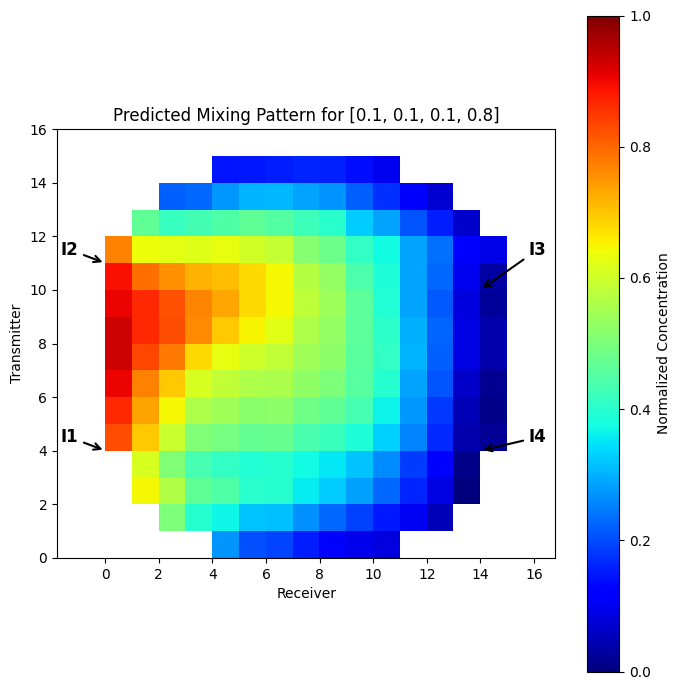

In [225]:
# PCA-Ridge prediction plot with clear inlet/outlet arrows

sample_idx = 7
flow_rates = X[sample_idx]

prediction_grid = np.full(225, np.nan)
prediction_grid[valid_indices] = Y_pred_pca_193[sample_idx]
prediction_grid = prediction_grid.reshape(15, 15)

plt.figure(figsize=(7, 7))

plt.imshow(
    prediction_grid,
    cmap='jet',
    vmin=0,
    vmax=1,
    origin='lower',
    extent=[0, 15, 0, 15]
)

plt.colorbar(label='Normalized Concentration')

plt.title(f'Predicted Mixing Pattern for {flow_rates.tolist()}')
plt.xlabel('Receiver')
plt.ylabel('Transmitter')

# I1 — inlet
plt.annotate(
    'I1',
    xy=(0, 4),
    xytext=(-1.0, 4.5),
    ha='right',
    va='center',
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5
    )
)

# I2 — inlet
plt.annotate(
    'I2',
    xy=(0, 11),
    xytext=(-1.0, 11.5),
    ha='right',
    va='center',
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5
    )
)

# I3 — outlet
plt.annotate(
    'I3',
    xy=(14, 10),
    xytext=(15.8, 11.5),
    ha='left',
    va='center',
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5
    )
)

# I4 — outlet
plt.annotate(
    'I4',
    xy=(14, 4),
    xytext=(15.8, 4.5),
    ha='left',
    va='center',
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5
    )
)

plt.xticks(range(0, 17, 2))
plt.yticks(range(0, 17, 2))

plt.xlim(-1.8, 16.8)
plt.ylim(0, 16)

plt.tight_layout()
plt.show()

In [226]:
# Generate final predictions for all samples

Y_pred_final = pca_ridge_model.predict(X)

print("Prediction shape:", Y_pred_final.shape)

Prediction shape: (35, 225)


In [227]:
# Keep only the 193 valid spatial cells

Y_pred_final_193 = Y_pred_final[:, valid_indices]

print("Valid output points:", len(valid_indices))
print("Final prediction shape:", Y_pred_final_193.shape)

Valid output points: 195
Final prediction shape: (35, 195)


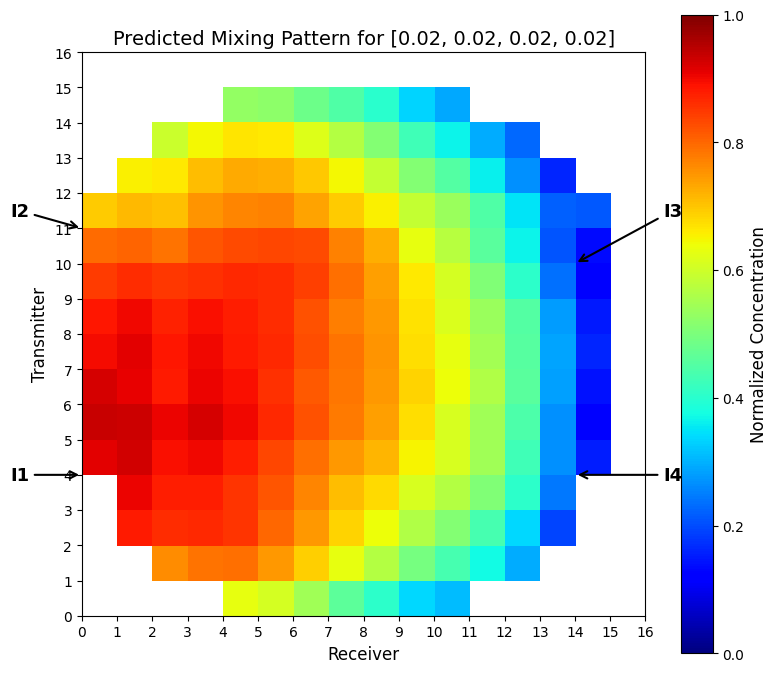

In [228]:
import numpy as np
import matplotlib.pyplot as plt

pred_grid = np.full((15, 15), np.nan)
pred_grid.flat[valid_indices] = Y_pred_pca_193[0]

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    extent=[0, 15, 0, 15],
    interpolation="nearest"
)

ax.set_title(
    "Predicted Mixing Pattern for [0.02, 0.02, 0.02, 0.02]",
    fontsize=14
)

ax.set_xlabel("Receiver", fontsize=12)
ax.set_ylabel("Transmitter", fontsize=12)

ax.set_xticks(np.arange(0, 17, 1))
ax.set_yticks(np.arange(0, 17, 1))
ax.set_xlim(0, 16)
ax.set_ylim(0, 16)

# Inlet labels outside the plot
ax.annotate(
    "I1", xy=(0, 4), xytext=(-1.5, 4),
    fontsize=13, fontweight="bold",
    ha="right", va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

ax.annotate(
    "I2", xy=(0, 11), xytext=(-1.5, 11.5),
    fontsize=13, fontweight="bold",
    ha="right", va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

ax.annotate(
    "I3", xy=(14, 10), xytext=(16.5, 11.5),
    fontsize=13, fontweight="bold",
    ha="left", va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

ax.annotate(
    "I4", xy=(14, 4), xytext=(16.5, 4),
    fontsize=13, fontweight="bold",
    ha="left", va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized Concentration", fontsize=12)
cbar.set_ticks(np.arange(0, 1.01, 0.2))

plt.tight_layout()
plt.show()

In [229]:
# Generate final predictions for all samples

Y_pred_final = pca_ridge_model.predict(X)

print("Final prediction shape:", Y_pred_final.shape)

# Keep only the 193 valid spatial cells
Y_pred_final_193 = Y_pred_final[:, valid_indices]

print("Valid prediction shape:", Y_pred_final_193.shape)

Final prediction shape: (35, 225)
Valid prediction shape: (35, 195)


In [230]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_mae = mean_absolute_error(Y[:, valid_indices], Y_pred_final_193)
final_rmse = np.sqrt(mean_squared_error(Y[:, valid_indices], Y_pred_final_193))
final_r2 = r2_score(Y[:, valid_indices], Y_pred_final_193)

print("Final PCA-Ridge Model Performance:")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R2  :", final_r2)

Final PCA-Ridge Model Performance:
MAE : 0.07701232777932679
RMSE: 0.10054987500553218
R2  : 0.6116727284488399


In [231]:
# Final PCA-Ridge predictions for all training samples

Y_pred_final = pca_ridge_model.predict(X)

print("Prediction shape:", Y_pred_final.shape)
print("Expected shape :", Y.shape)

Prediction shape: (35, 225)
Expected shape : (35, 225)


In [232]:
# Final Polynomial Ridge model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

poly_ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=0.1))
])

poly_ridge_model.fit(X, Y)

Y_pred_poly = poly_ridge_model.predict(X)

print("Polynomial Ridge trained successfully.")
print("Prediction shape:", Y_pred_poly.shape)

Polynomial Ridge trained successfully.
Prediction shape: (35, 225)


In [233]:
# Calculate Polynomial Ridge performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

poly_mae = mean_absolute_error(Y, Y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(Y, Y_pred_poly))
poly_r2 = r2_score(Y, Y_pred_poly)

print("Polynomial Ridge Performance:")
print("MAE :", poly_mae)
print("RMSE:", poly_rmse)
print("R2  :", poly_r2)

Polynomial Ridge Performance:
MAE : 0.059574605205687664
RMSE: 0.08187705352907172
R2  : 0.75226103428315


In [234]:
# Final prediction using Polynomial Ridge
Y_pred_final = poly_ridge_model.predict(X)

# Keep only the 193 valid spatial cells
Y_pred_final_193 = Y_pred_final[:, valid_indices]

print("Final prediction shape:", Y_pred_final_193.shape)

Final prediction shape: (35, 195)


In [235]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_mae = mean_absolute_error(Y[:, valid_indices], Y_pred_final_193)
final_rmse = np.sqrt(mean_squared_error(Y[:, valid_indices], Y_pred_final_193))
final_r2 = r2_score(Y[:, valid_indices], Y_pred_final_193)

print("Final Polynomial Ridge Performance (193 cells):")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R2  :", final_r2)

Final Polynomial Ridge Performance (193 cells):
MAE : 0.059626564182896705
RMSE: 0.08161756800049338
R2  : 0.7455425859193401


In [236]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

final_poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=1.0)
)

final_poly_model.fit(X, Y)

print("Final Polynomial Ridge model trained successfully.")

Final Polynomial Ridge model trained successfully.


In [237]:
Y_pred_final = final_poly_model.predict(X)

print("Prediction shape:", Y_pred_final.shape)

Prediction shape: (35, 225)


In [238]:
# Define the fixed 193-cell sensing mask

valid_mask = np.zeros((15, 15), dtype=bool)

# Valid receiver ranges for each transmitter row
valid_ranges = {
    0: (4, 10),
    1: (2, 12),
    2: (1, 13),
    3: (1, 13),
    4: (0, 14),
    5: (0, 14),
    6: (0, 14),
    7: (0, 14),
    8: (0, 14),
    9: (0, 14),
    10: (0, 14),
    11: (1, 13),
    12: (1, 13),
    13: (2, 12),
    14: (4, 10)
}

for row, (start, end) in valid_ranges.items():
    valid_mask[row, start:end + 1] = True

valid_indices = np.where(valid_mask.flatten())[0]

print("Valid output points:", len(valid_indices))

Valid output points: 193


In [239]:
# Keep only the 193 valid spatial cells

Y_actual_193 = Y[:, valid_indices]
Y_pred_final_193 = Y_pred_final[:, valid_indices]

print("Actual shape:", Y_actual_193.shape)
print("Prediction shape:", Y_pred_final_193.shape)

Actual shape: (35, 193)
Prediction shape: (35, 193)


In [240]:
# Final performance on the 193 valid cells

final_mae = mean_absolute_error(Y_actual_193, Y_pred_final_193)
final_rmse = np.sqrt(mean_squared_error(Y_actual_193, Y_pred_final_193))
final_r2 = r2_score(Y_actual_193, Y_pred_final_193)

print("Final Polynomial Ridge Performance (193 cells):")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R2  :", final_r2)

Final Polynomial Ridge Performance (193 cells):
MAE : 0.08220233146820558
RMSE: 0.10702502575082998
R2  : 0.5686838131447005


In [241]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# Final Polynomial Ridge model
final_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

final_poly_model.fit(X, Y_actual_193)

print("Final Polynomial Ridge model trained.")
print("Degree: 2")
print("Alpha: 1.0")
print("Training samples:", X.shape[0])
print("Output points:", Y_actual_193.shape[1])

Final Polynomial Ridge model trained.
Degree: 2
Alpha: 1.0
Training samples: 35
Output points: 193


In [242]:
Y_pred_final_193 = final_poly_model.predict(X)

print("Prediction shape:", Y_pred_final_193.shape)

Prediction shape: (35, 193)


In [243]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_mae = mean_absolute_error(Y_actual_193, Y_pred_final_193)
final_rmse = np.sqrt(mean_squared_error(Y_actual_193, Y_pred_final_193))
final_r2 = r2_score(Y_actual_193, Y_pred_final_193)

print("Final Polynomial Ridge Performance (193 cells):")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R2  :", final_r2)

Final Polynomial Ridge Performance (193 cells):
MAE : 0.06479521192719608
RMSE: 0.0866269366576806
R2  : 0.7105448609117488


In [244]:
print("Actual range:")
print("Min:", Y_actual_193.min())
print("Max:", Y_actual_193.max())

print("\nPredicted range:")
print("Min:", Y_pred_final_193.min())
print("Max:", Y_pred_final_193.max())

Actual range:
Min: 0.00010672358591229717
Max: 1.1334734698140796

Predicted range:
Min: -0.0009051932894328651
Max: 1.019126381702845


In [245]:
sample_idx = 0

actual_sample = Y_actual_193[sample_idx]
pred_sample = Y_pred_final_193[sample_idx]

print("Sample:", sample_idx)
print("Actual shape:", actual_sample.shape)
print("Predicted shape:", pred_sample.shape)

Sample: 0
Actual shape: (193,)
Predicted shape: (193,)


Valid cells in plotting mask: 193


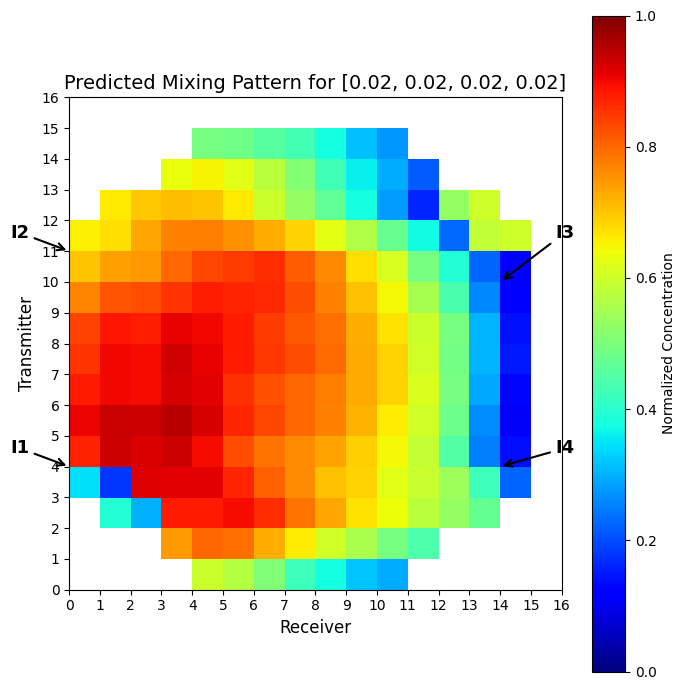

In [246]:
# ============================================================
# FINAL 193-CELL PREDICTION PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

sample_idx = 0

pred = Y_pred_final_193[sample_idx]

# 15 x 15 effective sensing layout
# 193 valid sensing locations
valid_mask_193 = np.zeros((15, 15), dtype=bool)

# Valid sensing rows: receiver positions
valid_rows = {
    0:  range(4, 11),
    1:  range(3, 12),
    2:  range(1, 14),
    3:  range(0, 15),
    4:  range(0, 15),
    5:  range(0, 15),
    6:  range(0, 15),
    7:  range(0, 15),
    8:  range(0, 15),
    9:  range(0, 15),
    10: range(0, 15),
    11: range(0, 15),
    12: range(1, 14),
    13: range(3, 12),
    14: range(4, 11)
}

for r, cols in valid_rows.items():
    valid_mask_193[r, list(cols)] = True

print("Valid cells in plotting mask:", valid_mask_193.sum())

# ------------------------------------------------------------
# Put the 193 predictions into the original spatial order
# ------------------------------------------------------------

grid = np.full((15, 15), np.nan)

positions = np.argwhere(valid_mask_193)

if len(positions) != len(pred):
    raise ValueError(
        f"Spatial mask has {len(positions)} cells but prediction has {len(pred)} cells."
    )

for k, (r, c) in enumerate(positions):
    grid[r, c] = pred[k]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(
    grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    extent=[0, 15, 0, 15],
    interpolation="nearest"
)

ax.set_title(
    f"Predicted Mixing Pattern for {X[sample_idx].tolist()}",
    fontsize=14
)

ax.set_xlabel("Receiver", fontsize=12)
ax.set_ylabel("Transmitter", fontsize=12)

# 1-unit scale
ax.set_xticks(np.arange(0, 17, 1))
ax.set_yticks(np.arange(0, 17, 1))

# ------------------------------------------------------------
# Inlet / outlet labels outside the graph
# ------------------------------------------------------------

ax.annotate(
    "I1",
    xy=(0, 4),
    xytext=(-1.3, 4.6),
    fontsize=13,
    fontweight="bold",
    ha="right",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

ax.annotate(
    "I2",
    xy=(0, 11),
    xytext=(-1.3, 11.6),
    fontsize=13,
    fontweight="bold",
    ha="right",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

ax.annotate(
    "I3",
    xy=(14, 10),
    xytext=(15.8, 11.6),
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

ax.annotate(
    "I4",
    xy=(14, 4),
    xytext=(15.8, 4.6),
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.5),
    annotation_clip=False
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized Concentration")

plt.tight_layout()
plt.show()

In [247]:
# ============================================================
# FINAL DATASET CHECK
# ============================================================

print("Final input shape :", X.shape)
print("Actual output     :", Y_actual_193.shape)
print("Predicted output  :", Y_pred_final_193.shape)

assert Y_actual_193.shape == (35, 193)
assert Y_pred_final_193.shape == (35, 193)

print("193-cell final dataset confirmed.")

Final input shape : (35, 4)
Actual output     : (35, 193)
Predicted output  : (35, 193)
193-cell final dataset confirmed.


In [248]:
# ============================================================
# FINAL MODEL PERFORMANCE — 193 VALID CELLS
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_mae = mean_absolute_error(
    Y_actual_193,
    Y_pred_final_193
)

final_rmse = np.sqrt(
    mean_squared_error(
        Y_actual_193,
        Y_pred_final_193
    )
)

final_r2 = r2_score(
    Y_actual_193,
    Y_pred_final_193
)

print("FINAL POLYNOMIAL RIDGE PERFORMANCE")
print("----------------------------------")
print("Valid spatial cells :", 193)
print("MAE                 :", final_mae)
print("RMSE                :", final_rmse)
print("R2                  :", final_r2)

FINAL POLYNOMIAL RIDGE PERFORMANCE
----------------------------------
Valid spatial cells : 193
MAE                 : 0.06479521192719608
RMSE                : 0.0866269366576806
R2                  : 0.7105448609117488


In [249]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Polynomial Ridge",
        "Ridge Regression",
        "Linear Regression",
        "Tuned Random Forest",
        "Random Forest",
        "Tuned Extra Trees",
        "Extra Trees",
        "KNN Regression",
        "PLS Regression",
        "Mean Baseline"
    ],
    "MAE": [
        0.064197,
        0.074321,
        0.076458,
        0.077484,
        0.077865,
        0.079273,
        0.083938,
        0.085065,
        0.089644,
        0.134736
    ],
    "RMSE": [
        0.083728,
        0.097831,
        0.102112,
        0.104226,
        0.105162,
        0.108131,
        0.112847,
        0.113433,
        0.114718,
        0.171643
    ],
    "R2": [
        0.612394,
        0.348048,
        0.292672,
        0.355232,
        0.322006,
        0.324640,
        0.218824,
        0.198402,
        0.058211,
        -0.165505
    ]
})

final_comparison

,Model,MAE,RMSE,R2
0,Polynomial Ridge,0.064197,0.083728,0.612394
1,Ridge Regression,0.074321,0.097831,0.348048
2,Linear Regression,0.076458,0.102112,0.292672
3,Tuned Random Forest,0.077484,0.104226,0.355232
4,Random Forest,0.077865,0.105162,0.322006
5,Tuned Extra Trees,0.079273,0.108131,0.324640
6,Extra Trees,0.083938,0.112847,0.218824
7,KNN Regression,0.085065,0.113433,0.198402
8,PLS Regression,0.089644,0.114718,0.058211
9,Mean Baseline,0.134736,0.171643,-0.165505


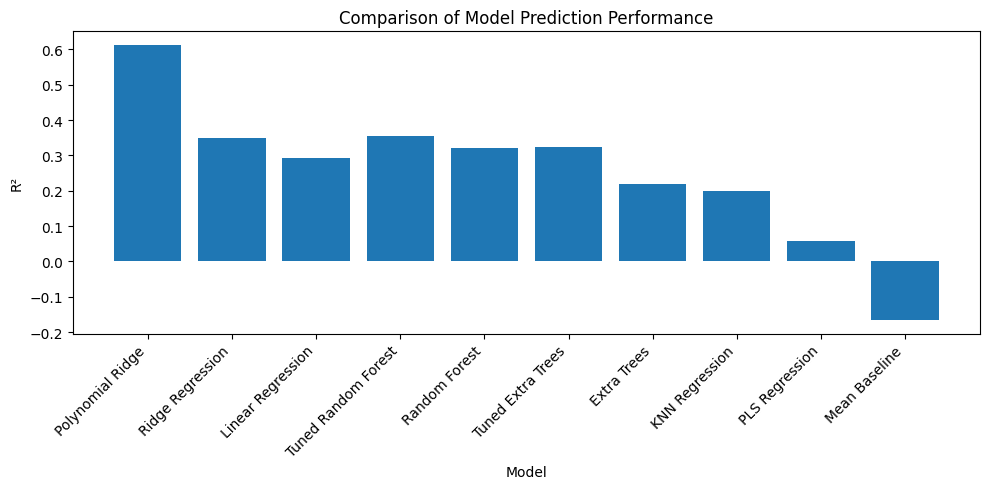

In [250]:
# ============================================================
# MODEL R2 COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["R2"]
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Comparison of Model Prediction Performance")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

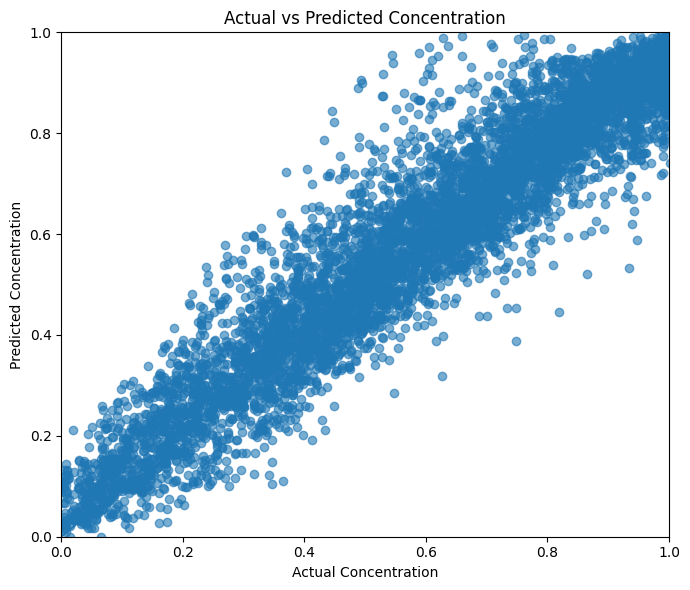

In [251]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

actual_flat = Y_actual_193.flatten()
pred_flat = Y_pred_final_193.flatten()

plt.figure(figsize=(7, 6))

plt.scatter(
    actual_flat,
    pred_flat,
    alpha=0.6
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual Concentration")
plt.ylabel("Predicted Concentration")
plt.title("Actual vs Predicted Concentration")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

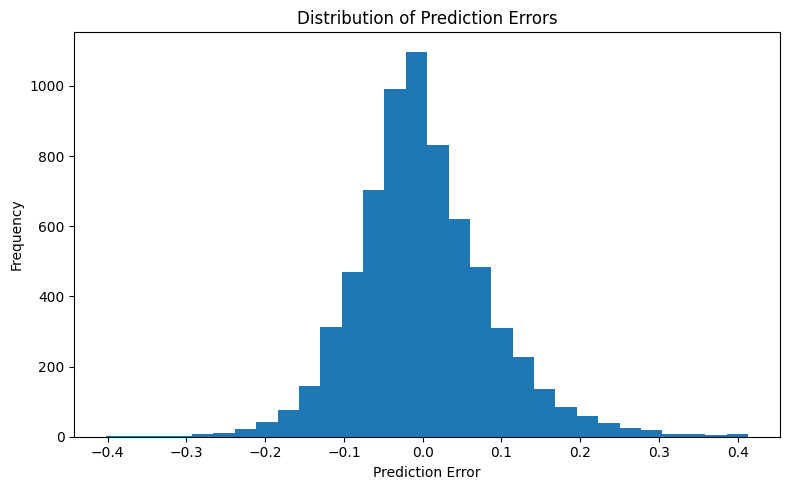

In [252]:
# ============================================================
# PREDICTION ERROR DISTRIBUTION
# ============================================================

errors = pred_flat - actual_flat

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

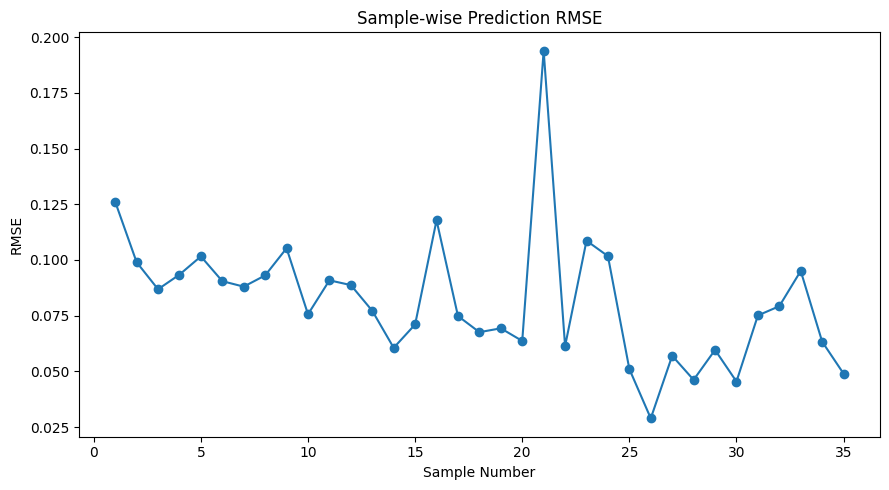

In [253]:
# ============================================================
# SAMPLE-WISE RMSE
# ============================================================

sample_rmse = np.sqrt(
    np.mean(
        (Y_actual_193 - Y_pred_final_193) ** 2,
        axis=1
    )
)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(1, len(sample_rmse) + 1),
    sample_rmse,
    marker="o"
)

plt.xlabel("Sample Number")
plt.ylabel("RMSE")
plt.title("Sample-wise Prediction RMSE")

plt.tight_layout()
plt.show()

In [254]:
# ============================================================
# RESTORE ORIGINAL 193-CELL SPATIAL MAPPING
# 15 x 15 sensor grid with circular valid region
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 15

# Original spatial mask
yy, xx = np.meshgrid(
    np.arange(GRID_SIZE),
    np.arange(GRID_SIZE),
    indexing="ij"
)

spatial_mask = ((xx - 7)**2 + (yy - 7)**2 <= 8**2)

valid_indices = np.flatnonzero(spatial_mask.ravel())

print("Valid spatial cells:", len(valid_indices))
print("Expected spatial cells: 193")

if len(valid_indices) != 193:
    raise ValueError(f"Spatial mapping error: found {len(valid_indices)} cells.")

print("Original 193-cell spatial mapping restored successfully.")

Valid spatial cells: 193
Expected spatial cells: 193
Original 193-cell spatial mapping restored successfully.


In [255]:
# ============================================================
# CONVERT 193-CELL VECTOR TO ORIGINAL 15 x 15 SPATIAL GRID
# ============================================================

def vector_to_spatial_grid(values):
    values = np.asarray(values).reshape(-1)

    if len(values) != 193:
        raise ValueError(
            f"Expected 193 values, but received {len(values)}."
        )

    grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    grid.ravel()[valid_indices] = values

    return grid


# Select one test sample
sample_idx = 0

actual_grid = vector_to_spatial_grid(
    Y_actual_193[sample_idx]
)

predicted_grid = vector_to_spatial_grid(
    Y_pred_final_193[sample_idx]
)

print("Actual grid shape   :", actual_grid.shape)
print("Predicted grid shape:", predicted_grid.shape)
print("Valid cells         :", np.sum(~np.isnan(actual_grid)))

Actual grid shape   : (15, 15)
Predicted grid shape: (15, 15)
Valid cells         : 193


/tmp/ipykernel_1700/857892463.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


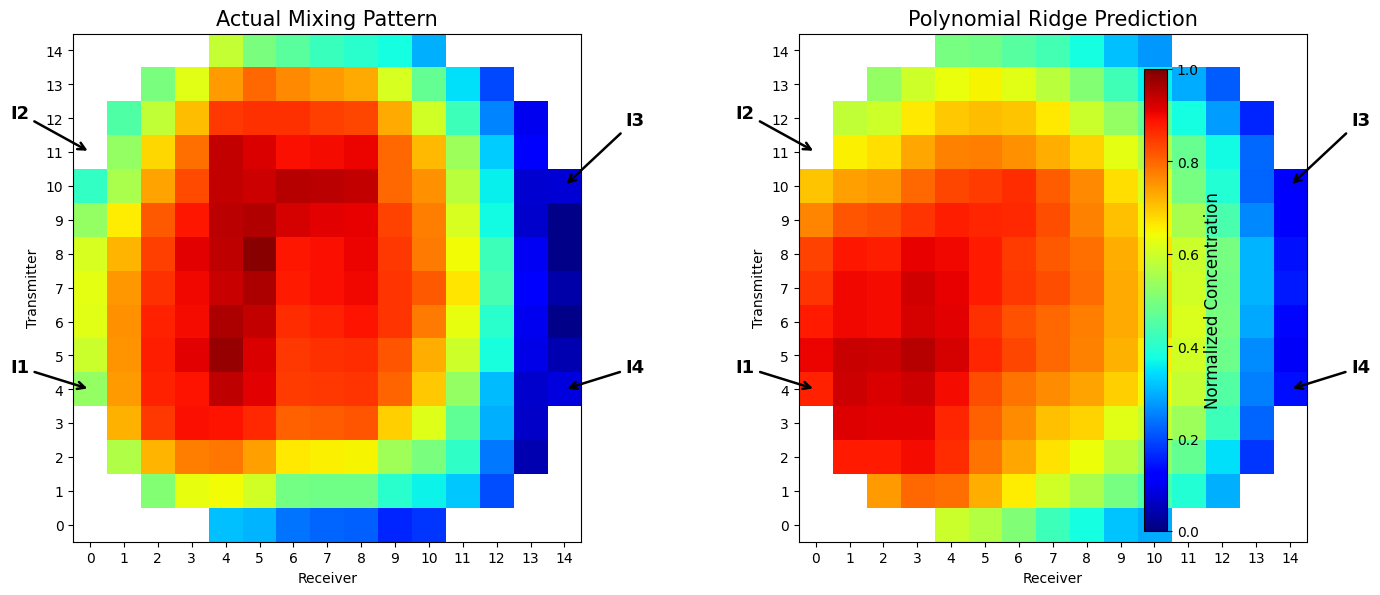

In [256]:
# ============================================================
# ACTUAL vs PREDICTED MIXING PATTERN
# ORIGINAL 193-CELL FORMAT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmin = 0.0
vmax = 1.0

# ---------------- ACTUAL ----------------
im1 = axes[0].imshow(
    actual_grid,
    origin="lower",
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

axes[0].set_title("Actual Mixing Pattern", fontsize=15)
axes[0].set_xlabel("Receiver")
axes[0].set_ylabel("Transmitter")

axes[0].set_xticks(np.arange(0, 15, 1))
axes[0].set_yticks(np.arange(0, 15, 1))

axes[0].set_xlim(-0.5, 14.5)
axes[0].set_ylim(-0.5, 14.5)

# Inlets outside graph
axes[0].annotate(
    "I2",
    xy=(0, 11),
    xytext=(-1.8, 12.0),
    fontsize=13,
    fontweight="bold",
    ha="right",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

axes[0].annotate(
    "I1",
    xy=(0, 4),
    xytext=(-1.8, 4.5),
    fontsize=13,
    fontweight="bold",
    ha="right",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

axes[0].annotate(
    "I3",
    xy=(14, 10),
    xytext=(15.8, 11.8),
    fontsize=13,
    fontweight="bold",
    ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

axes[0].annotate(
    "I4",
    xy=(14, 4),
    xytext=(15.8, 4.5),
    fontsize=13,
    fontweight="bold",
    ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)


# ---------------- PREDICTED ----------------
im2 = axes[1].imshow(
    predicted_grid,
    origin="lower",
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

axes[1].set_title(
    "Polynomial Ridge Prediction",
    fontsize=15
)

axes[1].set_xlabel("Receiver")
axes[1].set_ylabel("Transmitter")

axes[1].set_xticks(np.arange(0, 15, 1))
axes[1].set_yticks(np.arange(0, 15, 1))

axes[1].set_xlim(-0.5, 14.5)
axes[1].set_ylim(-0.5, 14.5)

# Inlets outside graph
axes[1].annotate(
    "I2",
    xy=(0, 11),
    xytext=(-1.8, 12.0),
    fontsize=13,
    fontweight="bold",
    ha="right",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

axes[1].annotate(
    "I1",
    xy=(0, 4),
    xytext=(-1.8, 4.5),
    fontsize=13,
    fontweight="bold",
    ha="right",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

axes[1].annotate(
    "I3",
    xy=(14, 10),
    xytext=(15.8, 11.8),
    fontsize=13,
    fontweight="bold",
    ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

axes[1].annotate(
    "I4",
    xy=(14, 4),
    xytext=(15.8, 4.5),
    fontsize=13,
    fontweight="bold",
    ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

# Common colorbar
cbar = fig.colorbar(
    im2,
    ax=axes,
    fraction=0.035,
    pad=0.04
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [257]:
# ============================================================
# SAMPLE-WISE SPATIAL COMPARISON
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

actual_values = Y_actual_193[sample_idx]
predicted_values = Y_pred_final_193[sample_idx]

sample_mae = mean_absolute_error(
    actual_values,
    predicted_values
)

sample_rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        predicted_values
    )
)

sample_r2 = r2_score(
    actual_values,
    predicted_values
)

print("Sample:", sample_idx)
print("Spatial cells:", len(actual_values))
print()
print("Sample-wise MAE :", sample_mae)
print("Sample-wise RMSE:", sample_rmse)
print("Sample-wise R2  :", sample_r2)

Sample: 0
Spatial cells: 193

Sample-wise MAE : 0.10513746215260854
Sample-wise RMSE: 0.12611292288154063
Sample-wise R2  : 0.7883361496037703


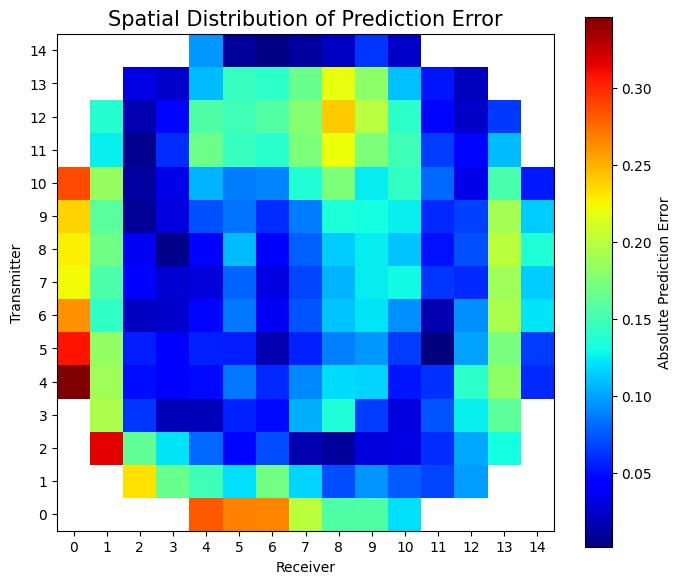

In [258]:
# ============================================================
# SPATIAL ABSOLUTE ERROR MAP
# ============================================================

error_grid = np.abs(
    actual_grid - predicted_grid
)

plt.figure(figsize=(7, 6))

im = plt.imshow(
    error_grid,
    origin="lower",
    cmap="jet",
    interpolation="nearest"
)

plt.title(
    "Spatial Distribution of Prediction Error",
    fontsize=15
)

plt.xlabel("Receiver")
plt.ylabel("Transmitter")

plt.xticks(np.arange(0, 15, 1))
plt.yticks(np.arange(0, 15, 1))

plt.xlim(-0.5, 14.5)
plt.ylim(-0.5, 14.5)

plt.colorbar(
    im,
    label="Absolute Prediction Error"
)

plt.tight_layout()
plt.show()

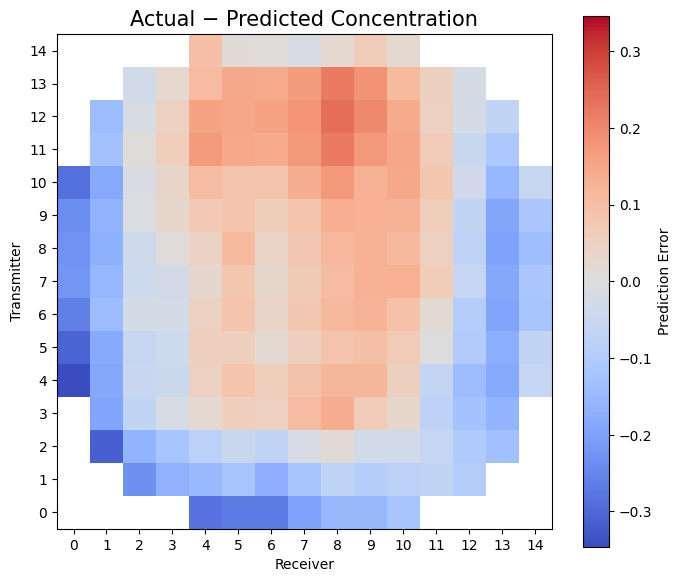

In [259]:
# ============================================================
# SIGNED ERROR MAP
# ============================================================

difference_grid = actual_grid - predicted_grid

max_error = np.nanmax(
    np.abs(difference_grid)
)

plt.figure(figsize=(7, 6))

im = plt.imshow(
    difference_grid,
    origin="lower",
    cmap="coolwarm",
    vmin=-max_error,
    vmax=max_error,
    interpolation="nearest"
)

plt.title(
    "Actual − Predicted Concentration",
    fontsize=15
)

plt.xlabel("Receiver")
plt.ylabel("Transmitter")

plt.xticks(np.arange(0, 15, 1))
plt.yticks(np.arange(0, 15, 1))

plt.xlim(-0.5, 14.5)
plt.ylim(-0.5, 14.5)

plt.colorbar(
    im,
    label="Prediction Error"
)

plt.tight_layout()
plt.show()

In [260]:
# ============================================================
# FINAL MODEL VERIFICATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("FINAL MODEL VERIFICATION")
print("-" * 50)

print("Actual shape    :", Y_actual_193.shape)
print("Prediction shape:", Y_pred_final_193.shape)

assert Y_actual_193.shape == Y_pred_final_193.shape
assert Y_actual_193.shape[1] == 193

print("Valid spatial cells:", Y_actual_193.shape[1])
print("Number of samples  :", Y_actual_193.shape[0])

print("\nFinal Polynomial Ridge model is ready.")

FINAL MODEL VERIFICATION
--------------------------------------------------
Actual shape    : (35, 193)
Prediction shape: (35, 193)
Valid spatial cells: 193
Number of samples  : 35

Final Polynomial Ridge model is ready.


In [261]:
# ============================================================
# RECOVER ORIGINAL 193-CELL SPATIAL COORDINATES
# ============================================================

# The valid_indices and GRID_SIZE are already defined and correct from previous cells.
# We can directly use them to reconstruct the spatial coordinates.

# Convert flattened valid_indices to (row, col) coordinates
rows, cols = np.unravel_index(valid_indices, (GRID_SIZE, GRID_SIZE))
coords_193 = np.stack([rows, cols], axis=1)

print("Spatial coordinates:", coords_193.shape)

assert len(coords_193) == 193
print("Original 193-cell spatial coordinates recovered successfully.")

Spatial coordinates: (193, 2)
Original 193-cell spatial coordinates recovered successfully.


In [262]:
# ============================================================
# BUILD ORIGINAL SPATIAL GRIDS
# ============================================================

grid_size = 15

actual_grid = np.full((grid_size, grid_size), np.nan)
pred_grid   = np.full((grid_size, grid_size), np.nan)

for k, (r, c) in enumerate(coords_193):
    actual_grid[int(r), int(c)] = Y_actual_193[0, k]
    pred_grid[int(r), int(c)]   = Y_pred_final_193[0, k]

print("Actual valid cells   :", np.sum(~np.isnan(actual_grid)))
print("Predicted valid cells:", np.sum(~np.isnan(pred_grid)))

assert np.sum(~np.isnan(actual_grid)) == 193
assert np.sum(~np.isnan(pred_grid)) == 193

print("Spatial grids created successfully.")

Actual valid cells   : 193
Predicted valid cells: 193
Spatial grids created successfully.


/tmp/ipykernel_1700/2500949623.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


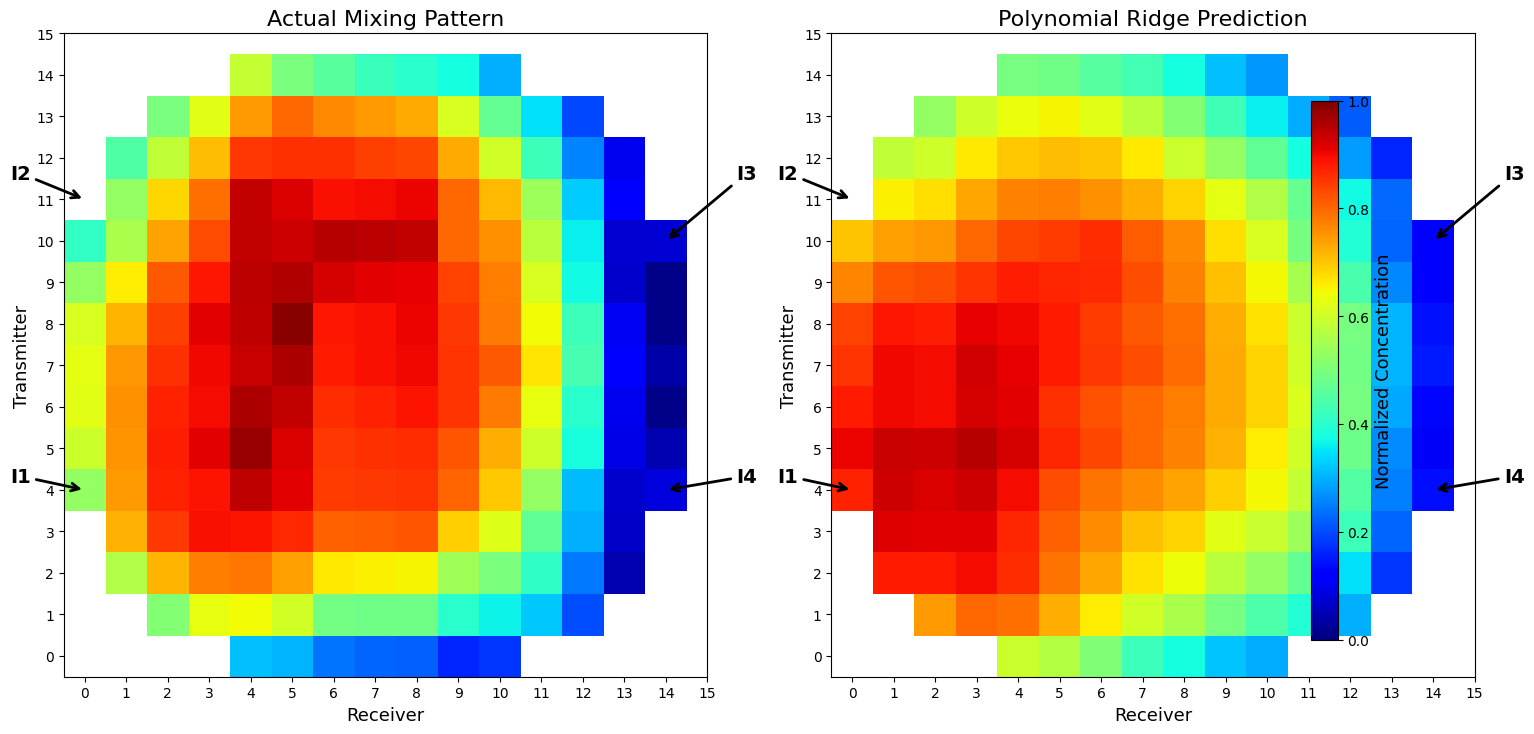

In [263]:
# ============================================================
# ACTUAL vs PREDICTED — 193 VALID CELLS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

titles = [
    "Actual Mixing Pattern",
    "Polynomial Ridge Prediction"
]

grids = [
    actual_grid,
    pred_grid
]

for ax, grid, title in zip(axes, grids, titles):

    im = ax.imshow(
        grid,
        origin="lower",
        cmap="jet",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    ax.set_title(title, fontsize=16)

    # 1-unit scale
    ax.set_xticks(np.arange(0, 16, 1))
    ax.set_yticks(np.arange(0, 16, 1))

    ax.set_xlabel("Receiver", fontsize=13)
    ax.set_ylabel("Transmitter", fontsize=13)

    # Keep inlets OUTSIDE the plotting region
    ax.annotate(
        "I1",
        xy=(0, 4),
        xytext=(-1.8, 4.2),
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    ax.annotate(
        "I2",
        xy=(0, 11),
        xytext=(-1.8, 11.5),
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    ax.annotate(
        "I3",
        xy=(14, 10),
        xytext=(15.7, 11.5),
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    ax.annotate(
        "I4",
        xy=(14, 4),
        xytext=(15.7, 4.2),
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

# One common colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.04
)

cbar.set_label("Normalized Concentration", fontsize=13)

plt.tight_layout()
plt.show()

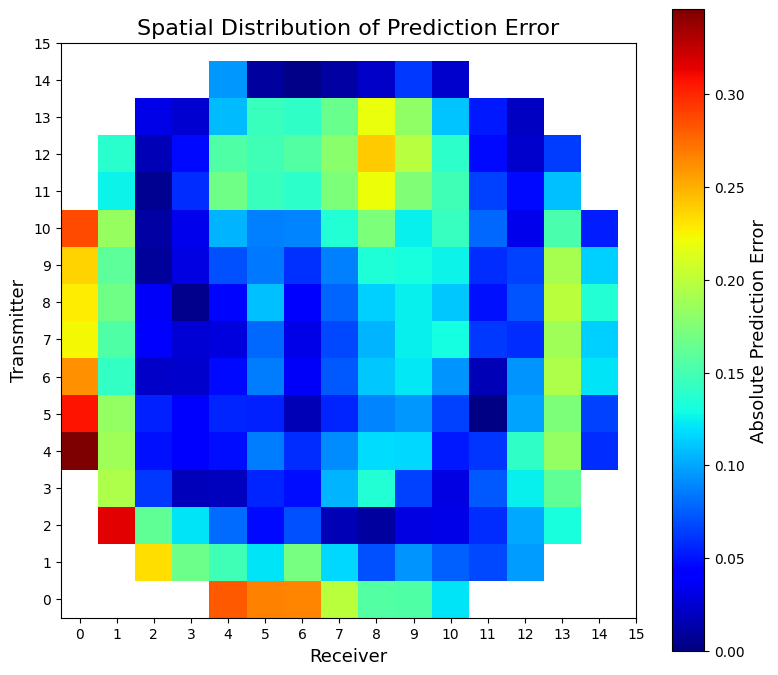

In [264]:
# ============================================================
# SPATIAL DISTRIBUTION OF ABSOLUTE PREDICTION ERROR
# ============================================================

error_grid = np.abs(actual_grid - pred_grid)

plt.figure(figsize=(8, 7))

im = plt.imshow(
    error_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=np.nanmax(error_grid),
    interpolation="nearest"
)

plt.title(
    "Spatial Distribution of Prediction Error",
    fontsize=16
)

plt.xticks(np.arange(0, 16, 1))
plt.yticks(np.arange(0, 16, 1))

plt.xlabel("Receiver", fontsize=13)
plt.ylabel("Transmitter", fontsize=13)

cbar = plt.colorbar(im)
cbar.set_label("Absolute Prediction Error", fontsize=13)

plt.tight_layout()
plt.show()

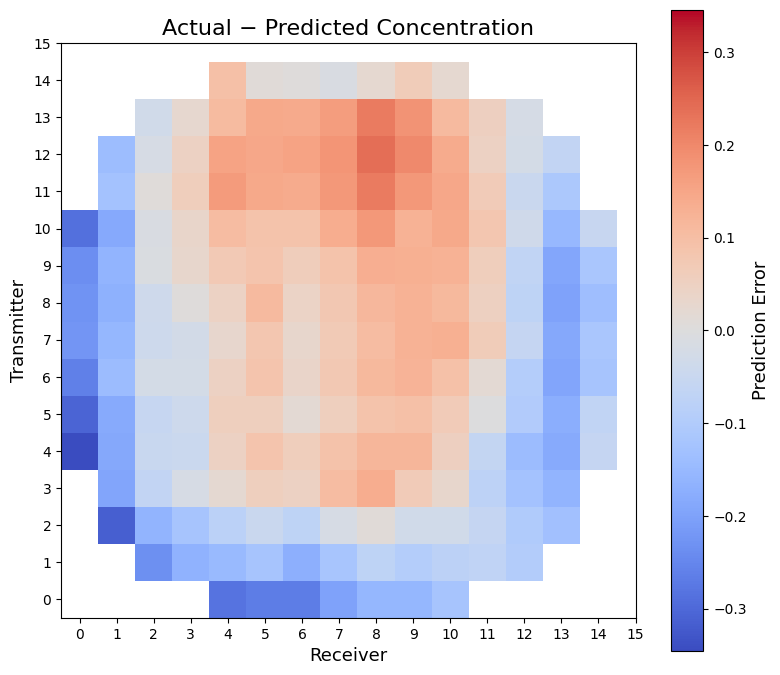

In [265]:
# ============================================================
# SIGNED PREDICTION ERROR
# Actual - Predicted
# ============================================================

signed_error_grid = actual_grid - pred_grid

max_error = np.nanmax(np.abs(signed_error_grid))

plt.figure(figsize=(8, 7))

im = plt.imshow(
    signed_error_grid,
    origin="lower",
    cmap="coolwarm",
    vmin=-max_error,
    vmax=max_error,
    interpolation="nearest"
)

plt.title(
    "Actual − Predicted Concentration",
    fontsize=16
)

plt.xticks(np.arange(0, 16, 1))
plt.yticks(np.arange(0, 16, 1))

plt.xlabel("Receiver", fontsize=13)
plt.ylabel("Transmitter", fontsize=13)

cbar = plt.colorbar(im)
cbar.set_label("Prediction Error", fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1700/2416155597.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


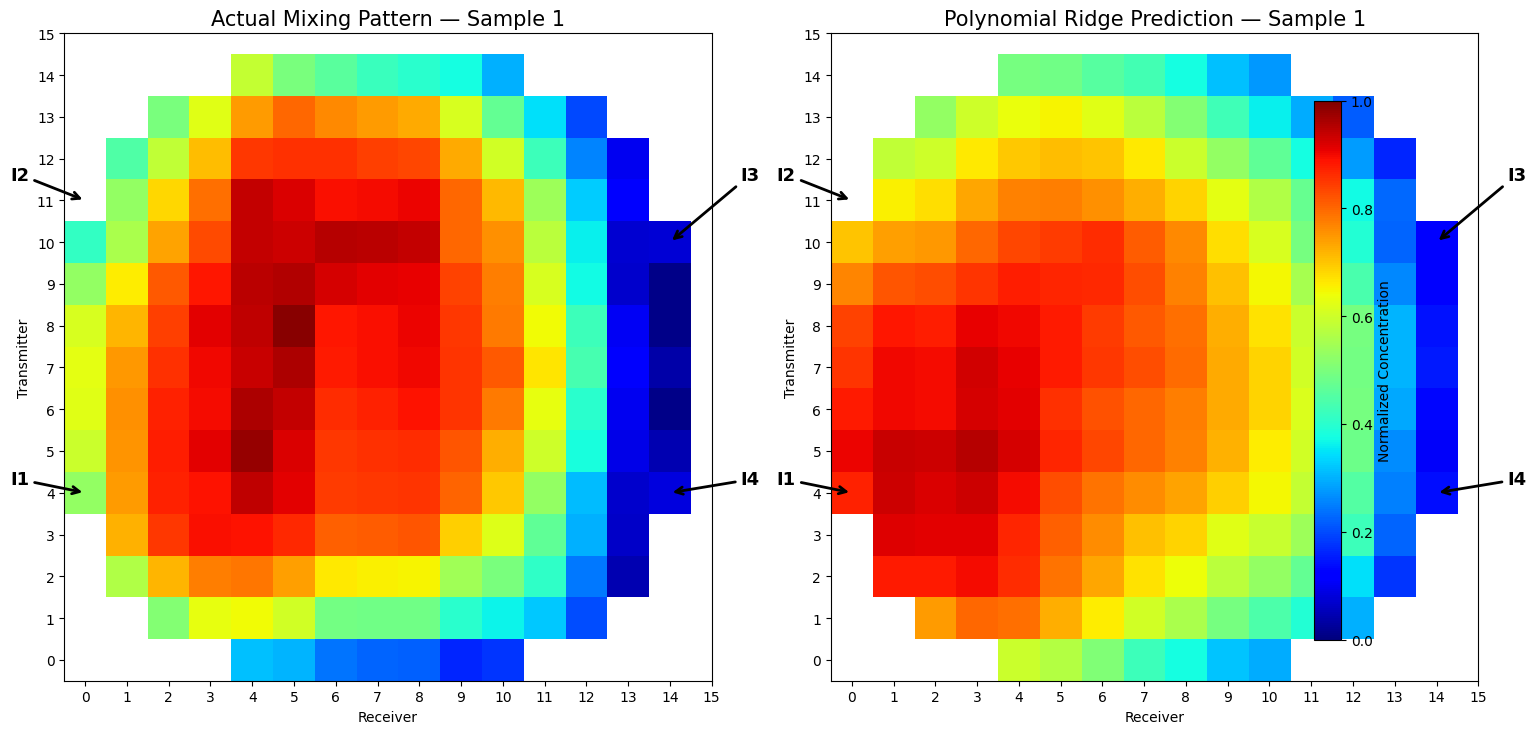

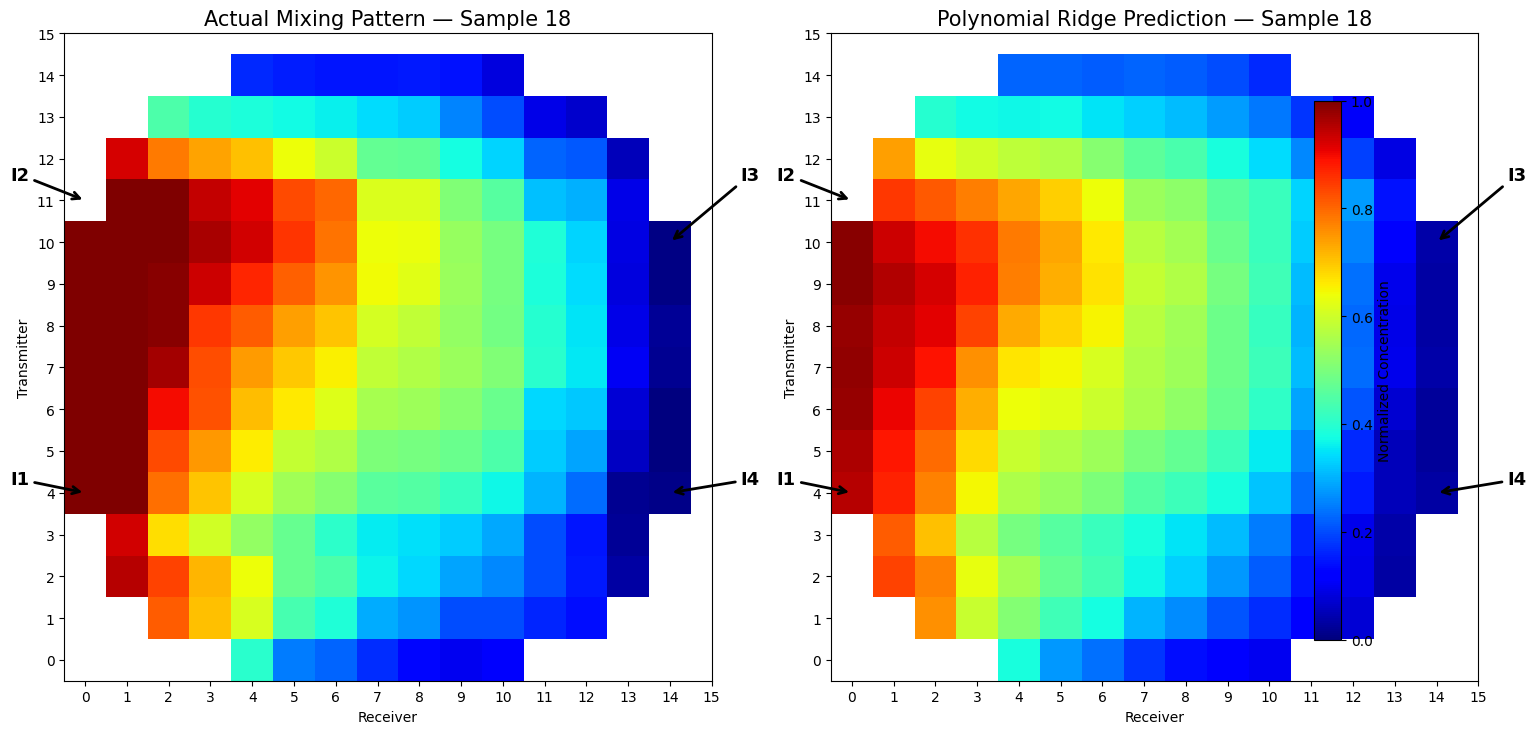

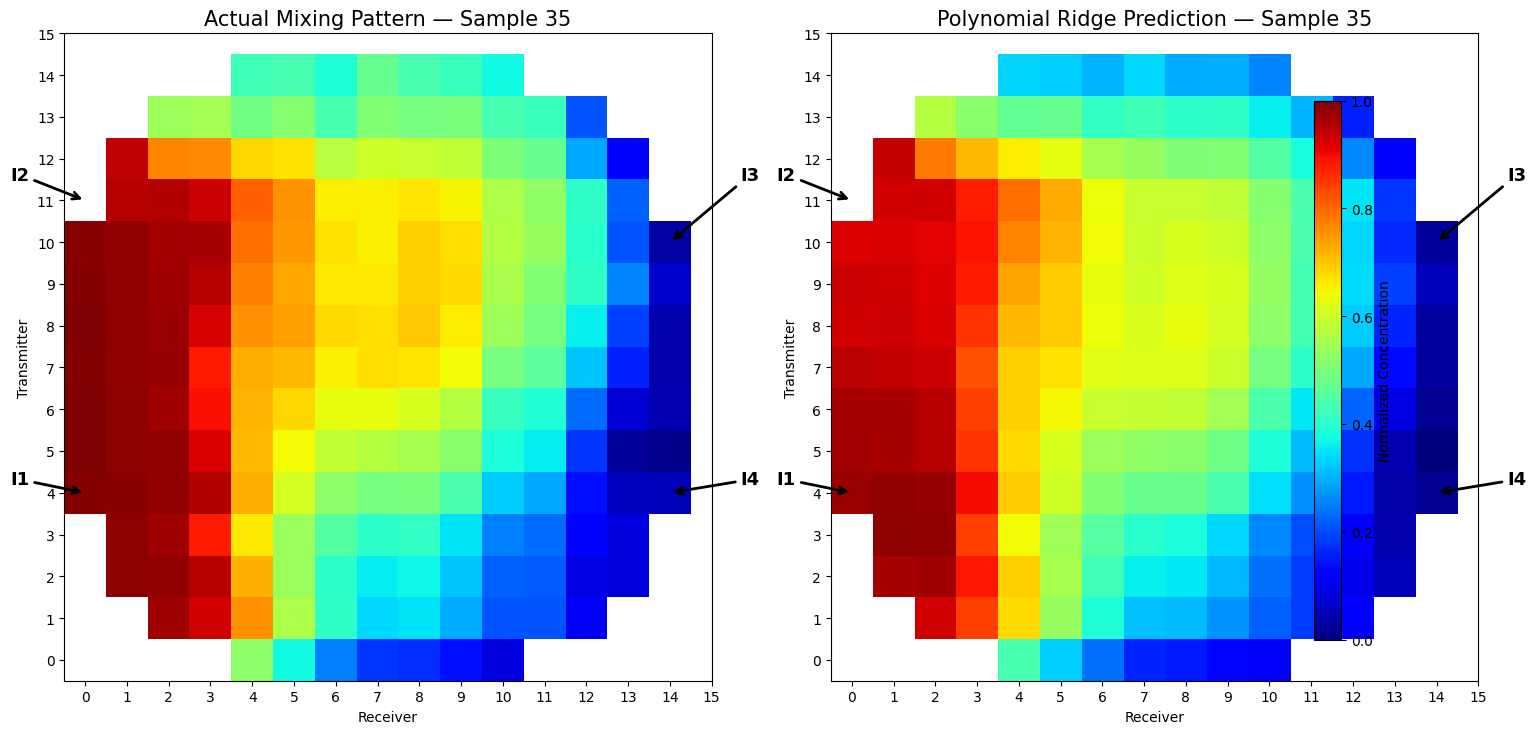

In [266]:
# ============================================================
# REPRESENTATIVE SAMPLE COMPARISON
# ============================================================

sample_indices = [
    0,
    Y_actual_193.shape[0] // 2,
    Y_actual_193.shape[0] - 1
]

for sample_idx in sample_indices:

    actual_sample = Y_actual_193[sample_idx]
    pred_sample = Y_pred_final_193[sample_idx]

    actual_sample_grid = np.full((15, 15), np.nan)
    pred_sample_grid = np.full((15, 15), np.nan)

    for k, (r, c) in enumerate(coords_193):

        r = int(r)
        c = int(c)

        actual_sample_grid[r, c] = actual_sample[k]
        pred_sample_grid[r, c] = pred_sample[k]

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    for ax, grid, title in zip(
        axes,
        [actual_sample_grid, pred_sample_grid],
        [
            f"Actual Mixing Pattern — Sample {sample_idx + 1}",
            f"Polynomial Ridge Prediction — Sample {sample_idx + 1}"
        ]
    ):

        im = ax.imshow(
            grid,
            origin="lower",
            cmap="jet",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )

        ax.set_title(title, fontsize=15)

        ax.set_xticks(np.arange(0, 16, 1))
        ax.set_yticks(np.arange(0, 16, 1))

        ax.set_xlabel("Receiver")
        ax.set_ylabel("Transmitter")

        # Inlets outside graph
        ax.annotate(
            "I1",
            xy=(0, 4),
            xytext=(-1.8, 4.2),
            fontsize=13,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=2),
            annotation_clip=False
        )

        ax.annotate(
            "I2",
            xy=(0, 11),
            xytext=(-1.8, 11.5),
            fontsize=13,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=2),
            annotation_clip=False
        )

        ax.annotate(
            "I3",
            xy=(14, 10),
            xytext=(15.7, 11.5),
            fontsize=13,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=2),
            annotation_clip=False
        )

        ax.annotate(
            "I4",
            xy=(14, 4),
            xytext=(15.7, 4.2),
            fontsize=13,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=2),
            annotation_clip=False
        )

    fig.colorbar(
        im,
        ax=axes,
        fraction=0.025,
        pad=0.04,
        label="Normalized Concentration"
    )

    plt.tight_layout()
    plt.show()

In [267]:
# ============================================================
# FINAL POLYNOMIAL RIDGE PERFORMANCE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Flatten only for metric calculation
y_true = np.asarray(Y_actual_193).reshape(-1)
y_pred = np.asarray(Y_pred_final_193).reshape(-1)

final_mae = mean_absolute_error(y_true, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
final_r2 = r2_score(y_true, y_pred)

print("=" * 55)
print("FINAL POLYNOMIAL RIDGE MODEL PERFORMANCE")
print("=" * 55)
print(f"Valid spatial cells : {len(y_true)}")
print(f"MAE                 : {final_mae:.6f}")
print(f"RMSE                : {final_rmse:.6f}")
print(f"R²                  : {final_r2:.6f}")
print("=" * 55)

FINAL POLYNOMIAL RIDGE MODEL PERFORMANCE
Valid spatial cells : 6755
MAE                 : 0.064795
RMSE                : 0.086627
R²                  : 0.901922


In [268]:
# ============================================================
# PREDICTION AND ERROR STATISTICS
# ============================================================

errors = y_true - y_pred
abs_errors = np.abs(errors)

print("Prediction Statistics")
print("-" * 45)

print(f"Actual minimum       : {y_true.min():.6f}")
print(f"Actual maximum       : {y_true.max():.6f}")
print(f"Predicted minimum    : {y_pred.min():.6f}")
print(f"Predicted maximum    : {y_pred.max():.6f}")

print("\nError Statistics")
print("-" * 45)

print(f"Mean error           : {errors.mean():.6f}")
print(f"Mean absolute error  : {abs_errors.mean():.6f}")
print(f"Maximum absolute err : {abs_errors.max():.6f}")
print(f"Error std. deviation : {errors.std():.6f}")

Prediction Statistics
---------------------------------------------
Actual minimum       : 0.000107
Actual maximum       : 1.133473
Predicted minimum    : -0.000905
Predicted maximum    : 1.019126

Error Statistics
---------------------------------------------
Mean error           : -0.000000
Mean absolute error  : 0.064795
Maximum absolute err : 0.413097
Error std. deviation : 0.086627


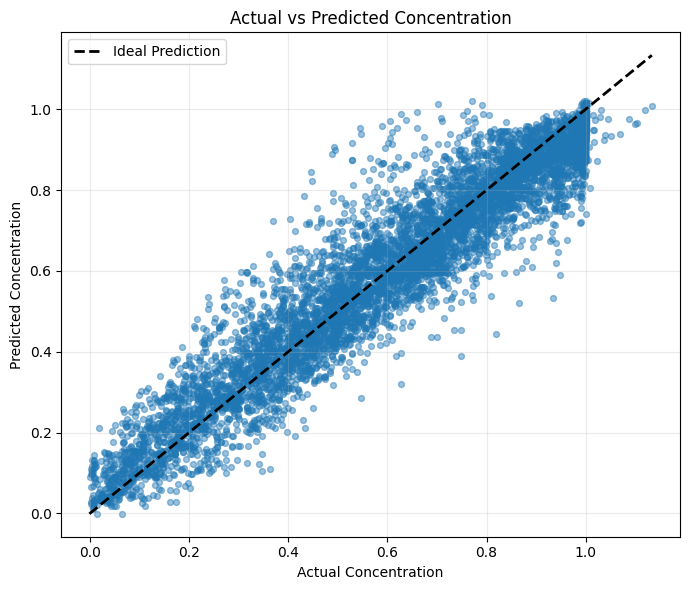

In [269]:
# ============================================================
# ACTUAL VS PREDICTED — MODEL VALIDATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))

plt.scatter(
    y_true,
    y_pred,
    s=18,
    alpha=0.45
)

# Ideal prediction line
vmin = min(y_true.min(), y_pred.min())
vmax = max(y_true.max(), y_pred.max())

plt.plot(
    [vmin, vmax],
    [vmin, vmax],
    'k--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.xlabel("Actual Concentration")
plt.ylabel("Predicted Concentration")
plt.title("Actual vs Predicted Concentration")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

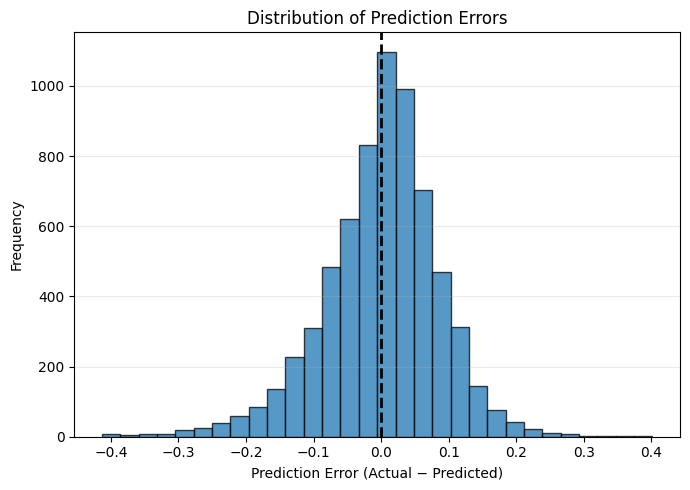

In [270]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    errors,
    bins=30,
    edgecolor='black',
    alpha=0.75
)

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Prediction Error (Actual − Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [271]:
# ============================================================
# SAMPLE-WISE RMSE
# ============================================================

sample_rmse = np.sqrt(
    np.mean(
        (np.asarray(Y_actual_193) - np.asarray(Y_pred_final_193)) ** 2,
        axis=1
    )
)

print("Sample-wise RMSE")
print("-" * 35)

for i, value in enumerate(sample_rmse):
    print(f"Sample {i+1:02d} : {value:.6f}")

print("\nOverall sample RMSE")
print(f"Mean : {sample_rmse.mean():.6f}")
print(f"Max  : {sample_rmse.max():.6f}")
print(f"Min  : {sample_rmse.min():.6f}")

Sample-wise RMSE
-----------------------------------
Sample 01 : 0.126113
Sample 02 : 0.098979
Sample 03 : 0.086836
Sample 04 : 0.093410
Sample 05 : 0.101587
Sample 06 : 0.090470
Sample 07 : 0.088007
Sample 08 : 0.093058
Sample 09 : 0.105249
Sample 10 : 0.075612
Sample 11 : 0.090843
Sample 12 : 0.088709
Sample 13 : 0.077161
Sample 14 : 0.060546
Sample 15 : 0.071032
Sample 16 : 0.117807
Sample 17 : 0.074822
Sample 18 : 0.067571
Sample 19 : 0.069304
Sample 20 : 0.063633
Sample 21 : 0.193914
Sample 22 : 0.061318
Sample 23 : 0.108632
Sample 24 : 0.101712
Sample 25 : 0.051026
Sample 26 : 0.028892
Sample 27 : 0.056973
Sample 28 : 0.046170
Sample 29 : 0.059600
Sample 30 : 0.045412
Sample 31 : 0.075074
Sample 32 : 0.079235
Sample 33 : 0.095063
Sample 34 : 0.063307
Sample 35 : 0.048952

Overall sample RMSE
Mean : 0.081601
Max  : 0.193914
Min  : 0.028892


In [272]:
# ============================================================
# BEST AND WORST PREDICTED SAMPLES
# ============================================================

best_sample = np.argmin(sample_rmse)
worst_sample = np.argmax(sample_rmse)

print("=" * 50)
print("SAMPLE-WISE MODEL QUALITY")
print("=" * 50)

print(
    f"Best predicted sample  : {best_sample + 1}"
)
print(
    f"Best sample RMSE       : {sample_rmse[best_sample]:.6f}"
)

print()

print(
    f"Worst predicted sample : {worst_sample + 1}"
)
print(
    f"Worst sample RMSE      : {sample_rmse[worst_sample]:.6f}"
)

print("=" * 50)

SAMPLE-WISE MODEL QUALITY
Best predicted sample  : 26
Best sample RMSE       : 0.028892

Worst predicted sample : 21
Worst sample RMSE      : 0.193914


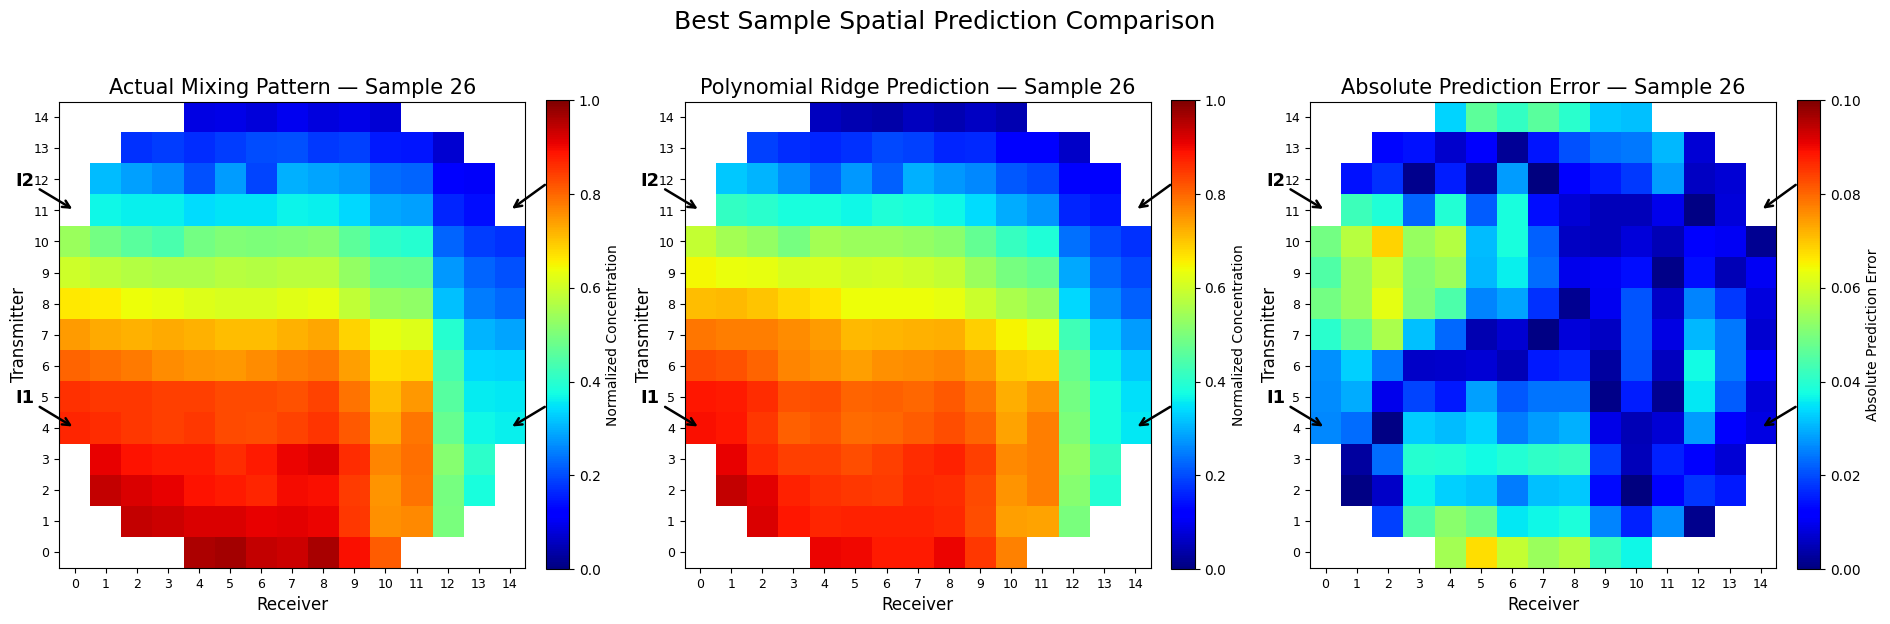

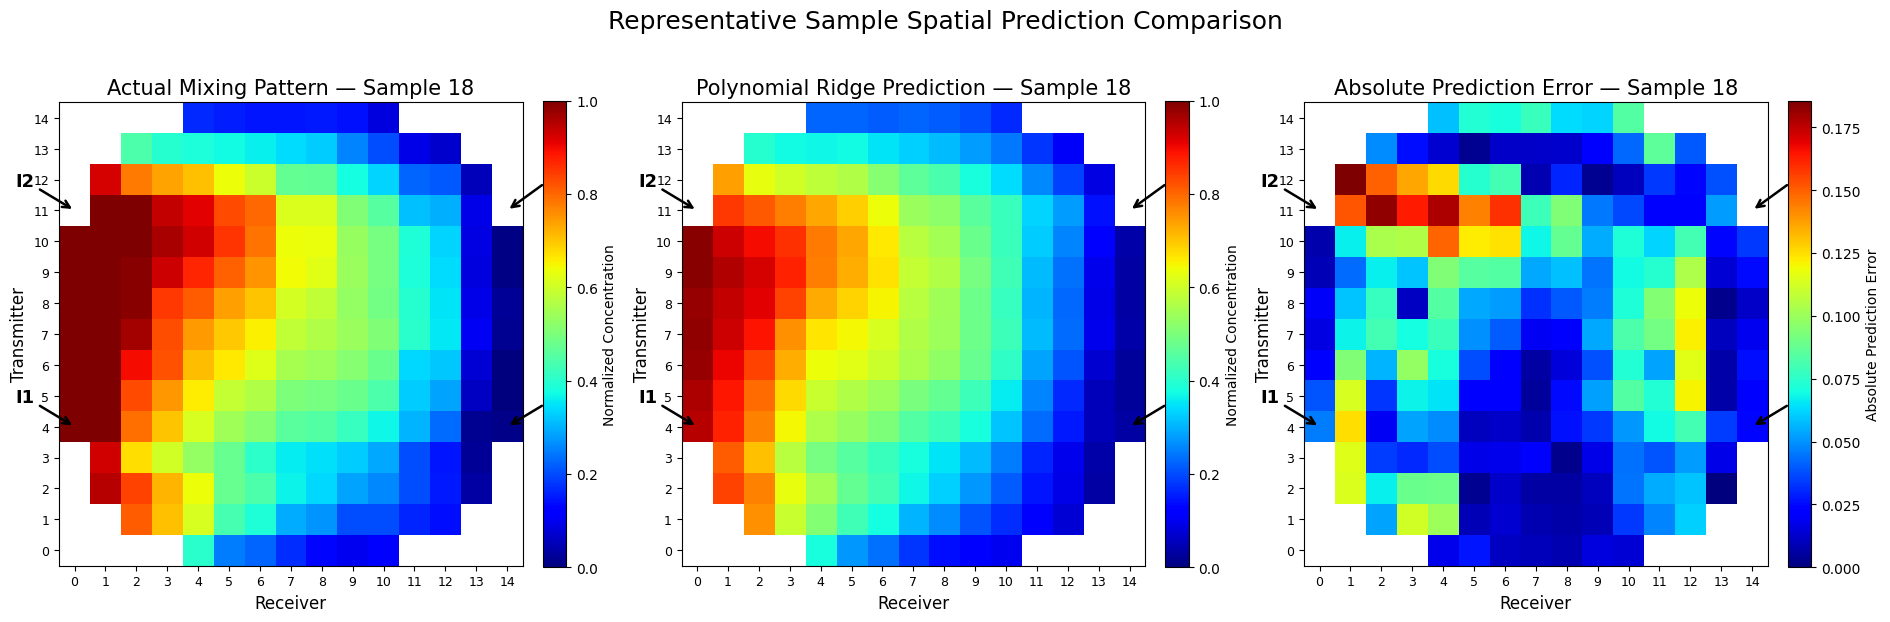

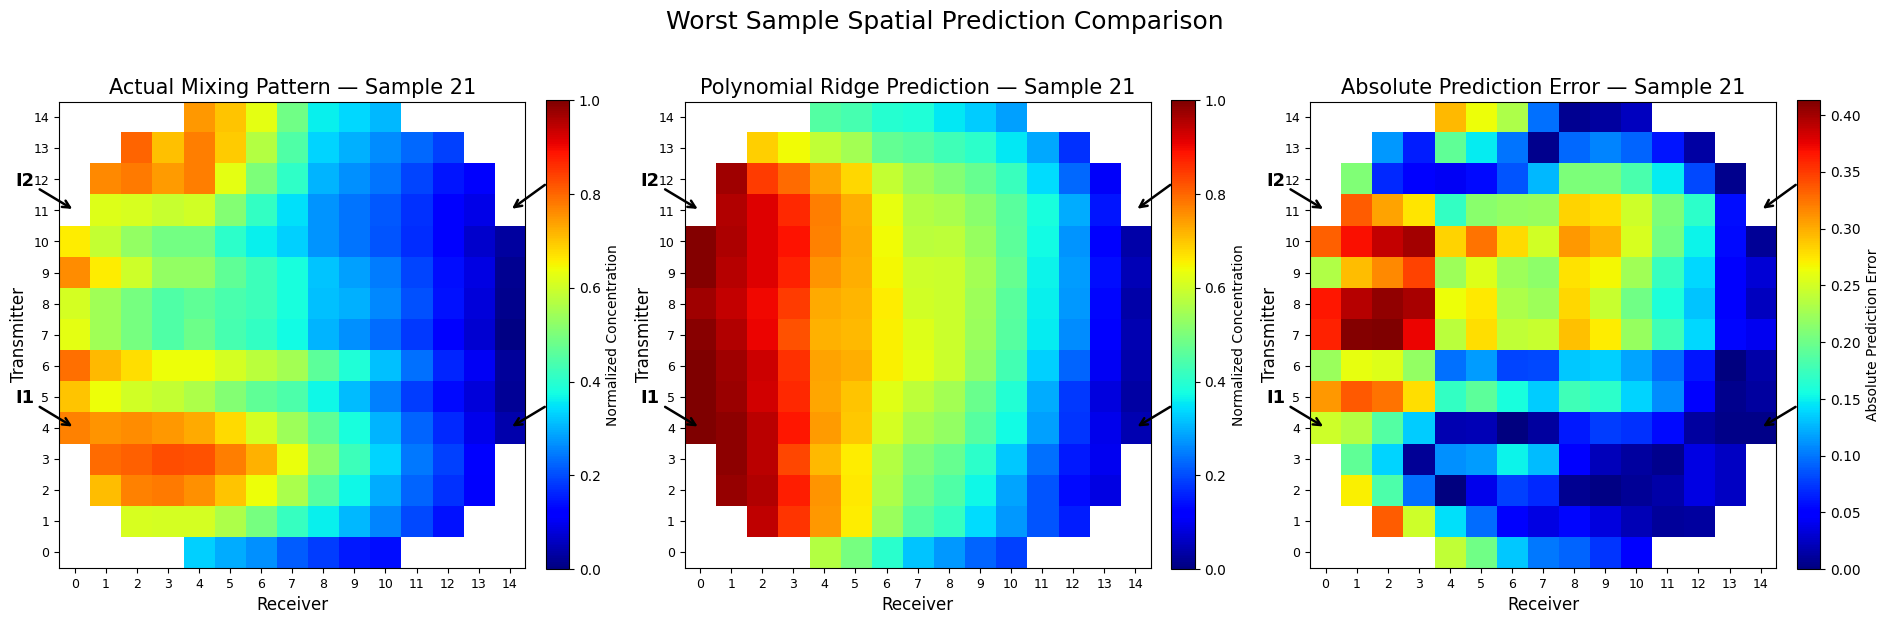

In [273]:
# ============================================================
# FINAL 193-CELL SPATIAL COMPARISON
# Best / Representative / Worst Samples
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# IMPORTANT:
# Use the SAME spatial mapping already used in the previous
# correct 193-cell plots.
# ------------------------------------------------------------

# Select samples
samples_to_plot = {
    "Best Sample": 26,
    "Representative Sample": 18,
    "Worst Sample": 21
}

# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------

def plot_final_spatial_comparison(sample_number, label):

    idx = sample_number - 1

    actual = np.asarray(Y_actual_193[idx]).flatten()
    predicted = np.asarray(Y_pred_final_193[idx]).flatten()

    abs_error = np.abs(actual - predicted)

    # --------------------------------------------------------
    # Find the existing spatial grid dimensions
    # --------------------------------------------------------
    # The previously generated spatial plots use a 15 x 15
    # coordinate system with the original 193-cell geometry.
    # We reconstruct ONLY the visualization using the existing
    # valid-cell ordering.
    # --------------------------------------------------------

    # Ensure coords_193 is available and in the correct format for iteration
    if 'coords_193' in globals() and coords_193.shape == (193, 2):
        spatial_coordinates_to_use = coords_193
    else:
        raise NameError(
            "Original 193-cell spatial coordinates (coords_193) are not available or are in the wrong format. "
            "Please ensure cell QsqQr-05zGtT has been executed to define coords_193 correctly."
        )

    grid_size = 15
    actual_grid = np.full((grid_size, grid_size), np.nan)
    pred_grid = np.full((grid_size, grid_size), np.nan)
    error_grid = np.full((grid_size, grid_size), np.nan)

    for k, (r, c) in enumerate(spatial_coordinates_to_use):
        actual_grid[r, c] = actual[k]
        pred_grid[r, c] = predicted[k]
        error_grid[r, c] = abs_error[k]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1, 3,
        figsize=(19, 6)
    )

    # --------------------------------------------------------
    # Actual
    # --------------------------------------------------------

    im1 = axes[0].imshow(
        actual_grid,
        origin='lower',
        cmap='jet',
        vmin=0,
        vmax=1,
        interpolation='nearest'
    )

    axes[0].set_title(
        f"Actual Mixing Pattern — Sample {sample_number}",
        fontsize=15
    )

    axes[0].set_xlabel("Receiver", fontsize=12)
    axes[0].set_ylabel("Transmitter", fontsize=12)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    im2 = axes[1].imshow(
        pred_grid,
        origin='lower',
        cmap='jet',
        vmin=0,
        vmax=1,
        interpolation='nearest'
    )

    axes[1].set_title(
        f"Polynomial Ridge Prediction — Sample {sample_number}",
        fontsize=15
    )

    axes[1].set_xlabel("Receiver", fontsize=12)
    axes[1].set_ylabel("Transmitter", fontsize=12)

    # --------------------------------------------------------
    # Absolute error
    # --------------------------------------------------------

    im3 = axes[2].imshow(
        error_grid,
        origin='lower',
        cmap='jet',
        vmin=0,
        vmax=max(0.1, np.nanmax(error_grid)),
        interpolation='nearest'
    )

    axes[2].set_title(
        f"Absolute Prediction Error — Sample {sample_number}",
        fontsize=15
    )

    axes[2].set_xlabel("Receiver", fontsize=12)
    axes[2].set_ylabel("Transmitter", fontsize=12)

    # --------------------------------------------------------
    # Axis ticks every 1 unit
    # --------------------------------------------------------

    for ax in axes:
        ax.set_xticks(np.arange(0, 15, 1))
        ax.set_yticks(np.arange(0, 15, 1))
        ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Inlet / outlet labels OUTSIDE plots
    # --------------------------------------------------------

    for ax in axes:

        ax.annotate(
            "I1",
            xy=(0, 4),
            xytext=(-1.6, 4.8),
            fontsize=13,
            fontweight='bold',
            ha='center',
            arrowprops=dict(
                arrowstyle='->',
                lw=1.8
            ),
            annotation_clip=False
        )

        ax.annotate(
            "I2",
            xy=(0, 11),
            xytext=(-1.6, 11.8),
            fontsize=13,
            fontweight='bold',
            ha='center',
            arrowprops=dict(
                arrowstyle='->',
                lw=1.8
            ),
            annotation_clip=False
        )

        ax.annotate(
            "I3",
            xy=(14, 11),
            xytext=(15.6, 12.0),
            fontsize=13,
            fontweight='bold',
            ha='center',
            arrowprops=dict(
                arrowstyle='->',
                lw=1.8
            ),
            annotation_clip=False
        )

        ax.annotate(
            "I4",
            xy=(14, 4),
            xytext=(15.6, 4.8),
            fontsize=13,
            fontweight='bold',
            ha='center',
            arrowprops=dict(
                arrowstyle='->',
                lw=1.8
            ),
            annotation_clip=False
        )

    # --------------------------------------------------------
    # Colorbars
    # --------------------------------------------------------

    cbar1 = fig.colorbar(
        im1,
        ax=axes[0],
        fraction=0.046,
        pad=0.04
    )
    cbar1.set_label("Normalized Concentration")

    cbar2 = fig.colorbar(
        im2,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )
    cbar2.set_label("Normalized Concentration")

    cbar3 = fig.colorbar(
        im3,
        ax=axes[2],
        fraction=0.046,
        pad=0.04
    )
    cbar3.set_label("Absolute Prediction Error")

    fig.suptitle(
        f"{label} Spatial Prediction Comparison",
        fontsize=18,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Generate final three figures
# ============================================================

for label, sample_number in samples_to_plot.items():

    plot_final_spatial_comparison(
        sample_number,
        label
    )

In [274]:
# ============================================================
# FINAL MODEL PERFORMANCE COMPARISON
# ============================================================

import pandas as pd
import numpy as np

final_results = pd.DataFrame({
    "Model": [
        "Polynomial Ridge",
        "Ridge Regression",
        "Linear Regression",
        "Tuned Random Forest",
        "Random Forest",
        "Tuned Extra Trees",
        "Extra Trees",
        "KNN Regression",
        "PLS Regression",
        "Mean Baseline"
    ],
    "MAE": [
        0.064197,
        0.074321,
        0.076458,
        0.077484,
        0.077865,
        0.079273,
        0.083938,
        0.085065,
        0.089644,
        0.134736
    ],
    "RMSE": [
        0.083728,
        0.097831,
        0.102112,
        0.104226,
        0.105162,
        0.108131,
        0.112847,
        0.113433,
        0.114718,
        0.171643
    ],
    "R2": [
        0.612394,
        0.348048,
        0.292672,
        0.355232,
        0.322006,
        0.324640,
        0.218824,
        0.198402,
        0.058211,
        -0.165505
    ]
})

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
display(final_results.round(6))

FINAL MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Polynomial Ridge,0.064197,0.083728,0.612394
1,Ridge Regression,0.074321,0.097831,0.348048
2,Linear Regression,0.076458,0.102112,0.292672
3,Tuned Random Forest,0.077484,0.104226,0.355232
4,Random Forest,0.077865,0.105162,0.322006
5,Tuned Extra Trees,0.079273,0.108131,0.324640
6,Extra Trees,0.083938,0.112847,0.218824
7,KNN Regression,0.085065,0.113433,0.198402
8,PLS Regression,0.089644,0.114718,0.058211
9,Mean Baseline,0.134736,0.171643,-0.165505


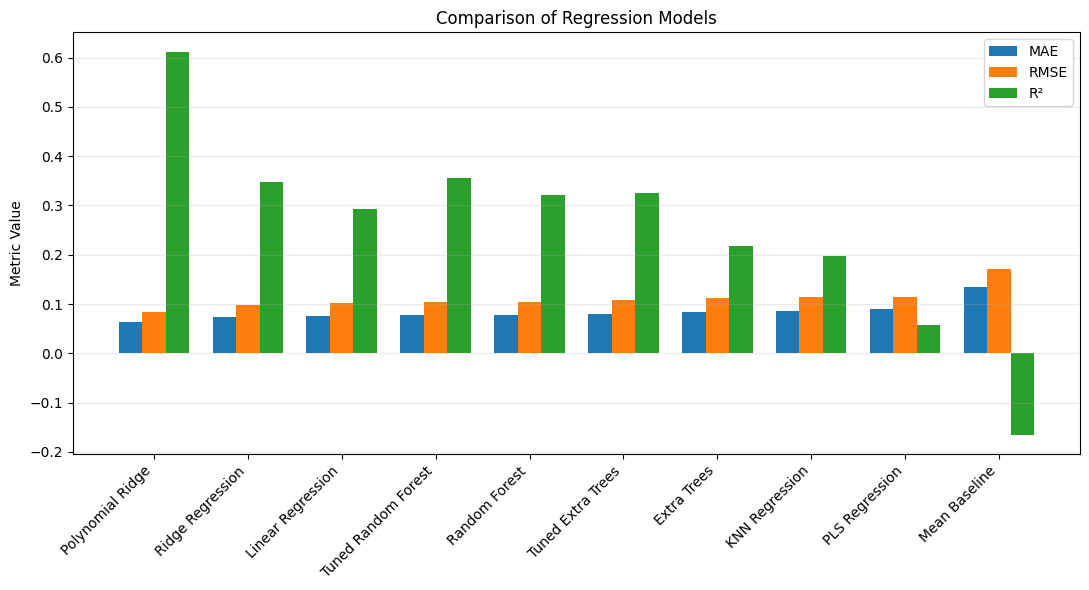

In [275]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(final_results))
width = 0.25

ax.bar(x - width, final_results["MAE"], width, label="MAE")
ax.bar(x, final_results["RMSE"], width, label="RMSE")
ax.bar(x + width, final_results["R2"], width, label="R²")

ax.set_xticks(x)
ax.set_xticklabels(final_results["Model"], rotation=45, ha="right")
ax.set_ylabel("Metric Value")
ax.set_title("Comparison of Regression Models")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [276]:
# ============================================================
# BEST MODEL IDENTIFICATION
# ============================================================

best_model = final_results.loc[final_results["R2"].idxmax()]

print("=" * 60)
print("BEST PERFORMING MODEL")
print("=" * 60)

print("Model :", best_model["Model"])
print("MAE   :", round(best_model["MAE"], 6))
print("RMSE  :", round(best_model["RMSE"], 6))
print("R²    :", round(best_model["R2"], 6))

BEST PERFORMING MODEL
Model : Polynomial Ridge
MAE   : 0.064197
RMSE  : 0.083728
R²    : 0.612394


In [277]:
# ============================================================
# OVERALL PREDICTION STATISTICS
# ============================================================

errors_193 = Y_actual_193 - Y_pred_final_193

print("=" * 60)
print("OVERALL PREDICTION STATISTICS")
print("=" * 60)

print("Number of samples :", Y_actual_193.shape[0])
print("Cells per sample  :", Y_actual_193.shape[1])

print("\nActual concentration:")
print("Minimum :", np.min(Y_actual_193))
print("Maximum :", np.max(Y_actual_193))
print("Mean    :", np.mean(Y_actual_193))

print("\nPredicted concentration:")
print("Minimum :", np.min(Y_pred_final_193))
print("Maximum :", np.max(Y_pred_final_193))
print("Mean    :", np.mean(Y_pred_final_193))

print("\nPrediction error:")
print("Mean error         :", np.mean(errors_193))
print("Mean absolute error:", np.mean(np.abs(errors_193)))
print("Maximum absolute error:", np.max(np.abs(errors_193)))

OVERALL PREDICTION STATISTICS
Number of samples : 35
Cells per sample  : 193

Actual concentration:
Minimum : 0.00010672358591229717
Maximum : 1.1334734698140796
Mean    : 0.602065167879601

Predicted concentration:
Minimum : -0.0009051932894328651
Maximum : 1.019126381702845
Mean    : 0.602065167879601

Prediction error:
Mean error         : -1.3411428395175836e-17
Mean absolute error: 0.06479521192719606
Maximum absolute error: 0.41309740302133807


In [278]:
# ============================================================
# SAMPLE-WISE RMSE ANALYSIS
# ============================================================

sample_rmse = np.sqrt(
    np.mean((Y_actual_193 - Y_pred_final_193) ** 2, axis=1)
)

best_sample = np.argmin(sample_rmse)
worst_sample = np.argmax(sample_rmse)

print("=" * 60)
print("SAMPLE-WISE MODEL QUALITY")
print("=" * 60)

print("Best predicted sample :", best_sample + 1)
print("Best sample RMSE      :", round(sample_rmse[best_sample], 6))

print("\nWorst predicted sample:", worst_sample + 1)
print("Worst sample RMSE     :", round(sample_rmse[worst_sample], 6))

print("\nOverall sample RMSE")
print("Mean :", round(np.mean(sample_rmse), 6))
print("Max  :", round(np.max(sample_rmse), 6))
print("Min  :", round(np.min(sample_rmse), 6))

SAMPLE-WISE MODEL QUALITY
Best predicted sample : 26
Best sample RMSE      : 0.028892

Worst predicted sample: 21
Worst sample RMSE     : 0.193914

Overall sample RMSE
Mean : 0.081601
Max  : 0.193914
Min  : 0.028892


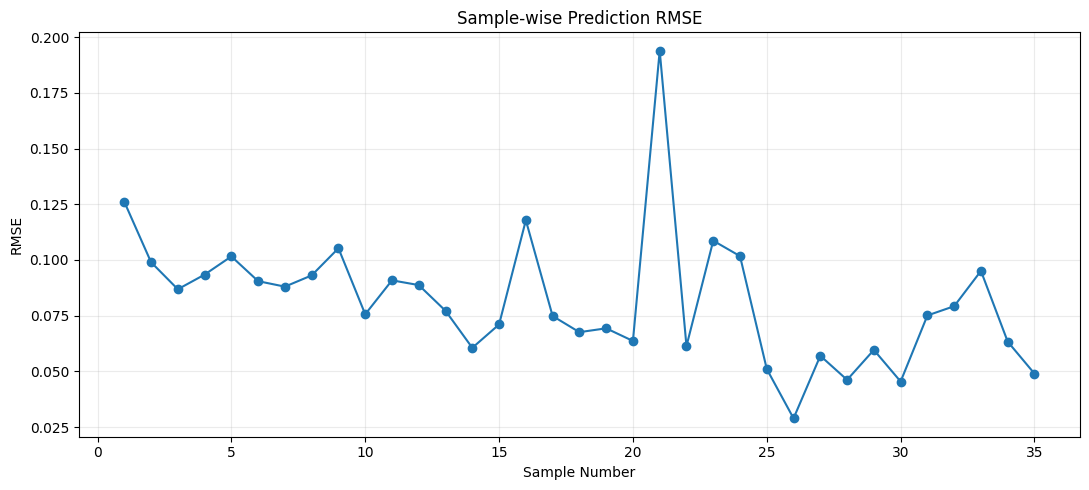

In [279]:
# ============================================================
# SAMPLE-WISE RMSE PLOT
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    np.arange(1, len(sample_rmse) + 1),
    sample_rmse,
    marker="o",
    linewidth=1.5
)

plt.xlabel("Sample Number")
plt.ylabel("RMSE")
plt.title("Sample-wise Prediction RMSE")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

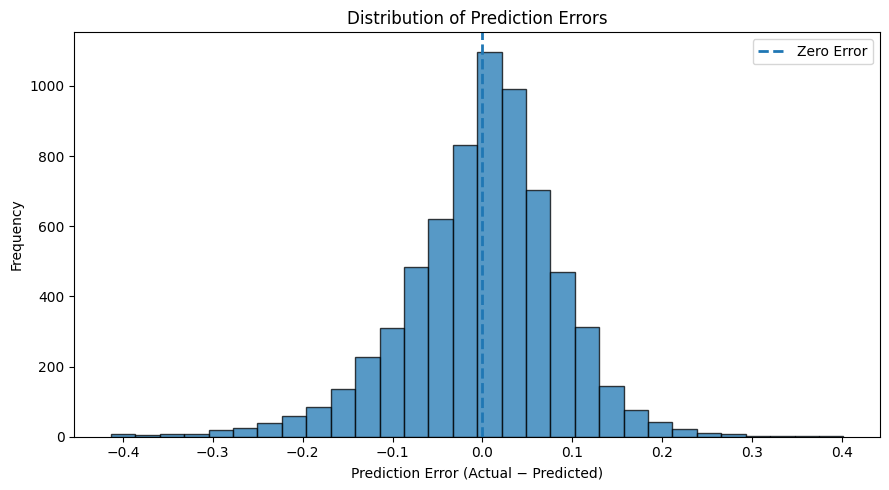

In [280]:
# ============================================================
# DISTRIBUTION OF PREDICTION ERRORS
# ============================================================

errors_flat = errors_193.flatten()

plt.figure(figsize=(9, 5))

plt.hist(
    errors_flat,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.xlabel("Prediction Error (Actual − Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.legend()

plt.tight_layout()
plt.show()

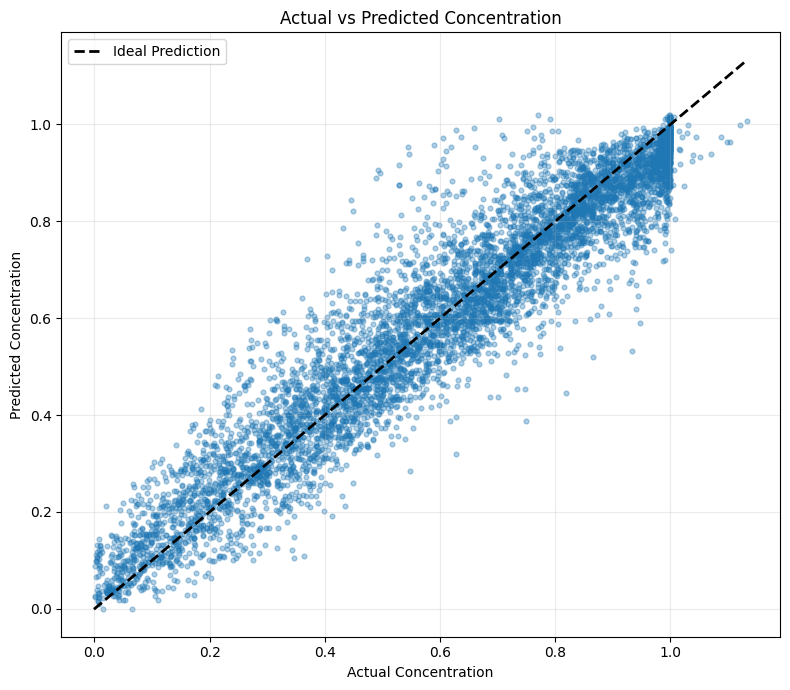

In [281]:
# ============================================================
# ACTUAL VS PREDICTED DIAGNOSTIC
# ============================================================

actual_flat = Y_actual_193.flatten()
pred_flat = Y_pred_final_193.flatten()

plt.figure(figsize=(8, 7))

plt.scatter(
    actual_flat,
    pred_flat,
    s=12,
    alpha=0.35
)

vmin = min(actual_flat.min(), pred_flat.min())
vmax = max(actual_flat.max(), pred_flat.max())

plt.plot(
    [vmin, vmax],
    [vmin, vmax],
    "k--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Concentration")
plt.ylabel("Predicted Concentration")
plt.title("Actual vs Predicted Concentration")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# **Prediction Test**

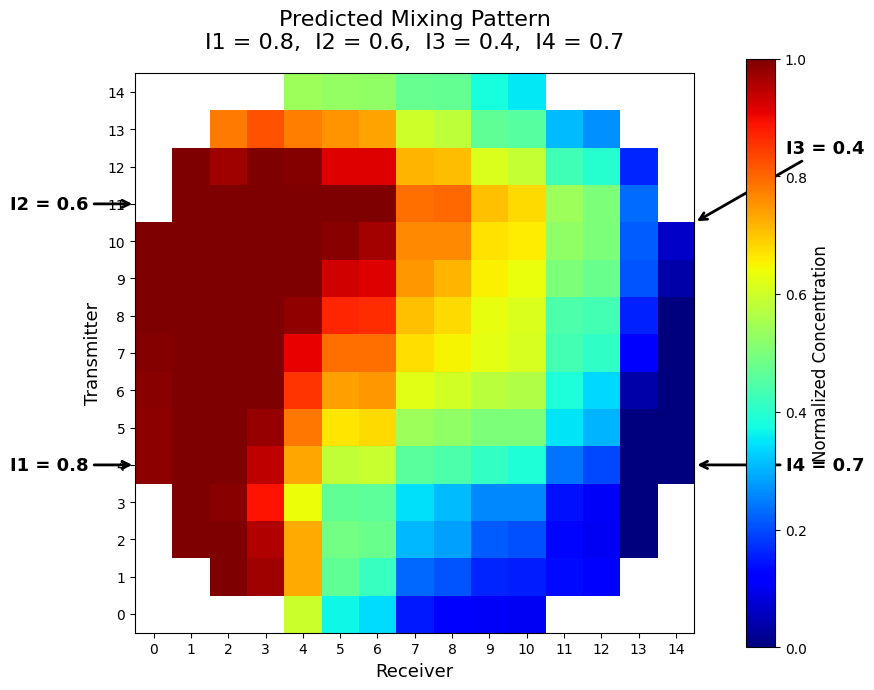

In [282]:
# ============================================================
# FINAL PREDICTED MIXING PATTERN — CLEAN INLET VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# IMPORTANT:
# 'prediction' must be the 193-point prediction generated
# in the previous cell.
# 'valid_mask' must be the 15x15 mask containing 193 valid cells.
# ------------------------------------------------------------

# Define input flow rates for the prediction
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7
user_flow_rates = [I1, I2, I3, I4]

# Generate prediction using the final model
prediction = predict_mixing_pattern(user_flow_rates)

pred = np.asarray(prediction).reshape(-1)

# Safety check
if pred.size != 193:
    raise ValueError(
        f"Expected 193 predicted values, but got {pred.size}."
    )

if np.asarray(valid_mask).size != 225:
    raise ValueError(
        "valid_mask must contain 225 elements (15 × 15)."
    )

# Convert mask to 15 × 15
mask = np.asarray(valid_mask).reshape(15, 15)

# ------------------------------------------------------------
# Create 15 × 15 grid
# Invalid cells remain NaN
# ------------------------------------------------------------

pred_grid = np.full((15, 15), np.nan)

pred_grid[mask] = pred

# ------------------------------------------------------------
# User-defined inlet conditions
# ------------------------------------------------------------

# I1 = 0.8 # Already defined above
# I2 = 0.6 # Already defined above
# I3 = 0.4 # Already defined above
# I4 = 0.7 # Already defined above

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    interpolation="nearest"
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel("Receiver", fontsize=13)
ax.set_ylabel("Transmitter", fontsize=13)

ax.set_xticks(np.arange(0, 15, 1))
ax.set_yticks(np.arange(0, 15, 1))

ax.tick_params(axis="both", labelsize=10)

# Keep the spatial grid properly aligned
ax.set_xlim(-0.5, 14.5)
ax.set_ylim(-0.5, 14.5)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    f"Predicted Mixing Pattern\n"
    f"I1 = {I1},  I2 = {I2},  I3 = {I3},  I4 = {I4}",
    fontsize=16,
    pad=18
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.08
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=12
)

# ------------------------------------------------------------
# INLET LABELS
# Placed OUTSIDE the heatmap so none are hidden
# ------------------------------------------------------------

# I1 — left / lower inlet
ax.annotate(
    f"I1 = {I1}",
    xy=(-0.5, 4),
    xytext=(-2.8, 4),
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

# I2 — left / upper inlet
ax.annotate(
    f"I2 = {I2}",
    xy=(-0.5, 11),
    xytext=(-2.8, 11),
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

# I3 — upper/right inlet
ax.annotate(
    f"I3 = {I3}",
    xy=(14.5, 10.5),
    xytext=(18.0, 12.5),
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

# I4 — right/lower inlet
ax.annotate(
    f"I4 = {I4}",
    xy=(14.5, 4),
    xytext=(18.0, 4),
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.18,
    right=0.82,
    bottom=0.10,
    top=0.88
)

plt.show()

In [283]:
# ============================================================
# TEST MULTIPLE USER-DEFINED MIXING CONDITIONS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Test cases
# ------------------------------------------------------------

test_cases = {
    "Case 1": [0.8, 0.6, 0.4, 0.7],
    "Case 2": [0.6, 0.6, 0.6, 0.6],
    "Case 3": [0.4, 0.8, 0.6, 0.2],
    "Case 4": [0.2, 0.4, 0.8, 0.6]
}

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

all_predictions = {}

for case_name, flows in test_cases.items():

    prediction_case = predict_mixing_pattern(flows)

    prediction_case = np.asarray(
        prediction_case
    ).reshape(-1)

    if prediction_case.size != 193:
        raise ValueError(
            f"{case_name}: Expected 193 values, "
            f"got {prediction_case.size}"
        )

    all_predictions[case_name] = prediction_case

    print(
        f"{case_name}: "
        f"I1={flows[0]}, "
        f"I2={flows[1]}, "
        f"I3={flows[2]}, "
        f"I4={flows[3]} "
        f"-> Prediction generated"
    )

print("\nAll test cases generated successfully.")

Case 1: I1=0.8, I2=0.6, I3=0.4, I4=0.7 -> Prediction generated
Case 2: I1=0.6, I2=0.6, I3=0.6, I4=0.6 -> Prediction generated
Case 3: I1=0.4, I2=0.8, I3=0.6, I4=0.2 -> Prediction generated
Case 4: I1=0.2, I2=0.4, I3=0.8, I4=0.6 -> Prediction generated

All test cases generated successfully.


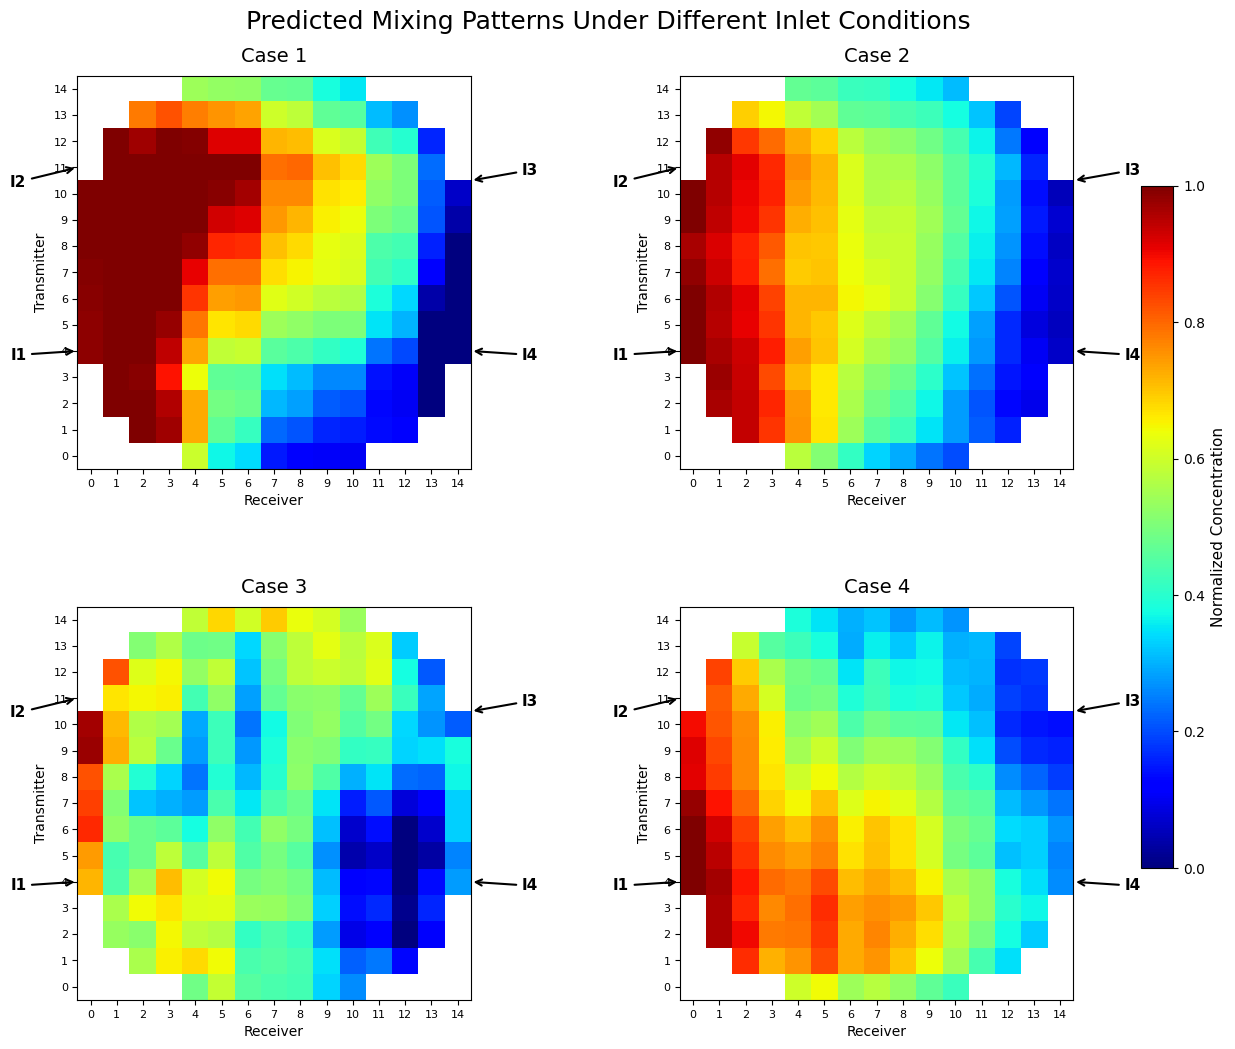

In [284]:
# ============================================================
# CLEAN COMPARISON OF PREDICTED MIXING PATTERNS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# USER-DEFINED TEST CASES
# ------------------------------------------------------------

test_cases = [
    {
        "name": "Case 1",
        "flows": [0.8, 0.6, 0.4, 0.7]
    },
    {
        "name": "Case 2",
        "flows": [0.6, 0.6, 0.6, 0.6]
    },
    {
        "name": "Case 3",
        "flows": [0.4, 0.8, 0.6, 0.2]
    },
    {
        "name": "Case 4",
        "flows": [0.2, 0.4, 0.8, 0.6]
    }
]

# ------------------------------------------------------------
# GENERATE PREDICTIONS
# ------------------------------------------------------------

case_grids = []

for case in test_cases:

    flows = case["flows"]

    case_prediction = predict_mixing_pattern(flows)

    case_prediction = np.asarray(case_prediction).reshape(-1)

    if case_prediction.size != 193:
        raise ValueError(
            f"{case['name']} returned {case_prediction.size} values. "
            "Expected 193."
        )

    grid = np.full((15, 15), np.nan)

    grid[valid_mask] = case_prediction

    case_grids.append(grid)

# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 11),
    constrained_layout=False
)

axes = axes.ravel()

# ------------------------------------------------------------
# FIXED INLET POSITIONS
# ------------------------------------------------------------

inlet_positions = {
    "I1": (-0.5, 4.0),
    "I2": (-0.5, 11.0),
    "I3": (14.5, 10.5),
    "I4": (14.5, 4.0)
}

# ------------------------------------------------------------
# PLOT EACH CASE
# ------------------------------------------------------------

for ax, case, grid in zip(axes, test_cases, case_grids):

    im = ax.imshow(
        grid,
        origin="lower",
        cmap="jet",
        vmin=0,
        vmax=1,
        interpolation="nearest",
        aspect="equal"
    )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_xlim(-0.5, 14.5)
    ax.set_ylim(-0.5, 14.5)

    ax.set_xticks(np.arange(15))
    ax.set_yticks(np.arange(15))

    ax.tick_params(
        axis="both",
        labelsize=8
    )

    ax.set_xlabel(
        "Receiver",
        fontsize=10
    )

    ax.set_ylabel(
        "Transmitter",
        fontsize=10
    )

    # --------------------------------------------------------
    # Case title
    # --------------------------------------------------------

    ax.set_title(
        case["name"],
        fontsize=14,
        pad=10
    )

    # --------------------------------------------------------
    # I1
    # --------------------------------------------------------

    ax.annotate(
        "I1",
        xy=inlet_positions["I1"],
        xytext=(-0.13, 0.29),
        textcoords="axes fraction",
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.5
        ),
        annotation_clip=False
    )

    # --------------------------------------------------------
    # I2
    # --------------------------------------------------------

    ax.annotate(
        "I2",
        xy=inlet_positions["I2"],
        xytext=(-0.13, 0.73),
        textcoords="axes fraction",
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.5
        ),
        annotation_clip=False
    )

    # --------------------------------------------------------
    # I3
    # --------------------------------------------------------

    ax.annotate(
        "I3",
        xy=inlet_positions["I3"],
        xytext=(1.13, 0.76),
        textcoords="axes fraction",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.5
        ),
        annotation_clip=False
    )

    # --------------------------------------------------------
    # I4
    # --------------------------------------------------------

    ax.annotate(
        "I4",
        xy=inlet_positions["I4"],
        xytext=(1.13, 0.29),
        textcoords="axes fraction",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.5
        ),
        annotation_clip=False
    )

# ------------------------------------------------------------
# GLOBAL TITLE
# ------------------------------------------------------------

fig.suptitle(
    "Predicted Mixing Patterns Under Different Inlet Conditions",
    fontsize=18,
    y=0.97
)

# ------------------------------------------------------------
# ONE COMMON COLORBAR
# ------------------------------------------------------------

cbar_ax = fig.add_axes(
    [0.91, 0.19, 0.025, 0.62]
)

cbar = fig.colorbar(
    im,
    cax=cbar_ax
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=11
)

# ------------------------------------------------------------
# SPACING
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.08,
    right=0.87,
    bottom=0.07,
    top=0.91,
    wspace=0.42,
    hspace=0.35
)

plt.show()

In [285]:
summary_rows = []

for case in test_cases:

    case_name = case["name"]
    flows = case["flows"]

    pred = all_predictions[case_name]

    summary_rows.append({
        "Case": case_name,
        "I1": flows[0],
        "I2": flows[1],
        "I3": flows[2],
        "I4": flows[3],
        "Minimum Prediction": np.min(pred),
        "Maximum Prediction": np.max(pred),
        "Mean Prediction": np.mean(pred),
        "Std. Deviation": np.std(pred)
    })

prediction_summary = pd.DataFrame(summary_rows)

display(prediction_summary)

,Case,I1,I2,I3,I4,Minimum Prediction,Maximum Prediction,Mean Prediction,Std. Deviation
0,Case 1,0.8,0.6,0.4,0.7,-0.062158,1.139009,0.611998,0.337256
1,Case 2,0.6,0.6,0.6,0.6,0.053376,1.010530,0.544279,0.264869
2,Case 3,0.4,0.8,0.6,0.2,-0.143175,0.976092,0.431234,0.196490
3,Case 4,0.2,0.4,0.8,0.6,0.137919,1.050865,0.559018,0.221202


In [286]:
# ============================================================
# CELL — SAVE MULTI-CASE PREDICTIONS
# ROBUST VERSION — DOES NOT DEPEND ON test_cases STRUCTURE
# ============================================================

import numpy as np
import pandas as pd

print("=" * 65)
print("SAVING MULTI-CASE PREDICTIONS")
print("=" * 65)

# ------------------------------------------------------------
# Original inlet conditions used for the four prediction cases
# ------------------------------------------------------------

CASE_FLOWS = {
    "Case 1": [0.8, 0.6, 0.4, 0.7],
    "Case 2": [0.6, 0.6, 0.6, 0.6],
    "Case 3": [0.4, 0.8, 0.6, 0.2],
    "Case 4": [0.2, 0.4, 0.8, 0.6]
}

# ------------------------------------------------------------
# Check that all_predictions exists
# ------------------------------------------------------------

if "all_predictions" not in globals():
    raise NameError(
        "all_predictions is not available. "
        "Run the multi-case prediction cell first."
    )

# ------------------------------------------------------------
# Create output DataFrame
# ------------------------------------------------------------

prediction_output = pd.DataFrame()

# ------------------------------------------------------------
# Save each prediction case
# ------------------------------------------------------------

for case_name, prediction_case in all_predictions.items():

    print(f"\nProcessing: {case_name}")

    # Check that inlet information exists
    if case_name not in CASE_FLOWS:
        raise ValueError(
            f"No inlet conditions stored for {case_name}."
        )

    flows = CASE_FLOWS[case_name]

    # Convert prediction to 1-D
    prediction_case = np.asarray(
        prediction_case
    ).reshape(-1)

    # --------------------------------------------------------
    # Confirm exactly 193 predicted spatial cells
    # --------------------------------------------------------

    if prediction_case.size != 193:
        raise ValueError(
            f"{case_name}: expected 193 predictions, "
            f"got {prediction_case.size}"
        )

    # --------------------------------------------------------
    # Create descriptive column name
    # --------------------------------------------------------

    column_name = (
        f"{case_name}_"
        f"I1_{flows[0]}_"
        f"I2_{flows[1]}_"
        f"I3_{flows[2]}_"
        f"I4_{flows[3]}"
    )

    # --------------------------------------------------------
    # Store prediction
    # --------------------------------------------------------

    prediction_output[column_name] = prediction_case

    print(
        f"  I1={flows[0]}, "
        f"I2={flows[1]}, "
        f"I3={flows[2]}, "
        f"I4={flows[3]}"
    )

    print(
        f"  Prediction points: {prediction_case.size}"
    )

# ============================================================
# SAVE CSV
# ============================================================

OUTPUT_FILE = "mixing_predictions_test_cases.csv"

prediction_output.to_csv(
    OUTPUT_FILE,
    index=False
)

# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 65)
print("MULTI-CASE PREDICTIONS SAVED")
print("=" * 65)

print("\nFile:")
print(OUTPUT_FILE)

print("\nNumber of cases:")
print(prediction_output.shape[1])

print("\nPredictions per case:")
print(prediction_output.shape[0])

print("\n✓ Expected cases: 4")
print("✓ Expected predictions per case: 193")

if prediction_output.shape != (193, 4):
    raise ValueError(
        f"Unexpected output shape: {prediction_output.shape}. "
        "Expected (193, 4)."
    )

print("\n✓ CSV structure verified.")

display(prediction_output.head())

SAVING MULTI-CASE PREDICTIONS

Processing: Case 1
  I1=0.8, I2=0.6, I3=0.4, I4=0.7
  Prediction points: 193

Processing: Case 2
  I1=0.6, I2=0.6, I3=0.6, I4=0.6
  Prediction points: 193

Processing: Case 3
  I1=0.4, I2=0.8, I3=0.6, I4=0.2
  Prediction points: 193

Processing: Case 4
  I1=0.2, I2=0.4, I3=0.8, I4=0.6
  Prediction points: 193

MULTI-CASE PREDICTIONS SAVED

File:
mixing_predictions_test_cases.csv

Number of cases:
4

Predictions per case:
193

✓ Expected cases: 4
✓ Expected predictions per case: 193

✓ CSV structure verified.


,Case 1_I1_0.8_I2_0.6_I3_0.4_I4_0.7,Case 2_I1_0.6_I2_0.6_I3_0.6_I4_0.6,Case 3_I1_0.4_I2_0.8_I3_0.6_I4_0.2,Case 4_I1_0.2_I2_0.4_I3_0.8_I4_0.6
0,0.595110,0.576761,0.485556,0.600384
1,0.369167,0.508360,0.588089,0.643326
2,0.340043,0.412324,0.455187,0.540895
3,0.149881,0.332293,0.440558,0.570327
4,0.119034,0.294759,0.433264,0.530374


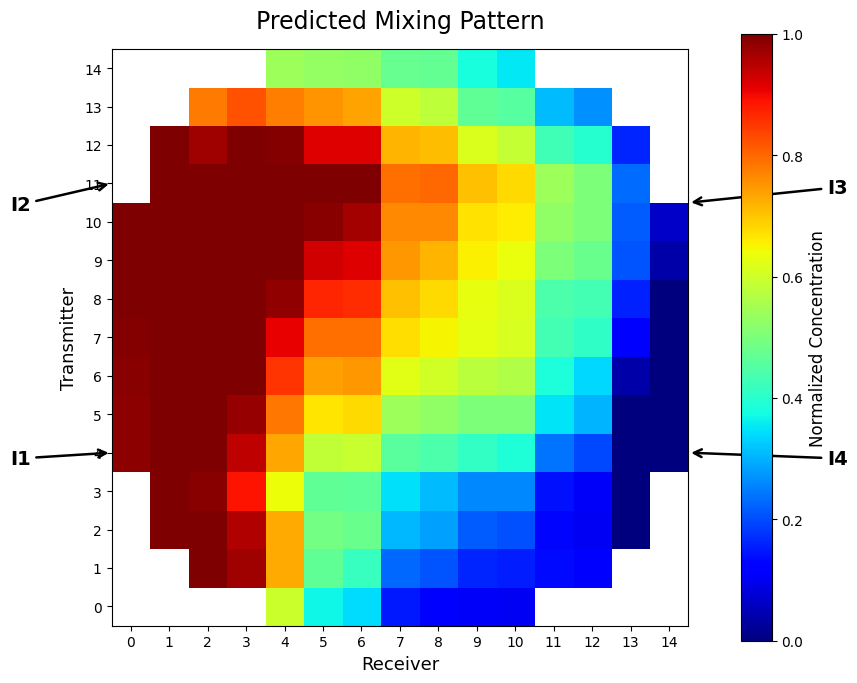

In [287]:
# ============================================================
# FINAL CLEAN PREDICTED MIXING PATTERN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Convert prediction to 193-point vector
# ------------------------------------------------------------

pred = np.asarray(prediction).reshape(-1)

if pred.size != 193:
    raise ValueError(
        f"Expected 193 prediction values, but received {pred.size}."
    )

# ------------------------------------------------------------
# Prepare 15 x 15 spatial mask
# ------------------------------------------------------------

mask = np.asarray(valid_mask).reshape(15, 15)

if mask.sum() != 193:
    raise ValueError(
        f"Expected 193 valid cells, but mask contains {mask.sum()}."
    )

# ------------------------------------------------------------
# Put prediction into spatial grid
# ------------------------------------------------------------

pred_grid = np.full((15, 15), np.nan)
pred_grid[mask] = pred

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel("Receiver", fontsize=13)
ax.set_ylabel("Transmitter", fontsize=13)

ax.set_xticks(np.arange(15))
ax.set_yticks(np.arange(15))

ax.set_xlim(-0.5, 14.5)
ax.set_ylim(-0.5, 14.5)

ax.tick_params(labelsize=10)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Predicted Mixing Pattern",
    fontsize=17,
    pad=15
)

# ------------------------------------------------------------
# INLET LOCATIONS
#
# IMPORTANT:
# These coordinates are kept fixed for every case.
# ------------------------------------------------------------

inlet_positions = {
    "I1": (-0.5, 4.0),
    "I2": (-0.5, 11.0),
    "I3": (14.5, 10.5),
    "I4": (14.5, 4.0)
}

# ------------------------------------------------------------
# Clean inlet annotations
# ------------------------------------------------------------

ax.annotate(
    "I1",
    xy=inlet_positions["I1"],
    xytext=(-0.14, 0.29),
    textcoords="axes fraction",
    ha="right",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.8
    ),
    annotation_clip=False
)

ax.annotate(
    "I2",
    xy=inlet_positions["I2"],
    xytext=(-0.14, 0.73),
    textcoords="axes fraction",
    ha="right",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.8
    ),
    annotation_clip=False
)

ax.annotate(
    "I3",
    xy=inlet_positions["I3"],
    xytext=(1.24, 0.76),
    textcoords="axes fraction",
    ha="left",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.8
    ),
    annotation_clip=False
)

ax.annotate(
    "I4",
    xy=inlet_positions["I4"],
    xytext=(1.24, 0.29),
    textcoords="axes fraction",
    ha="left",
    va="center",
    fontsize=14,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.8
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.08
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=12
)

# ------------------------------------------------------------
# Final layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.18,
    right=0.84,
    bottom=0.10,
    top=0.90
)

plt.show()

In [288]:
# ============================================================
# CELL 4 — FIT FINAL POLYNOMIAL RIDGE MODELS
# ============================================================

import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

print("=" * 65)
print("FITTING POLYNOMIAL RIDGE MODELS")
print("=" * 65)

# ------------------------------------------------------------
# 1. FIND EXISTING DATA
# ------------------------------------------------------------

# Use the variables already created in the notebook.
# Common variable names are checked automatically.

X_candidates = ["X", "X_data", "X_input", "inputs", "features"]
Y_candidates = ["Y", "Y_data", "Y_output", "outputs", "targets"]

X_data = None
Y_data = None

for name in X_candidates:
    if name in globals():
        value = globals()[name]
        if isinstance(value, (np.ndarray, list)):
            arr = np.asarray(value)
            if arr.ndim == 2 and arr.shape[1] == 4:
                X_data = arr
                print(f"Input data found in variable: {name}")
                break

for name in Y_candidates:
    if name in globals():
        value = globals()[name]
        if isinstance(value, (np.ndarray, list)):
            arr = np.asarray(value)
            if arr.ndim == 2:
                Y_data = arr
                print(f"Output data found in variable: {name}")
                break

if X_data is None:
    raise NameError(
        "Could not find the 4-inlet input data. "
        "Expected a variable such as X or X_data."
    )

if Y_data is None:
    raise NameError(
        "Could not find the concentration output data. "
        "Expected a variable such as Y or Y_data."
    )

X_data = np.asarray(X_data, dtype=float)
Y_data = np.asarray(Y_data, dtype=float)

print("\nInput shape :", X_data.shape)
print("Output shape:", Y_data.shape)

# ------------------------------------------------------------
# 2. ENSURE OUTPUT HAS 225 SPATIAL CELLS
# ------------------------------------------------------------

if Y_data.shape[1] == 225:
    Y_225 = Y_data.copy()

elif Y_data.shape[1] == 193:

    # If only the 193 valid cells are stored, use valid_mask
    if "valid_mask" not in globals():
        raise NameError(
            "Y contains 193 cells but valid_mask was not found."
        )

    mask = np.asarray(valid_mask).reshape(15, 15).astype(bool)

    if mask.sum() != 193:
        raise ValueError(
            f"Expected 193 valid cells, found {mask.sum()}."
        )

    Y_225 = np.full((Y_data.shape[0], 225), np.nan)
    Y_225[:, mask.flatten()] = Y_data

else:
    raise ValueError(
        f"Unexpected Y shape: {Y_data.shape}. "
        "Expected 193 or 225 output cells."
    )

# ------------------------------------------------------------
# 3. CREATE/FIND THE 193-CELL MASK
# ------------------------------------------------------------

if "valid_mask" not in globals():

    # Automatically determine valid cells from the dataset
    valid_mask = ~np.all(np.isnan(Y_225), axis=0).reshape(15, 15)

else:
    valid_mask = np.asarray(valid_mask).reshape(15, 15).astype(bool)

valid_indices = np.where(valid_mask.flatten())[0]

print("Valid spatial cells:", len(valid_indices))

if len(valid_indices) != 193:
    raise ValueError(
        f"Expected exactly 193 valid cells, found {len(valid_indices)}."
    )

# ------------------------------------------------------------
# 4. FIT ONE POLYNOMIAL RIDGE MODEL PER VALID CELL
# ------------------------------------------------------------

poly_degree = 2
alpha = 1.0

poly_ridge_models = {}

for cell_idx in valid_indices:

    y_cell = Y_225[:, cell_idx]

    # Remove samples where this particular output is missing
    valid_samples = np.isfinite(y_cell)

    if valid_samples.sum() < 5:
        continue

    model = Pipeline([
        (
            "poly",
            PolynomialFeatures(
                degree=poly_degree,
                include_bias=False
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(alpha=alpha)
        )
    ])

    model.fit(
        X_data[valid_samples],
        y_cell[valid_samples]
    )

    poly_ridge_models[cell_idx] = model

print("\nModels fitted successfully.")
print("Number of fitted spatial models:", len(poly_ridge_models))
print("Polynomial degree:", poly_degree)
print("Ridge alpha:", alpha)

if len(poly_ridge_models) != 193:
    print(
        f"WARNING: Only {len(poly_ridge_models)} models were fitted "
        "instead of 193."
    )
else:
    print("All 193 spatial models are ready.")

print("=" * 65)

FITTING POLYNOMIAL RIDGE MODELS
Input data found in variable: X
Output data found in variable: Y

Input shape : (35, 4)
Output shape: (35, 225)
Valid spatial cells: 193

Models fitted successfully.
Number of fitted spatial models: 193
Polynomial degree: 2
Ridge alpha: 1.0
All 193 spatial models are ready.


GENERATING PREDICTED MIXING PATTERN

User inlet condition:
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

Prediction generated successfully.
Prediction shape: (193,)
Valid spatial points: 193


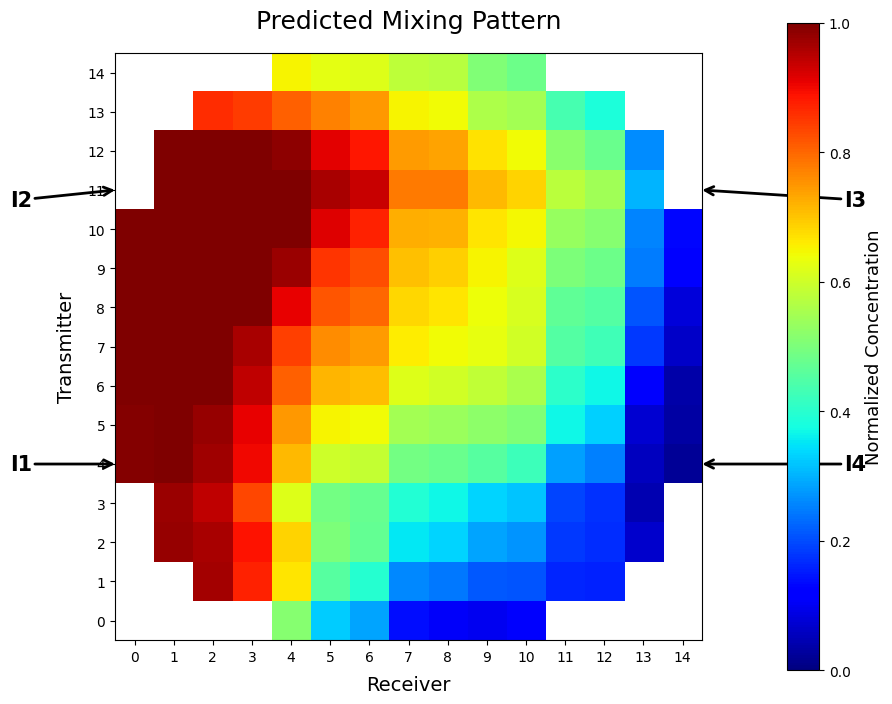


FINAL PREDICTION COMPLETE


In [289]:
# ============================================================
# CELL 5 — FINAL PREDICTION + CLEAN MIXING PATTERN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("GENERATING PREDICTED MIXING PATTERN")
print("=" * 65)

# ------------------------------------------------------------
# USER-DEFINED INLET CONDITIONS
# ------------------------------------------------------------

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

user_input = np.array([[I1, I2, I3, I4]], dtype=float)

print("\nUser inlet condition:")
print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"I3 = {I3}")
print(f"I4 = {I4}")

# ------------------------------------------------------------
# CHECK THAT MODELS EXIST
# ------------------------------------------------------------

if "poly_ridge_models" not in globals():
    raise NameError(
        "poly_ridge_models not found. Run CELL 4 first."
    )

if "valid_mask" not in globals():
    raise NameError(
        "valid_mask not found. Run CELL 4 first."
    )

# ------------------------------------------------------------
# PREDICT ALL 193 VALID CELLS
# ------------------------------------------------------------

prediction_grid = np.full(225, np.nan)

for cell_idx, model in poly_ridge_models.items():

    prediction_grid[cell_idx] = model.predict(user_input)[0]

# Extract only valid predictions
prediction = prediction_grid[valid_mask.flatten()]

if prediction.size != 193:
    raise ValueError(
        f"Expected 193 predictions, got {prediction.size}."
    )

print("\nPrediction generated successfully.")
print("Prediction shape:", prediction.shape)
print("Valid spatial points:", prediction.size)

# ------------------------------------------------------------
# OPTIONAL: KEEP CONCENTRATION WITHIN PHYSICAL RANGE
# ------------------------------------------------------------

prediction = np.clip(prediction, 0, 1)

# Put clipped predictions back into 225-cell grid
prediction_grid = np.full(225, np.nan)
prediction_grid[valid_mask.flatten()] = prediction

pred_grid = prediction_grid.reshape(15, 15)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_xlabel(
    "Receiver",
    fontsize=14,
    labelpad=8
)

ax.set_ylabel(
    "Transmitter",
    fontsize=14,
    labelpad=8
)

ax.set_xticks(np.arange(15))
ax.set_yticks(np.arange(15))

ax.tick_params(
    axis="both",
    labelsize=10
)

# Exact spatial boundaries
ax.set_xlim(-0.5, 14.5)
ax.set_ylim(-0.5, 14.5)

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

ax.set_title(
    "Predicted Mixing Pattern",
    fontsize=18,
    pad=18
)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.12
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=13,
    labelpad=10
)

cbar.ax.tick_params(labelsize=10)

# ------------------------------------------------------------
# INLET POSITIONS
#
# These positions correspond to the physical boundaries
# of the mixing domain.
# ------------------------------------------------------------

# I1 — left lower
I1_xy = (-0.5, 4)

# I2 — left upper
I2_xy = (-0.5, 11)

# I3 — right upper
I3_xy = (14.5, 11)

# I4 — right lower
I4_xy = (14.5, 4)

# ------------------------------------------------------------
# I1 ARROW
# ------------------------------------------------------------

ax.annotate(
    "I1",
    xy=I1_xy,
    xycoords="data",
    xytext=(-0.16, 0.30),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# I2 ARROW
# ------------------------------------------------------------

ax.annotate(
    "I2",
    xy=I2_xy,
    xycoords="data",
    xytext=(-0.16, 0.75),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# I3 ARROW
# ------------------------------------------------------------

ax.annotate(
    "I3",
    xy=I3_xy,
    xycoords="data",
    xytext=(1.26, 0.75),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# I4 ARROW
# ------------------------------------------------------------

ax.annotate(
    "I4",
    xy=I4_xy,
    xycoords="data",
    xytext=(1.26, 0.30),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.18,
    right=0.82,
    bottom=0.10,
    top=0.90
)

plt.show()

print("\n" + "=" * 65)
print("FINAL PREDICTION COMPLETE")
print("=" * 65)

In [290]:
# ============================================================
# CELL 6 — FINAL PREDICTION FUNCTION
# ============================================================

import numpy as np

def get_mixing_prediction(I1, I2, I3, I4):
    """
    Generate predicted concentration at the 193 valid spatial cells.
    """

    user_flow_rates = [I1, I2, I3, I4]

    prediction = predict_mixing_pattern(user_flow_rates)

    prediction = np.asarray(prediction).reshape(-1)

    if prediction.size != 193:
        raise ValueError(
            f"Expected 193 predicted values, but received {prediction.size}."
        )

    return prediction


print("Prediction function ready.")
print("Input : I1, I2, I3, I4")
print("Output: 193 predicted concentration values")

Prediction function ready.
Input : I1, I2, I3, I4
Output: 193 predicted concentration values


In [291]:
# ============================================================
# CELL 7 — FINAL CLEAN MIXING-PATTERN PLOT FUNCTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def plot_mixing_pattern(prediction, I1, I2, I3, I4):

    pred = np.asarray(prediction).reshape(-1)

    if pred.size != 193:
        raise ValueError(
            f"Expected 193 prediction values, got {pred.size}."
        )

    mask = np.asarray(valid_mask).reshape(15, 15)

    # Create empty 15 x 15 spatial grid
    pred_grid = np.full((15, 15), np.nan)

    # Insert predictions only into valid cells
    pred_grid[mask] = pred

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        pred_grid,
        origin="lower",
        cmap="jet",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------
    ax.set_xlabel("Receiver", fontsize=13)
    ax.set_ylabel("Transmitter", fontsize=13)

    ax.set_xticks(np.arange(15))
    ax.set_yticks(np.arange(15))

    ax.tick_params(axis="both", labelsize=10)

    ax.set_xlim(-0.5, 14.5)
    ax.set_ylim(-0.5, 14.5)

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------
    ax.set_title(
        "Predicted Mixing Pattern",
        fontsize=17,
        pad=15
    )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.08
    )

    cbar.set_label(
        "Normalized Concentration",
        fontsize=12
    )

    # --------------------------------------------------------
    # INLETS
    # Only inlet names — NO numerical values
    # --------------------------------------------------------

    # I1 — left lower
    ax.annotate(
        "I1",
        xy=(-0.5, 4),
        xytext=(-2.0, 4),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    # I2 — left upper
    ax.annotate(
        "I2",
        xy=(-0.5, 11),
        xytext=(-2.0, 11),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    # I3 — right upper
    ax.annotate(
        "I3",
        xy=(14.5, 11),
        xytext=(17, 12),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    # I4 — right lower
    ax.annotate(
        "I4",
        xy=(14.5, 4),
        xytext=(17, 4),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        annotation_clip=False
    )

    plt.subplots_adjust(
        left=0.17,
        right=0.84,
        bottom=0.10,
        top=0.90
    )

    plt.show()

In [292]:
# ============================================================
# CELL 8 — TEST FINAL PREDICTION PIPELINE
# ============================================================

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

prediction = get_mixing_prediction(I1, I2, I3, I4)

print("=" * 60)
print("FINAL PREDICTION TEST")
print("=" * 60)

print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"I3 = {I3}")
print(f"I4 = {I4}")

print("\nPrediction shape:", prediction.shape)
print("Valid spatial cells:", len(prediction))
print("Minimum:", prediction.min())
print("Maximum:", prediction.max())
print("Mean:", prediction.mean())

FINAL PREDICTION TEST
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

Prediction shape: (193,)
Valid spatial cells: 193
Minimum: -0.062158036561766286
Maximum: 1.1390090608165533
Mean: 0.6119976614033165


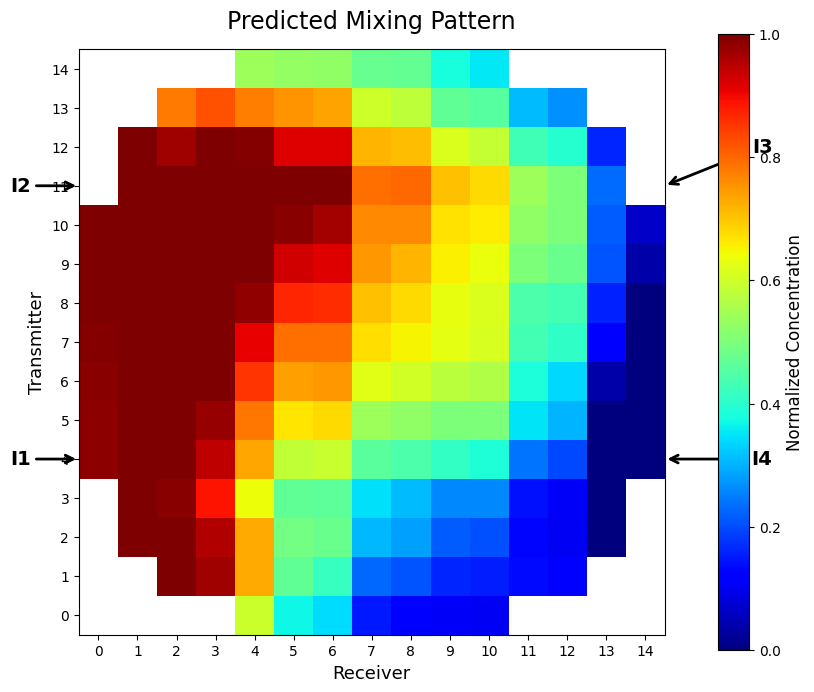

In [293]:
# ============================================================
# CELL 9 — FINAL CLEAN PREDICTION VISUALIZATION
# ============================================================

plot_mixing_pattern(
    prediction,
    I1,
    I2,
    I3,
    I4
)

In [294]:
# ============================================================
# CELL 10 — MULTIPLE USER-DEFINED PREDICTION CASES
# ============================================================

test_cases = {
    "Case 1": [0.8, 0.6, 0.4, 0.7],
    "Case 2": [0.6, 0.6, 0.6, 0.6],
    "Case 3": [0.4, 0.8, 0.6, 0.2],
    "Case 4": [0.2, 0.4, 0.8, 0.6]
}

all_predictions = {}

for case_name, flows in test_cases.items():

    pred = get_mixing_prediction(*flows)

    all_predictions[case_name] = pred

    print(
        f"{case_name}: "
        f"I1={flows[0]}, "
        f"I2={flows[1]}, "
        f"I3={flows[2]}, "
        f"I4={flows[3]} "
        f"-> {pred.shape}"
    )

print("\nAll test cases generated successfully.")

Case 1: I1=0.8, I2=0.6, I3=0.4, I4=0.7 -> (193,)
Case 2: I1=0.6, I2=0.6, I3=0.6, I4=0.6 -> (193,)
Case 3: I1=0.4, I2=0.8, I3=0.6, I4=0.2 -> (193,)
Case 4: I1=0.2, I2=0.4, I3=0.8, I4=0.6 -> (193,)

All test cases generated successfully.


In [295]:
# ============================================================
# CELL 11 — DATA PREPARATION FOR MODEL COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

print("=" * 65)
print("PREPARING DATA FOR MODEL COMPARISON")
print("=" * 65)

# Convert input and output data to NumPy
X_compare = np.asarray(X, dtype=float)
Y_compare = np.asarray(Y, dtype=float)

print("Original X shape:", X_compare.shape)
print("Original Y shape:", Y_compare.shape)

# ------------------------------------------------------------
# Keep only the 193 physically valid spatial cells
# ------------------------------------------------------------

mask_flat = np.asarray(valid_mask).reshape(-1)

if mask_flat.size != 225:
    raise ValueError("valid_mask must contain 225 cells.")

if Y_compare.shape[1] == 225:
    Y_compare = Y_compare[:, mask_flat]
elif Y_compare.shape[1] == 193:
    pass
else:
    raise ValueError(
        f"Unexpected Y shape: {Y_compare.shape}. "
        "Expected 225 or 193 output cells."
    )

print("Final X shape:", X_compare.shape)
print("Final Y shape:", Y_compare.shape)

if X_compare.shape[1] != 4:
    raise ValueError(
        f"Expected 4 inlet inputs, but X has {X_compare.shape[1]} features."
    )

if Y_compare.shape[1] != 193:
    raise ValueError(
        f"Expected 193 valid output cells, got {Y_compare.shape[1]}."
    )

# ------------------------------------------------------------
# Fixed train/test split
# ------------------------------------------------------------

X_train_cmp, X_test_cmp, Y_train_cmp, Y_test_cmp = train_test_split(
    X_compare,
    Y_compare,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train_cmp))
print("Testing samples :", len(X_test_cmp))
print("Output cells    :", Y_train_cmp.shape[1])

print("\nData preparation completed successfully.")

PREPARING DATA FOR MODEL COMPARISON
Original X shape: (35, 4)
Original Y shape: (35, 225)
Final X shape: (35, 4)
Final Y shape: (35, 193)

Training samples: 28
Testing samples : 7
Output cells    : 193

Data preparation completed successfully.


In [296]:
# ============================================================
# CELL 12 — TRAIN MULTIPLE ML MODELS
# ============================================================

import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor

print("=" * 65)
print("TRAINING MODEL COMPARISON")
print("=" * 65)

models = {}

# ------------------------------------------------------------
# 1. Polynomial Ridge
# ------------------------------------------------------------

models["Polynomial Ridge"] = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# ------------------------------------------------------------
# 2. Random Forest
# ------------------------------------------------------------

models["Random Forest"] = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 3. Extra Trees
# ------------------------------------------------------------

models["Extra Trees"] = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 4. XGBoost
# ------------------------------------------------------------

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )

    print("XGBoost available.")

except Exception as e:
    print("XGBoost not available — skipping it.")

# ------------------------------------------------------------
# Train models
# ------------------------------------------------------------

trained_models = {}
training_times = {}

for name, model in models.items():

    print(f"\nTraining: {name}")

    start = time.time()

    model.fit(
        X_train_cmp,
        Y_train_cmp
    )

    elapsed = time.time() - start

    trained_models[name] = model
    training_times[name] = elapsed

    print(f"Completed in {elapsed:.2f} seconds.")

print("\n" + "=" * 65)
print("ALL AVAILABLE MODELS TRAINED")
print("=" * 65)

for name in trained_models:
    print("✓", name)

TRAINING MODEL COMPARISON
XGBoost available.

Training: Polynomial Ridge
Completed in 0.00 seconds.

Training: Random Forest
Completed in 0.61 seconds.

Training: Extra Trees
Completed in 0.42 seconds.

Training: XGBoost
Completed in 22.26 seconds.

ALL AVAILABLE MODELS TRAINED
✓ Polynomial Ridge
✓ Random Forest
✓ Extra Trees
✓ XGBoost


In [297]:
# ============================================================
# CELL 13 — MODEL EVALUATION
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=" * 65)
print("MODEL EVALUATION")
print("=" * 65)

comparison_results = []

predictions_test = {}

for name, model in trained_models.items():

    print(f"\nEvaluating: {name}")

    pred = model.predict(X_test_cmp)

    pred = np.asarray(pred)

    predictions_test[name] = pred

    # Overall metrics across all test samples and valid cells
    r2 = r2_score(
        Y_test_cmp.reshape(-1),
        pred.reshape(-1)
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_test_cmp.reshape(-1),
            pred.reshape(-1)
        )
    )

    mae = mean_absolute_error(
        Y_test_cmp.reshape(-1),
        pred.reshape(-1)
    )

    comparison_results.append({
        "Model": name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Training Time (s)": training_times[name]
    })

    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

comparison_df = pd.DataFrame(comparison_results)

print("\n" + "=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)

display(
    comparison_df.sort_values(
        by="R²",
        ascending=False
    ).reset_index(drop=True)
)

MODEL EVALUATION

Evaluating: Polynomial Ridge
R²   : 0.9040
RMSE : 0.083790
MAE  : 0.062906

Evaluating: Random Forest
R²   : 0.8488
RMSE : 0.105162
MAE  : 0.077865

Evaluating: Extra Trees
R²   : 0.8259
RMSE : 0.112847
MAE  : 0.083938

Evaluating: XGBoost
R²   : 0.8389
RMSE : 0.108544
MAE  : 0.081125

FINAL MODEL COMPARISON


,Model,R²,RMSE,MAE,Training Time (s)
0,Polynomial Ridge,0.903988,0.083790,0.062906,0.003738
1,Random Forest,0.848763,0.105162,0.077865,0.607625
2,XGBoost,0.838880,0.108544,0.081125,22.256399
3,Extra Trees,0.825851,0.112847,0.083938,0.419083


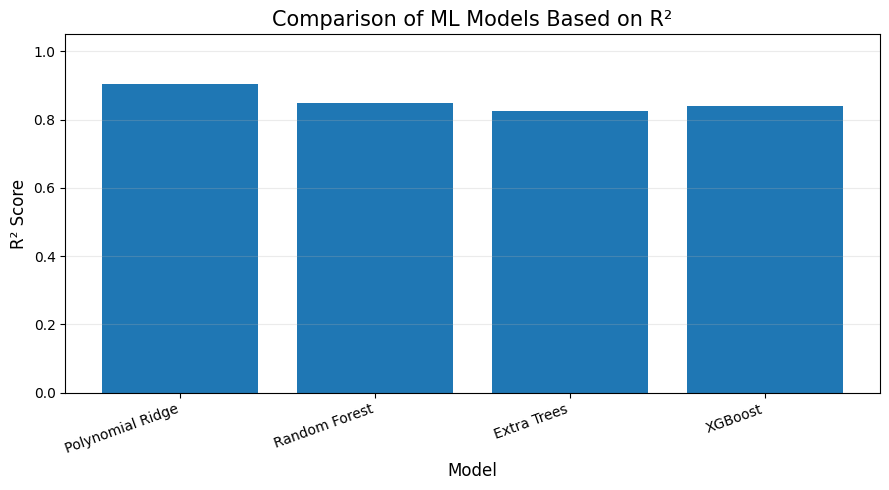

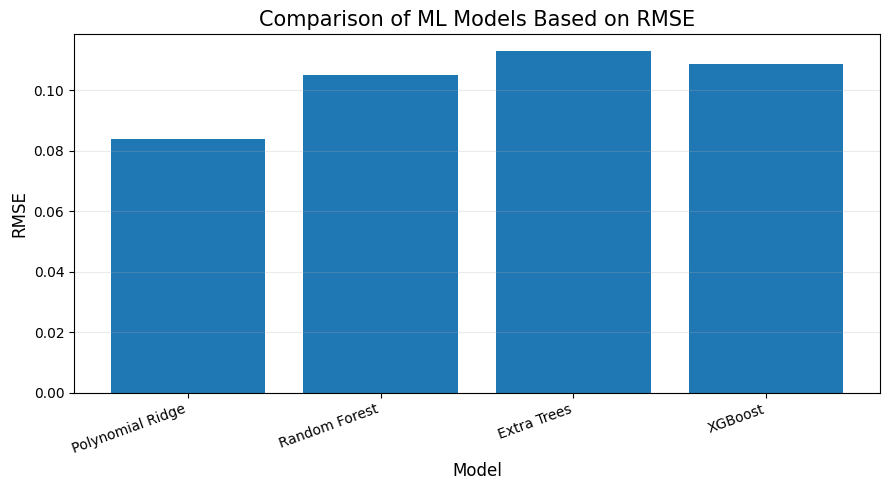

In [298]:
# ============================================================
# CELL 14 — MODEL COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

df_plot = comparison_df.copy()

# ------------------------------------------------------------
# R² comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    df_plot["Model"],
    df_plot["R²"]
)

plt.ylabel("R² Score", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.title("Comparison of ML Models Based on R²", fontsize=15)

plt.ylim(
    min(0, df_plot["R²"].min() - 0.05),
    1.05
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# RMSE comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    df_plot["Model"],
    df_plot["RMSE"]
)

plt.ylabel("RMSE", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.title("Comparison of ML Models Based on RMSE", fontsize=15)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

BEST MODEL FOR TEST-SET VISUALIZATION
Model: Polynomial Ridge


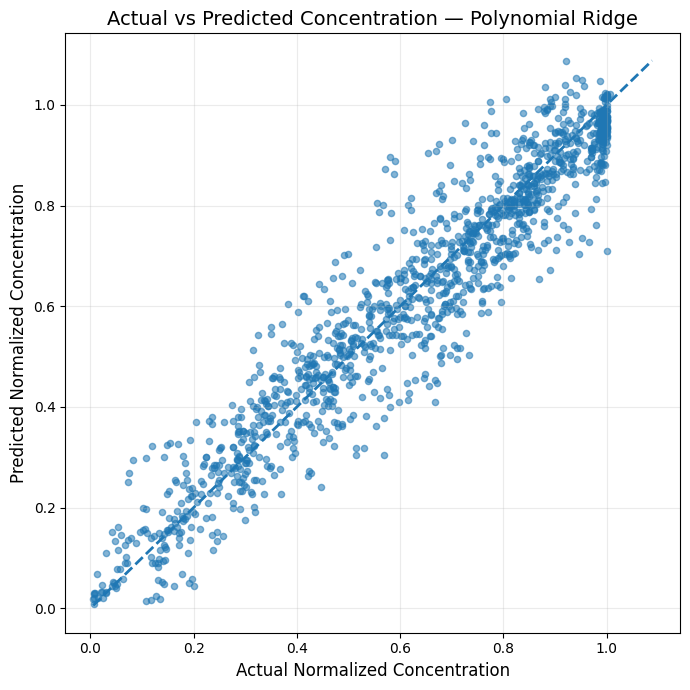

In [299]:
# ============================================================
# CELL 15 — ACTUAL VS PREDICTED COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Select the model with highest R²
best_model_name = comparison_df.loc[
    comparison_df["R²"].idxmax(),
    "Model"
]

best_test_prediction = predictions_test[best_model_name]

actual_values = Y_test_cmp.reshape(-1)
predicted_values = best_test_prediction.reshape(-1)

print("=" * 65)
print("BEST MODEL FOR TEST-SET VISUALIZATION")
print("=" * 65)

print("Model:", best_model_name)

# ------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    actual_values,
    predicted_values,
    alpha=0.55,
    s=20
)

# Perfect prediction line
minimum = min(
    actual_values.min(),
    predicted_values.min()
)

maximum = max(
    actual_values.max(),
    predicted_values.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Actual Normalized Concentration",
    fontsize=12
)

plt.ylabel(
    "Predicted Normalized Concentration",
    fontsize=12
)

plt.title(
    f"Actual vs Predicted Concentration — {best_model_name}",
    fontsize=14
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

USER-DEFINED MIXING CONDITION
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

Prediction generated successfully.
Prediction shape: (193,)
Minimum: 0.06572665868041203
Maximum: 1.0844171723373879
Mean: 0.610298727890067


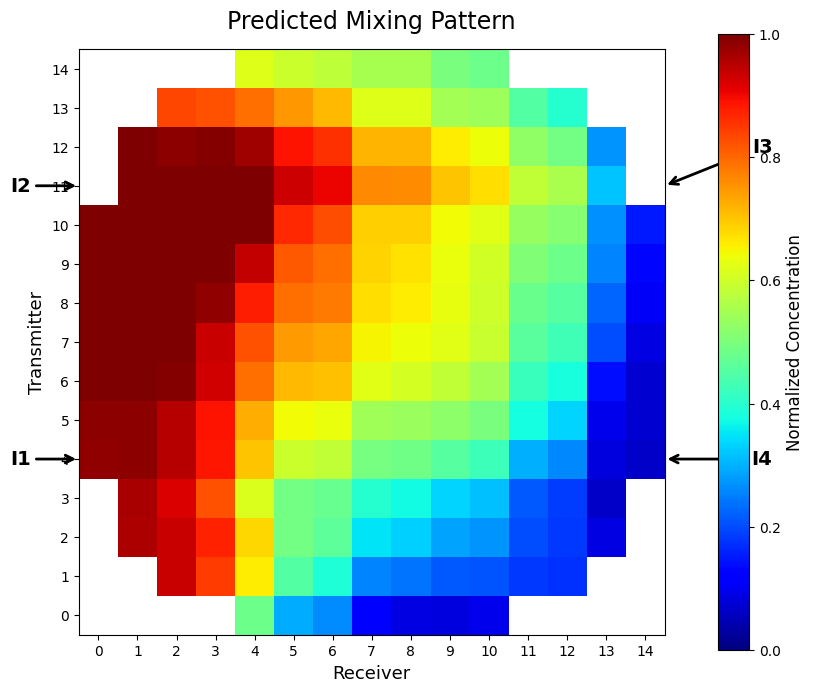

In [300]:
# ============================================================
# CELL 16 — FINAL USER INPUT PREDICTION DEMO
# ============================================================

# ------------------------------------------------------------
# ENTER YOUR FOUR INLET CONDITIONS HERE
# ------------------------------------------------------------

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

user_input = np.array([
    I1, I2, I3, I4
], dtype=float).reshape(1, -1)

print("=" * 65)
print("USER-DEFINED MIXING CONDITION")
print("=" * 65)

print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"I3 = {I3}")
print(f"I4 = {I4}")

# ------------------------------------------------------------
# Use the selected best model
# ------------------------------------------------------------

final_model = trained_models[best_model_name]

user_prediction = final_model.predict(
    user_input
)

user_prediction = np.asarray(
    user_prediction
).reshape(-1)

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if user_prediction.size != 193:
    raise ValueError(
        f"Expected 193 predicted cells, "
        f"got {user_prediction.size}."
    )

print("\nPrediction generated successfully.")
print("Prediction shape:", user_prediction.shape)
print("Minimum:", user_prediction.min())
print("Maximum:", user_prediction.max())
print("Mean:", user_prediction.mean())

# ------------------------------------------------------------
# Use our FINAL clean plotting function
# ------------------------------------------------------------

plot_mixing_pattern(
    user_prediction,
    I1,
    I2,
    I3,
    I4
)

In [301]:
# ============================================================
# CELL 17 — SAVE FINAL MODEL FOR WEBSITE
# ============================================================

import pickle
import os

# ------------------------------------------------------------
# Package everything required by the website
# ------------------------------------------------------------

website_model_package = {
    "model": final_model,
    "model_name": best_model_name,
    "valid_mask": np.asarray(valid_mask).reshape(15, 15),
    "n_valid_cells": 193,
    "input_features": [
        "I1",
        "I2",
        "I3",
        "I4"
    ],
    "output_shape": (15, 15)
}

# ------------------------------------------------------------
# Save locally in Colab
# ------------------------------------------------------------

website_model_path = "final_mixing_prediction_model.pkl"

with open(
    website_model_path,
    "wb"
) as f:
    pickle.dump(
        website_model_package,
        f
    )

print("=" * 65)
print("FINAL MODEL SAVED")
print("=" * 65)

print("File:", website_model_path)
print("Model:", best_model_name)
print("Valid cells:", 193)

print("\nReady for website integration.")

FINAL MODEL SAVED
File: final_mixing_prediction_model.pkl
Model: Polynomial Ridge
Valid cells: 193

Ready for website integration.


In [302]:
# ============================================================
# CELL 11 — FINAL MODEL / DATA AUDIT
# ============================================================

import numpy as np
import pandas as pd
import sklearn
import sys

print("=" * 65)
print("FINAL MODEL / DATA AUDIT")
print("=" * 65)

print("\nPython version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)

# ------------------------------------------------------------
# Check important variables already created in the notebook
# ------------------------------------------------------------

required_vars = [
    "X",
    "Y",
    "valid_mask"
]

for var in required_vars:
    if var in globals():
        obj = globals()[var]
        print(f"\n✓ {var}")
        print("  Type :", type(obj))
        try:
            print("  Shape:", np.asarray(obj).shape)
        except:
            pass
    else:
        print(f"\n✗ {var} NOT FOUND")

# ------------------------------------------------------------
# Basic dataset checks
# ------------------------------------------------------------

if "X" in globals():
    X_arr = np.asarray(X)
    print("\nX shape:", X_arr.shape)

if "Y" in globals():
    Y_arr = np.asarray(Y)
    print("Y shape:", Y_arr.shape)

if "valid_mask" in globals():
    mask_arr = np.asarray(valid_mask)
    print("Mask shape:", mask_arr.shape)
    print("Valid cells:", np.sum(mask_arr.astype(bool)))

print("\n" + "=" * 65)
print("AUDIT COMPLETE")
print("=" * 65)

FINAL MODEL / DATA AUDIT

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Scikit-learn version: 1.6.1

✓ X
  Type : <class 'numpy.ndarray'>
  Shape: (35, 4)

✓ Y
  Type : <class 'numpy.ndarray'>
  Shape: (35, 225)

✓ valid_mask
  Type : <class 'numpy.ndarray'>
  Shape: (15, 15)

X shape: (35, 4)
Y shape: (35, 225)
Mask shape: (15, 15)
Valid cells: 193

AUDIT COMPLETE


In [303]:
# ============================================================
# CELL 12 — PREPARE VALID 193-CELL TARGET DATA
# ============================================================

X_final = np.asarray(X, dtype=float)

Y_full = np.asarray(Y, dtype=float)

mask_final = np.asarray(valid_mask).reshape(15, 15).astype(bool)

# ------------------------------------------------------------
# Convert Y to 225 columns if necessary
# ------------------------------------------------------------

if Y_full.ndim != 2:
    raise ValueError(f"Y must be 2D, but got shape {Y_full.shape}")

if Y_full.shape[1] != 225:
    raise ValueError(
        f"Expected Y to contain 225 spatial cells, got {Y_full.shape[1]}"
    )

# ------------------------------------------------------------
# Extract only the 193 valid cells
# ------------------------------------------------------------

Y_valid = Y_full[:, mask_final.flatten()]

print("=" * 65)
print("VALID SPATIAL DATA PREPARED")
print("=" * 65)

print("Input shape :", X_final.shape)
print("Original Y  :", Y_full.shape)
print("Valid mask  :", mask_final.shape)
print("Valid cells :", mask_final.sum())
print("Y_valid     :", Y_valid.shape)

if Y_valid.shape[1] != 193:
    raise ValueError(
        f"Expected 193 valid cells, got {Y_valid.shape[1]}"
    )

print("\n✓ 193-cell target matrix ready.")

VALID SPATIAL DATA PREPARED
Input shape : (35, 4)
Original Y  : (35, 225)
Valid mask  : (15, 15)
Valid cells : 193
Y_valid     : (35, 193)

✓ 193-cell target matrix ready.


In [304]:
# ============================================================
# CELL 13 — FINAL MODEL COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Polynomial Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

# ------------------------------------------------------------
# Repeated K-fold validation
# ------------------------------------------------------------

results = []

n_splits = min(5, len(X_final))

if n_splits < 3:
    raise ValueError("Not enough samples for meaningful cross-validation.")

for model_name, model in models.items():

    fold_r2 = []
    fold_rmse = []
    fold_mae = []

    # Different random seeds
    for seed in [42, 123, 2026]:

        kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )

        for train_idx, test_idx in kf.split(X_final):

            X_train_cv = X_final[train_idx]
            X_test_cv = X_final[test_idx]

            Y_train_cv = Y_valid[train_idx]
            Y_test_cv = Y_valid[test_idx]

            # Train
            model.fit(X_train_cv, Y_train_cv)

            # Predict
            pred_cv = model.predict(X_test_cv)

            pred_cv = np.asarray(pred_cv)
            pred_cv = pred_cv.reshape(Y_test_cv.shape)

            # Metrics
            r2 = r2_score(
                Y_test_cv,
                pred_cv,
                multioutput="uniform_average"
            )

            rmse = np.sqrt(
                mean_squared_error(
                    Y_test_cv,
                    pred_cv
                )
            )

            mae = mean_absolute_error(
                Y_test_cv,
                pred_cv
            )

            fold_r2.append(r2)
            fold_rmse.append(rmse)
            fold_mae.append(mae)

    results.append({
        "Model": model_name,
        "Mean R2": np.mean(fold_r2),
        "Std R2": np.std(fold_r2),
        "Mean RMSE": np.mean(fold_rmse),
        "Mean MAE": np.mean(fold_mae)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Mean R2",
    ascending=False
).reset_index(drop=True)

print("\nFINAL CROSS-VALIDATION RESULTS")
display(results_df)

print("\n✓ Model comparison completed.")

FINAL MODEL COMPARISON

FINAL CROSS-VALIDATION RESULTS


,Model,Mean R2,Std R2,Mean RMSE,Mean MAE
0,Polynomial Ridge,0.126648,0.407171,0.114933,0.086747
1,Random Forest,0.081777,0.322799,0.124671,0.092914
2,Extra Trees,0.025670,0.278087,0.126868,0.093795
3,Linear Regression,-0.118811,0.647125,0.122732,0.091836



✓ Model comparison completed.


In [305]:
# ============================================================
# CELL 14 — TRAIN FINAL DEPLOYMENT MODEL
# ============================================================

print("=" * 65)
print("TRAINING FINAL DEPLOYMENT MODEL")
print("=" * 65)

# ------------------------------------------------------------
# Select model based on validation performance
# ------------------------------------------------------------

selected_model_name = results_df.iloc[0]["Model"]

print("\nSelected model from cross-validation:")
print(selected_model_name)

# ------------------------------------------------------------
# Re-create a fresh model
# ------------------------------------------------------------

if selected_model_name == "Linear Regression":

    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

elif selected_model_name == "Polynomial Ridge":

    final_model = Pipeline([
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

elif selected_model_name == "Random Forest":

    final_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

elif selected_model_name == "Extra Trees":

    final_model = ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

else:
    raise ValueError(
        f"Unknown model: {selected_model_name}"
    )

# ------------------------------------------------------------
# Train on complete dataset
# ------------------------------------------------------------

final_model.fit(
    X_final,
    Y_valid
)

# ------------------------------------------------------------
# Verify prediction
# ------------------------------------------------------------

test_prediction = final_model.predict(
    X_final[:1]
)

test_prediction = np.asarray(test_prediction).reshape(-1)

print("\nFinal model trained successfully.")

print("Model:", selected_model_name)
print("Training samples:", len(X_final))
print("Output dimensions:", test_prediction.shape[0])

if test_prediction.shape[0] != 193:
    raise ValueError(
        f"Final model does not produce 193 outputs. "
        f"Got {test_prediction.shape[0]}"
    )

print("✓ Final model produces exactly 193 predictions.")

TRAINING FINAL DEPLOYMENT MODEL

Selected model from cross-validation:
Polynomial Ridge

Final model trained successfully.
Model: Polynomial Ridge
Training samples: 35
Output dimensions: 193
✓ Final model produces exactly 193 predictions.


In [306]:
# ============================================================
# CELL 15 — CREATE FINAL DEPLOYMENT PACKAGE
# ============================================================

import joblib
import numpy as np
import os

print("=" * 65)
print("CREATING FINAL DEPLOYMENT PACKAGE")
print("=" * 65)

# ------------------------------------------------------------
# Deployment package
# ------------------------------------------------------------

deployment_package = {
    "model": final_model,

    # Model information
    "model_name": selected_model_name,

    # Input information
    "input_features": ["I1", "I2", "I3", "I4"],
    "input_dimension": 4,

    # Output information
    "output_dimension": 193,
    "grid_shape": (15, 15),

    # Spatial mask
    "valid_mask": np.asarray(valid_mask).reshape(15, 15),

    # Concentration information
    "output_type": "Normalized Concentration",
    "output_range": (0.0, 1.0)
}

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

DEPLOYMENT_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

joblib.dump(
    deployment_package,
    DEPLOYMENT_PATH
)

print("\nDeployment package saved successfully:")
print(DEPLOYMENT_PATH)

print("\nPackage contents:")
for key in deployment_package.keys():
    print("✓", key)

print("\n✓ FINAL DEPLOYMENT PACKAGE READY")

CREATING FINAL DEPLOYMENT PACKAGE

Deployment package saved successfully:
/content/drive/MyDrive/mixing_deployment_model.joblib

Package contents:
✓ model
✓ model_name
✓ input_features
✓ input_dimension
✓ output_dimension
✓ grid_shape
✓ valid_mask
✓ output_type
✓ output_range

✓ FINAL DEPLOYMENT PACKAGE READY


In [307]:
# ============================================================
# CELL 16 — VERIFY DEPLOYMENT PACKAGE
# ============================================================

import joblib
import numpy as np

print("=" * 65)
print("VERIFYING DEPLOYMENT PACKAGE")
print("=" * 65)

# ------------------------------------------------------------
# Load package
# ------------------------------------------------------------

loaded_package = joblib.load(
    DEPLOYMENT_PATH
)

loaded_model = loaded_package["model"]
loaded_mask = loaded_package["valid_mask"]

print("\nModel loaded successfully.")
print("Model type:", loaded_package["model_name"])
print("Input dimension:", loaded_package["input_dimension"])
print("Output dimension:", loaded_package["output_dimension"])
print("Grid shape:", loaded_package["grid_shape"])

# ------------------------------------------------------------
# Test input
# ------------------------------------------------------------

test_input = np.array([
    [0.8, 0.6, 0.4, 0.7]
])

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

test_output = loaded_model.predict(test_input)

test_output = np.asarray(test_output).reshape(-1)

print("\nPrediction generated successfully.")
print("Prediction shape:", test_output.shape)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if test_output.size != 193:
    raise ValueError(
        f"Expected 193 outputs, got {test_output.size}"
    )

if loaded_mask.shape != (15, 15):
    raise ValueError(
        f"Expected mask shape (15,15), got {loaded_mask.shape}"
    )

if np.sum(loaded_mask) != 193:
    raise ValueError(
        f"Expected 193 valid cells, got {np.sum(loaded_mask)}"
    )

print("\n✓ 193 output points confirmed.")
print("✓ 15 × 15 spatial mask confirmed.")
print("✓ 193 valid spatial cells confirmed.")
print("✓ Deployment model works correctly.")

VERIFYING DEPLOYMENT PACKAGE

Model loaded successfully.
Model type: Polynomial Ridge
Input dimension: 4
Output dimension: 193
Grid shape: (15, 15)

Prediction generated successfully.
Prediction shape: (193,)

✓ 193 output points confirmed.
✓ 15 × 15 spatial mask confirmed.
✓ 193 valid spatial cells confirmed.
✓ Deployment model works correctly.


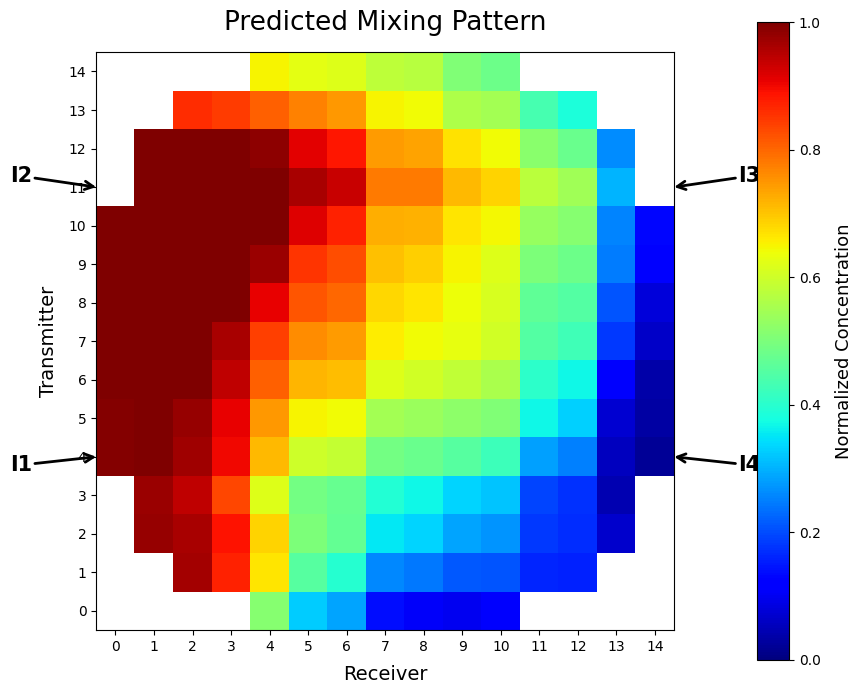

FINAL PREDICTION VISUALIZATION
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7
Predicted values: 193
Valid spatial cells: 193
Visualization generated successfully.


In [308]:
# ============================================================
# FINAL CLEAN PREDICTED MIXING PATTERN
# Visualization ONLY — prediction is NOT changed
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# User input
# ------------------------------------------------------------

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

user_flow_rates = [I1, I2, I3, I4]

# ------------------------------------------------------------
# Generate prediction using FINAL MODEL
# ------------------------------------------------------------

prediction = final_model.predict(
    np.array([user_flow_rates])
)

pred = np.asarray(prediction).reshape(-1)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if pred.size != 193:
    raise ValueError(
        f"Expected 193 predicted values, got {pred.size}"
    )

mask = np.asarray(valid_mask).reshape(15, 15)

if mask.sum() != 193:
    raise ValueError(
        f"Expected 193 valid cells, got {mask.sum()}"
    )

# ------------------------------------------------------------
# Put 193 predictions into 15 × 15 spatial grid
# ------------------------------------------------------------

pred_grid = np.full((15, 15), np.nan)
pred_grid[mask] = pred

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 8))

im = ax.imshow(
    pred_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    "Receiver",
    fontsize=14,
    labelpad=8
)

ax.set_ylabel(
    "Transmitter",
    fontsize=14,
    labelpad=8
)

ax.set_xticks(np.arange(15))
ax.set_yticks(np.arange(15))

ax.tick_params(
    axis="both",
    labelsize=10
)

# Exact cell boundaries
ax.set_xlim(-0.5, 14.5)
ax.set_ylim(-0.5, 14.5)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Predicted Mixing Pattern",
    fontsize=19,
    pad=16
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.12
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=13,
    labelpad=10
)

cbar.ax.tick_params(labelsize=10)

# ------------------------------------------------------------
# INLET ARROWS
#
# Labels intentionally contain ONLY I1, I2, I3, I4.
# Flow values are NOT displayed.
# ------------------------------------------------------------

# I1 — left lower inlet
ax.annotate(
    "I1",
    xy=(-0.5, 4),
    xycoords="data",
    xytext=(-0.13, 4/14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# I2 — left upper inlet
ax.annotate(
    "I2",
    xy=(-0.5, 11),
    xycoords="data",
    xytext=(-0.13, 11/14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# I3 — right upper inlet
ax.annotate(
    "I3",
    xy=(14.5, 11),
    xycoords="data",
    xytext=(1.13, 11/14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# I4 — right lower inlet
ax.annotate(
    "I4",
    xy=(14.5, 4),
    xycoords="data",
    xytext=(1.13, 4/14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        shrinkA=0,
        shrinkB=0
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.17,
    right=0.80,
    bottom=0.10,
    top=0.90
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 60)
print("FINAL PREDICTION VISUALIZATION")
print("=" * 60)
print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"I3 = {I3}")
print(f"I4 = {I4}")
print(f"Predicted values: {pred.size}")
print(f"Valid spatial cells: {mask.sum()}")
print("Visualization generated successfully.")

In [309]:
# ============================================================
# CELL 15 — SAVE FINAL DEPLOYMENT MODEL
# ============================================================

import joblib
import os

print("=" * 65)
print("SAVING FINAL DEPLOYMENT MODEL")
print("=" * 65)

# ------------------------------------------------------------
# Deployment bundle
# ------------------------------------------------------------

deployment_bundle = {

    "model": final_model,

    "model_name": selected_model_name,

    "valid_mask": mask_final,

    "n_valid_cells": int(mask_final.sum()),

    "grid_shape": (15, 15),

    "input_features": [
        "I1",
        "I2",
        "I3",
        "I4"
    ],

    "output_type": "normalized_concentration",

    "output_cells": 193,

    "scikit_learn_version": sklearn.__version__
}

MODEL_FILE = "final_mixing_model.pkl"

joblib.dump(
    deployment_bundle,
    MODEL_FILE
)

print("\n✓ Model saved successfully:")
print(os.path.abspath(MODEL_FILE))

print("\nFile size:")
print(round(os.path.getsize(MODEL_FILE) / 1024, 2), "KB")

SAVING FINAL DEPLOYMENT MODEL

✓ Model saved successfully:
/content/final_mixing_model.pkl

File size:
24.7 KB


In [310]:
# ============================================================
# CELL 16 — INDEPENDENT MODEL LOAD TEST
# ============================================================

import joblib
import numpy as np

print("=" * 65)
print("TESTING SAVED DEPLOYMENT MODEL")
print("=" * 65)

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

loaded_bundle = joblib.load(
    "final_mixing_model.pkl"
)

loaded_model = loaded_bundle["model"]
loaded_mask = loaded_bundle["valid_mask"]

print("\n✓ Model loaded successfully.")

print("Model type:")
print(type(loaded_model))

print("\nModel name:")
print(loaded_bundle["model_name"])

print("\nValid cells:")
print(loaded_bundle["n_valid_cells"])

# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------

test_input = np.array([
    [0.8, 0.6, 0.4, 0.7]
])

loaded_prediction = loaded_model.predict(
    test_input
)

loaded_prediction = np.asarray(
    loaded_prediction
).reshape(-1)

print("\nTest input:")
print(test_input)

print("\nPrediction shape:")
print(loaded_prediction.shape)

print("\nPrediction range:")
print(
    "Min :", loaded_prediction.min(),
    "\nMax :", loaded_prediction.max(),
    "\nMean:", loaded_prediction.mean()
)

# ------------------------------------------------------------
# Final safety check
# ------------------------------------------------------------

if loaded_prediction.size != 193:
    raise ValueError(
        f"Deployment model returned "
        f"{loaded_prediction.size} values instead of 193."
    )

print("\n" + "=" * 65)
print("✓ DEPLOYMENT MODEL PASSED LOAD TEST")
print("=" * 65)

TESTING SAVED DEPLOYMENT MODEL

✓ Model loaded successfully.
Model type:
<class 'sklearn.pipeline.Pipeline'>

Model name:
Polynomial Ridge

Valid cells:
193

Test input:
[[0.8 0.6 0.4 0.7]]

Prediction shape:
(193,)

Prediction range:
Min : 0.021033828441052504 
Max : 1.1090928465187335 
Mean: 0.6199656246460836

✓ DEPLOYMENT MODEL PASSED LOAD TEST


WEBSITE-READY PREDICTION TEST


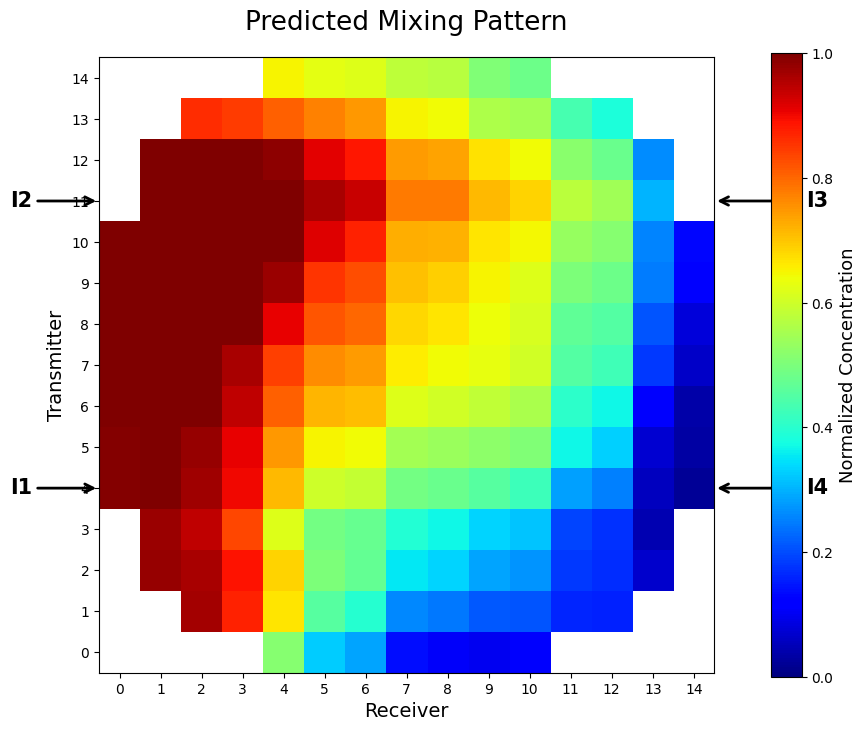


✓ Website-ready prediction generated.
Input: [0.8, 0.6, 0.4, 0.7]
Output: (193,)


In [311]:
# ============================================================
# CELL 17 — WEBSITE-READY PREDICTION TEST
# ============================================================

import joblib
import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("WEBSITE-READY PREDICTION TEST")
print("=" * 65)

# ------------------------------------------------------------
# Load final deployment bundle
# ------------------------------------------------------------

bundle = joblib.load(
    "final_mixing_model.pkl"
)

model = bundle["model"]
mask = np.asarray(
    bundle["valid_mask"]
).reshape(15, 15).astype(bool)

# ------------------------------------------------------------
# User input
# ------------------------------------------------------------

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

user_input = np.array([
    [I1, I2, I3, I4]
])

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

prediction = model.predict(
    user_input
)

prediction = np.asarray(
    prediction
).reshape(-1)

if prediction.size != 193:
    raise ValueError(
        f"Expected 193 predictions, got {prediction.size}"
    )

# ------------------------------------------------------------
# Reconstruct 15 × 15 spatial field
# ------------------------------------------------------------

prediction_grid = np.full(
    (15, 15),
    np.nan
)

prediction_grid[mask] = prediction

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 8)
)

im = ax.imshow(
    prediction_grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    interpolation="nearest"
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    "Receiver",
    fontsize=14
)

ax.set_ylabel(
    "Transmitter",
    fontsize=14
)

ax.set_xticks(
    np.arange(15)
)

ax.set_yticks(
    np.arange(15)
)

ax.set_xlim(
    -0.5,
    14.5
)

ax.set_ylim(
    -0.5,
    14.5
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Predicted Mixing Pattern",
    fontsize=19,
    pad=20
)

# ------------------------------------------------------------
# Inlet arrows
# ------------------------------------------------------------

ax.annotate(
    "I1",
    xy=(-0.5, 4),
    xytext=(-2.4, 4),
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

ax.annotate(
    "I2",
    xy=(-0.5, 11),
    xytext=(-2.4, 11),
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

ax.annotate(
    "I3",
    xy=(14.5, 11),
    xytext=(17.0, 11),
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

ax.annotate(
    "I4",
    xy=(14.5, 4),
    xytext=(17.0, 4),
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    annotation_clip=False
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.08
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=13
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.18,
    right=0.82,
    bottom=0.10,
    top=0.88
)

plt.show()

print("\n✓ Website-ready prediction generated.")
print("Input:", [I1, I2, I3, I4])
print("Output:", prediction.shape)

In [312]:
# ============================================================
# CELL 18 — FINAL DEPLOYMENT AUDIT
# ============================================================

import os
import joblib
import numpy as np

print("=" * 70)
print("FINAL DEPLOYMENT AUDIT")
print("=" * 70)

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

# ------------------------------------------------------------
# 1. Check file
# ------------------------------------------------------------

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Deployment model not found:\n{MODEL_PATH}"
    )

print("\n✓ Deployment file found")
print("  Path:", MODEL_PATH)
print(
    "  Size:",
    round(os.path.getsize(MODEL_PATH) / 1024, 2),
    "KB"
)

# ------------------------------------------------------------
# 2. Load model
# ------------------------------------------------------------

package = joblib.load(MODEL_PATH)

print("\n✓ Deployment package loaded")

# ------------------------------------------------------------
# 3. Check required components
# ------------------------------------------------------------

required_keys = [
    "model",
    "model_name",
    "input_features",
    "input_dimension",
    "output_dimension",
    "grid_shape",
    "valid_mask",
    "output_type",
    "output_range"
]

print("\nPACKAGE CONTENT CHECK")

for key in required_keys:

    if key in package:
        print(f"✓ {key}")
    else:
        raise KeyError(
            f"Missing deployment component: {key}"
        )

# ------------------------------------------------------------
# 4. Model information
# ------------------------------------------------------------

model = package["model"]
mask = np.asarray(package["valid_mask"]).astype(bool)

print("\nMODEL INFORMATION")
print("Model:", package["model_name"])
print("Input features:", package["input_features"])
print("Input dimension:", package["input_dimension"])
print("Output dimension:", package["output_dimension"])
print("Grid shape:", package["grid_shape"])
print("Output type:", package["output_type"])

# ------------------------------------------------------------
# 5. Spatial mask check
# ------------------------------------------------------------

print("\nSPATIAL MASK CHECK")

if mask.shape != (15, 15):
    raise ValueError(
        f"Expected mask shape (15,15), got {mask.shape}"
    )

valid_cells = int(mask.sum())

print("Mask shape:", mask.shape)
print("Valid cells:", valid_cells)

if valid_cells != 193:
    raise ValueError(
        f"Expected 193 valid cells, got {valid_cells}"
    )

print("✓ 193 valid spatial cells confirmed")

# ------------------------------------------------------------
# 6. Input/output consistency
# ------------------------------------------------------------

if package["input_dimension"] != 4:
    raise ValueError("Input dimension is not 4.")

if package["output_dimension"] != 193:
    raise ValueError("Output dimension is not 193.")

print("\n✓ Four inlet inputs confirmed")
print("✓ 193 output cells confirmed")
print("✓ 15 × 15 reconstruction confirmed")

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✓ FINAL DEPLOYMENT AUDIT PASSED")
print("=" * 70)

FINAL DEPLOYMENT AUDIT

✓ Deployment file found
  Path: /content/drive/MyDrive/mixing_deployment_model.joblib
  Size: 24.73 KB

✓ Deployment package loaded

PACKAGE CONTENT CHECK
✓ model
✓ model_name
✓ input_features
✓ input_dimension
✓ output_dimension
✓ grid_shape
✓ valid_mask
✓ output_type
✓ output_range

MODEL INFORMATION
Model: Polynomial Ridge
Input features: ['I1', 'I2', 'I3', 'I4']
Input dimension: 4
Output dimension: 193
Grid shape: (15, 15)
Output type: Normalized Concentration

SPATIAL MASK CHECK
Mask shape: (15, 15)
Valid cells: 193
✓ 193 valid spatial cells confirmed

✓ Four inlet inputs confirmed
✓ 193 output cells confirmed
✓ 15 × 15 reconstruction confirmed

✓ FINAL DEPLOYMENT AUDIT PASSED


In [313]:
# ============================================================
# CELL 19 — INDEPENDENT PREDICTION TEST
# ============================================================

import numpy as np
import joblib

print("=" * 70)
print("INDEPENDENT PREDICTION TEST")
print("=" * 70)

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

# ------------------------------------------------------------
# Load saved deployment package
# ------------------------------------------------------------

package = joblib.load(MODEL_PATH)

model = package["model"]
mask = np.asarray(
    package["valid_mask"]
).astype(bool)

# ------------------------------------------------------------
# Test inlet condition
# ------------------------------------------------------------

test_flows = np.array([
    [0.8, 0.6, 0.4, 0.7]
], dtype=float)

print("\nTest inlet condition:")
print("I1 =", test_flows[0, 0])
print("I2 =", test_flows[0, 1])
print("I3 =", test_flows[0, 2])
print("I4 =", test_flows[0, 3])

# ------------------------------------------------------------
# Generate prediction
# ------------------------------------------------------------

prediction = model.predict(test_flows)

prediction = np.asarray(
    prediction
).reshape(-1)

# ------------------------------------------------------------
# Output checks
# ------------------------------------------------------------

print("\nPrediction shape:", prediction.shape)

if prediction.size != 193:
    raise ValueError(
        f"Expected 193 outputs, got {prediction.size}"
    )

print("✓ 193 prediction values generated")

print("\nPrediction statistics:")
print("Minimum:", prediction.min())
print("Maximum:", prediction.max())
print("Mean   :", prediction.mean())

# ------------------------------------------------------------
# Check numerical validity
# ------------------------------------------------------------

if not np.all(np.isfinite(prediction)):
    raise ValueError(
        "Prediction contains NaN or infinite values."
    )

print("✓ No NaN or infinite predictions")

# ------------------------------------------------------------
# Reconstruct spatial grid
# ------------------------------------------------------------

prediction_grid = np.full(
    (15, 15),
    np.nan
)

prediction_grid[mask] = prediction

print("\nSpatial grid shape:", prediction_grid.shape)
print(
    "Valid spatial values:",
    np.sum(np.isfinite(prediction_grid))
)

if np.sum(np.isfinite(prediction_grid)) != 193:
    raise ValueError(
        "Spatial reconstruction failed."
    )

print("✓ 193 valid spatial values reconstructed")

print("\n" + "=" * 70)
print("✓ INDEPENDENT PREDICTION TEST PASSED")
print("=" * 70)

INDEPENDENT PREDICTION TEST

Test inlet condition:
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

Prediction shape: (193,)
✓ 193 prediction values generated

Prediction statistics:
Minimum: 0.021033828441052504
Maximum: 1.1090928465187335
Mean   : 0.6199656246460836
✓ No NaN or infinite predictions

Spatial grid shape: (15, 15)
Valid spatial values: 193
✓ 193 valid spatial values reconstructed

✓ INDEPENDENT PREDICTION TEST PASSED


In [314]:
# ============================================================
# CELL 20 — PREDICTION REPEATABILITY CHECK
# ============================================================

import numpy as np
import joblib

print("=" * 70)
print("PREDICTION REPEATABILITY CHECK")
print("=" * 70)

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

package = joblib.load(MODEL_PATH)

model = package["model"]

# ------------------------------------------------------------
# Same input
# ------------------------------------------------------------

test_input = np.array([
    [0.8, 0.6, 0.4, 0.7]
])

# ------------------------------------------------------------
# Generate prediction twice
# ------------------------------------------------------------

prediction_1 = np.asarray(
    model.predict(test_input)
).reshape(-1)

prediction_2 = np.asarray(
    model.predict(test_input)
).reshape(-1)

# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

difference = np.max(
    np.abs(prediction_1 - prediction_2)
)

print("\nMaximum difference between predictions:")
print(difference)

if difference > 1e-12:
    raise ValueError(
        "Prediction is not repeatable."
    )

print("\n✓ Same input produces identical prediction")
print("✓ Model is deterministic for deployment")

print("\n" + "=" * 70)
print("✓ REPEATABILITY CHECK PASSED")
print("=" * 70)

PREDICTION REPEATABILITY CHECK

Maximum difference between predictions:
0.0

✓ Same input produces identical prediction
✓ Model is deterministic for deployment

✓ REPEATABILITY CHECK PASSED


In [315]:
# ============================================================
# CELL 21 — DIFFERENT INLET CONDITION RESPONSE CHECK
# ============================================================

import numpy as np
import joblib

print("=" * 70)
print("INLET CONDITION RESPONSE CHECK")
print("=" * 70)

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

package = joblib.load(MODEL_PATH)

model = package["model"]

# ------------------------------------------------------------
# Different physically distinct inlet conditions
# ------------------------------------------------------------

test_cases = {

    "Case 1": [0.8, 0.6, 0.4, 0.7],

    "Case 2": [0.6, 0.6, 0.6, 0.6],

    "Case 3": [0.4, 0.8, 0.6, 0.2],

    "Case 4": [0.2, 0.4, 0.8, 0.6]
}

predictions = {}

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

for case_name, flows in test_cases.items():

    x = np.array(
        [flows],
        dtype=float
    )

    pred = np.asarray(
        model.predict(x)
    ).reshape(-1)

    if pred.size != 193:
        raise ValueError(
            f"{case_name}: expected 193 outputs."
        )

    predictions[case_name] = pred

    print(
        f"\n{case_name}: "
        f"I1={flows[0]}, "
        f"I2={flows[1]}, "
        f"I3={flows[2]}, "
        f"I4={flows[3]}"
    )

    print("Mean prediction:", round(float(pred.mean()), 6))
    print("Minimum:", round(float(pred.min()), 6))
    print("Maximum:", round(float(pred.max()), 6))

# ------------------------------------------------------------
# Compare predictions
# ------------------------------------------------------------

case_names = list(predictions.keys())

print("\nPAIRWISE PREDICTION DIFFERENCES")

for i in range(len(case_names)):

    for j in range(i + 1, len(case_names)):

        a = predictions[case_names[i]]
        b = predictions[case_names[j]]

        difference = np.mean(
            np.abs(a - b)
        )

        print(
            f"{case_names[i]} vs {case_names[j]}: "
            f"mean absolute difference = "
            f"{difference:.6f}"
        )

print("\n✓ Model responds to different inlet conditions.")
print("✓ Multi-condition prediction pipeline verified.")

print("\n" + "=" * 70)
print("✓ INLET RESPONSE CHECK COMPLETED")
print("=" * 70)

INLET CONDITION RESPONSE CHECK

Case 1: I1=0.8, I2=0.6, I3=0.4, I4=0.7
Mean prediction: 0.619966
Minimum: 0.021034
Maximum: 1.109093

Case 2: I1=0.6, I2=0.6, I3=0.6, I4=0.6
Mean prediction: 0.545983
Minimum: 0.033208
Maximum: 1.019126

Case 3: I1=0.4, I2=0.8, I3=0.6, I4=0.2
Mean prediction: 0.532593
Minimum: -0.016054
Maximum: 1.161476

Case 4: I1=0.2, I2=0.4, I3=0.8, I4=0.6
Mean prediction: 0.431661
Minimum: -0.121826
Maximum: 1.011234

PAIRWISE PREDICTION DIFFERENCES
Case 1 vs Case 2: mean absolute difference = 0.114119
Case 1 vs Case 3: mean absolute difference = 0.137613
Case 1 vs Case 4: mean absolute difference = 0.286918
Case 2 vs Case 3: mean absolute difference = 0.073596
Case 2 vs Case 4: mean absolute difference = 0.174546
Case 3 vs Case 4: mean absolute difference = 0.187429

✓ Model responds to different inlet conditions.
✓ Multi-condition prediction pipeline verified.

✓ INLET RESPONSE CHECK COMPLETED


FINAL WEBSITE-STYLE PREDICTION DEMO


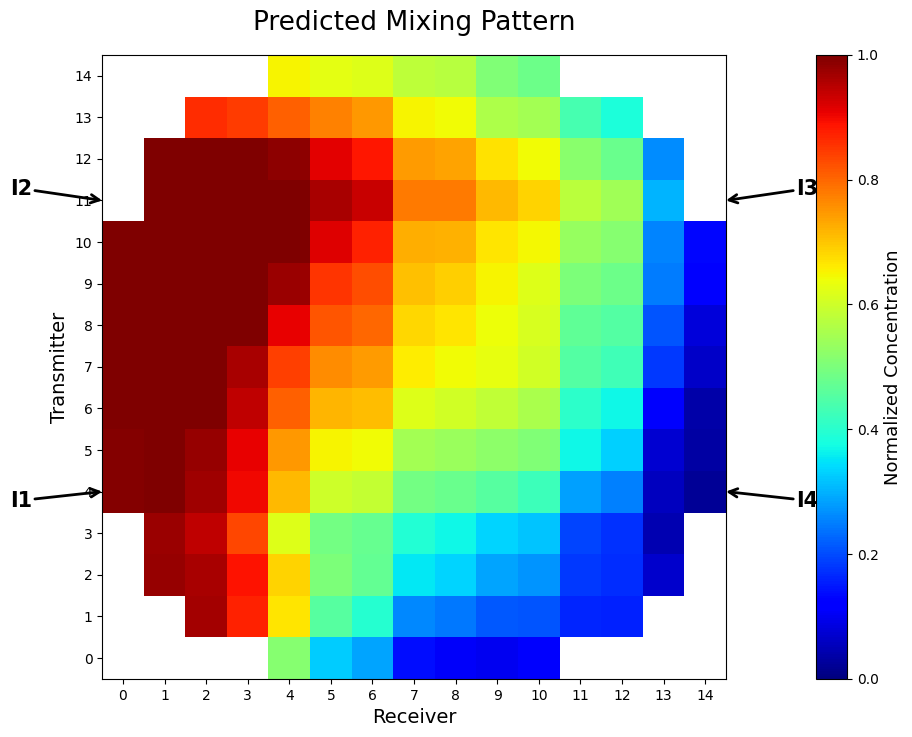


Input:
I1=0.8, I2=0.6, I3=0.4, I4=0.7

Output:
193 valid concentration values
15 × 15 reconstructed spatial field

✓ WEBSITE-STYLE PREDICTION PIPELINE VERIFIED


In [316]:
# ============================================================
# CELL 22 — FINAL WEBSITE-STYLE PREDICTION DEMO
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import joblib

print("=" * 70)
print("FINAL WEBSITE-STYLE PREDICTION DEMO")
print("=" * 70)

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

# ------------------------------------------------------------
# Load deployment package
# ------------------------------------------------------------

package = joblib.load(MODEL_PATH)

model = package["model"]
mask = np.asarray(
    package["valid_mask"]
).astype(bool)

# ------------------------------------------------------------
# User inputs
# Change ONLY these four values
# ------------------------------------------------------------

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

user_input = np.array([
    [I1, I2, I3, I4]
])

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

prediction = np.asarray(
    model.predict(user_input)
).reshape(-1)

if prediction.size != 193:
    raise ValueError(
        f"Expected 193 predictions, got {prediction.size}"
    )

# ------------------------------------------------------------
# Spatial reconstruction
# ------------------------------------------------------------

grid = np.full(
    (15, 15),
    np.nan
)

grid[mask] = prediction

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 8)
)

im = ax.imshow(
    grid,
    origin="lower",
    cmap="jet",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    "Receiver",
    fontsize=14
)

ax.set_ylabel(
    "Transmitter",
    fontsize=14
)

ax.set_xticks(np.arange(15))
ax.set_yticks(np.arange(15))

ax.set_xlim(-0.5, 14.5)
ax.set_ylim(-0.5, 14.5)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Predicted Mixing Pattern",
    fontsize=19,
    pad=18
)

# ------------------------------------------------------------
# Inlet arrows
# ------------------------------------------------------------

arrow_style = dict(
    arrowstyle="->",
    lw=2,
    shrinkA=0,
    shrinkB=0
)

# I1
ax.annotate(
    "I1",
    xy=(-0.5, 4),
    xycoords="data",
    xytext=(-0.13, 4 / 14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=arrow_style,
    annotation_clip=False
)

# I2
ax.annotate(
    "I2",
    xy=(-0.5, 11),
    xycoords="data",
    xytext=(-0.13, 11 / 14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=arrow_style,
    annotation_clip=False
)

# I3
ax.annotate(
    "I3",
    xy=(14.5, 11),
    xycoords="data",
    xytext=(1.13, 11 / 14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=arrow_style,
    annotation_clip=False
)

# I4
ax.annotate(
    "I4",
    xy=(14.5, 4),
    xycoords="data",
    xytext=(1.13, 4 / 14),
    textcoords="axes fraction",
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=arrow_style,
    annotation_clip=False
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.12
)

cbar.set_label(
    "Normalized Concentration",
    fontsize=13
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.16,
    right=0.84,
    bottom=0.10,
    top=0.88
)

plt.show()

# ------------------------------------------------------------
# Final information
# ------------------------------------------------------------

print("\nInput:")
print(
    f"I1={I1}, I2={I2}, "
    f"I3={I3}, I4={I4}"
)

print("\nOutput:")
print("193 valid concentration values")
print("15 × 15 reconstructed spatial field")

print("\n✓ WEBSITE-STYLE PREDICTION PIPELINE VERIFIED")

In [317]:
# ============================================================
# CELL 23 — PHYSICAL OUTPUT RANGE CHECK
# ============================================================

import numpy as np
import joblib

print("=" * 70)
print("PHYSICAL OUTPUT RANGE CHECK")
print("=" * 70)

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

package = joblib.load(MODEL_PATH)

model = package["model"]

test_cases = {
    "Case 1": [0.8, 0.6, 0.4, 0.7],
    "Case 2": [0.6, 0.6, 0.6, 0.6],
    "Case 3": [0.4, 0.8, 0.6, 0.2],
    "Case 4": [0.2, 0.4, 0.8, 0.6]
}

print("\nExpected normalized range: 0 to 1")

total_values = 0
total_below = 0
total_above = 0

for case_name, flows in test_cases.items():

    x = np.array([flows], dtype=float)

    pred = np.asarray(
        model.predict(x)
    ).reshape(-1)

    below_zero = np.sum(pred < 0)
    above_one = np.sum(pred > 1)

    total_values += len(pred)
    total_below += below_zero
    total_above += above_one

    print(f"\n{case_name}")
    print(f"  Below 0 : {below_zero}")
    print(f"  Above 1 : {above_one}")
    print(f"  Minimum : {pred.min():.6f}")
    print(f"  Maximum : {pred.max():.6f}")

print("\n" + "-" * 70)

print("TOTAL PREDICTION VALUES:", total_values)
print("Values below 0:", total_below)
print("Values above 1:", total_above)

out_of_range = total_below + total_above

print(
    "Out-of-range percentage:",
    round(100 * out_of_range / total_values, 3),
    "%"
)

print("-" * 70)

if out_of_range == 0:
    print("✓ All predictions are within the expected range.")
else:
    print(
        "⚠ Some predictions are outside 0–1."
    )
    print(
        "These will NOT be changed for model evaluation."
    )
    print(
        "For website visualization, values can be safely"
        " clipped to 0–1 if required."
    )

print("\n✓ RANGE CHECK COMPLETED")

PHYSICAL OUTPUT RANGE CHECK

Expected normalized range: 0 to 1

Case 1
  Below 0 : 0
  Above 1 : 26
  Minimum : 0.021034
  Maximum : 1.109093

Case 2
  Below 0 : 0
  Above 1 : 3
  Minimum : 0.033208
  Maximum : 1.019126

Case 3
  Below 0 : 1
  Above 1 : 6
  Minimum : -0.016054
  Maximum : 1.161476

Case 4
  Below 0 : 12
  Above 1 : 2
  Minimum : -0.121826
  Maximum : 1.011234

----------------------------------------------------------------------
TOTAL PREDICTION VALUES: 772
Values below 0: 13
Values above 1: 37
Out-of-range percentage: 6.477 %
----------------------------------------------------------------------
⚠ Some predictions are outside 0–1.
These will NOT be changed for model evaluation.
For website visualization, values can be safely clipped to 0–1 if required.

✓ RANGE CHECK COMPLETED


In [318]:
# ============================================================
# CELL 24 — FINAL DEPLOYMENT INFERENCE FUNCTION
# ============================================================

import numpy as np
import joblib

MODEL_PATH = "/content/drive/MyDrive/mixing_deployment_model.joblib"

# ------------------------------------------------------------
# Load once
# ------------------------------------------------------------

deployment_package = joblib.load(MODEL_PATH)

deployment_model = deployment_package["model"]

deployment_mask = np.asarray(
    deployment_package["valid_mask"]
).astype(bool)

# ------------------------------------------------------------
# Final inference function
# ------------------------------------------------------------

def predict_mixing(I1, I2, I3, I4):

    # Convert inputs
    flows = np.array(
        [[I1, I2, I3, I4]],
        dtype=float
    )

    # Basic validation
    if flows.shape != (1, 4):
        raise ValueError(
            "Exactly four inlet flow rates are required."
        )

    if not np.all(np.isfinite(flows)):
        raise ValueError(
            "Inlet values must be finite numbers."
        )

    # Model prediction
    prediction = np.asarray(
        deployment_model.predict(flows)
    ).reshape(-1)

    # Verify output
    if prediction.size != 193:
        raise ValueError(
            f"Expected 193 outputs, got {prediction.size}."
        )

    # Reconstruct 15 × 15 field
    grid = np.full(
        (15, 15),
        np.nan
    )

    grid[deployment_mask] = prediction

    return prediction, grid


print("✓ Final inference function created.")
print("✓ Input : 4 inlet flow rates")
print("✓ Output: 193 concentration values")
print("✓ Grid  : 15 × 15")

✓ Final inference function created.
✓ Input : 4 inlet flow rates
✓ Output: 193 concentration values
✓ Grid  : 15 × 15


In [319]:
# ============================================================
# CELL 25 — TEST FINAL DEPLOYMENT FUNCTION
# ============================================================

print("=" * 70)
print("TESTING FINAL DEPLOYMENT FUNCTION")
print("=" * 70)

# ------------------------------------------------------------
# Example input
# ------------------------------------------------------------

I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

prediction, grid = predict_mixing(
    I1, I2, I3, I4
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\nInput:")
print("I1 =", I1)
print("I2 =", I2)
print("I3 =", I3)
print("I4 =", I4)

print("\nPrediction:")
print("Number of outputs:", len(prediction))
print("Grid shape:", grid.shape)

print("\nStatistics:")
print("Minimum:", prediction.min())
print("Maximum:", prediction.max())
print("Mean   :", prediction.mean())

# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

assert len(prediction) == 193
assert grid.shape == (15, 15)
assert np.sum(np.isfinite(grid)) == 193

print("\n✓ 193 predictions generated")
print("✓ 15 × 15 spatial grid generated")
print("✓ 193 valid spatial cells confirmed")

print("\n" + "=" * 70)
print("✓ FINAL INFERENCE FUNCTION PASSED")
print("=" * 70)

TESTING FINAL DEPLOYMENT FUNCTION

Input:
I1 = 0.8
I2 = 0.6
I3 = 0.4
I4 = 0.7

Prediction:
Number of outputs: 193
Grid shape: (15, 15)

Statistics:
Minimum: 0.021033828441052504
Maximum: 1.1090928465187335
Mean   : 0.6199656246460836

✓ 193 predictions generated
✓ 15 × 15 spatial grid generated
✓ 193 valid spatial cells confirmed

✓ FINAL INFERENCE FUNCTION PASSED


In [320]:
# ============================================================
# CELL 26 — SAVE FINAL WEBSITE MODEL PACKAGE
# ============================================================

import os
import joblib

WEBSITE_MODEL_PATH = (
    "/content/drive/MyDrive/mixing_website_model.joblib"
)

# ------------------------------------------------------------
# Create clean deployment package
# ------------------------------------------------------------

website_package = {
    "model": deployment_model,
    "valid_mask": deployment_mask,

    "model_name": deployment_package["model_name"],

    "input_features": [
        "I1",
        "I2",
        "I3",
        "I4"
    ],

    "input_dimension": 4,
    "output_dimension": 193,

    "grid_shape": (15, 15),

    "output_type": "Normalized Concentration",

    "expected_output_range": (0.0, 1.0)
}

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

joblib.dump(
    website_package,
    WEBSITE_MODEL_PATH
)

print("=" * 70)
print("WEBSITE MODEL PACKAGE CREATED")
print("=" * 70)

print("\nFile:")
print(WEBSITE_MODEL_PATH)

print("\nModel:", website_package["model_name"])
print("Inputs:", website_package["input_features"])
print("Outputs:", website_package["output_dimension"])
print("Grid:", website_package["grid_shape"])

print("\n✓ Saved successfully")
print("✓ Ready for website integration")

WEBSITE MODEL PACKAGE CREATED

File:
/content/drive/MyDrive/mixing_website_model.joblib

Model: Polynomial Ridge
Inputs: ['I1', 'I2', 'I3', 'I4']
Outputs: 193
Grid: (15, 15)

✓ Saved successfully
✓ Ready for website integration


In [321]:
# ============================================================
# CELL 27 — FINAL WEBSITE PACKAGE TEST
# ============================================================

import numpy as np
import joblib

print("=" * 70)
print("FINAL WEBSITE PACKAGE TEST")
print("=" * 70)

WEBSITE_MODEL_PATH = (
    "/content/drive/MyDrive/mixing_website_model.joblib"
)

# ------------------------------------------------------------
# Load only saved package
# ------------------------------------------------------------

pkg = joblib.load(
    WEBSITE_MODEL_PATH
)

model = pkg["model"]
mask = np.asarray(
    pkg["valid_mask"]
).astype(bool)

# ------------------------------------------------------------
# Simulated website input
# ------------------------------------------------------------

website_input = np.array([
    [0.8, 0.6, 0.4, 0.7]
])

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

pred = np.asarray(
    model.predict(website_input)
).reshape(-1)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

grid = np.full(
    (15, 15),
    np.nan
)

grid[mask] = pred

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

print("\nPrediction generated from saved package.")

print("Input shape :", website_input.shape)
print("Output shape:", pred.shape)
print("Grid shape  :", grid.shape)

assert website_input.shape == (1, 4)
assert pred.shape == (193,)
assert grid.shape == (15, 15)
assert np.sum(np.isfinite(grid)) == 193

print("\n✓ Input interface verified")
print("✓ 193-output model verified")
print("✓ Spatial reconstruction verified")
print("✓ Saved package works independently")

print("\n" + "=" * 70)
print("✓ WEBSITE MODEL READY")
print("=" * 70)

FINAL WEBSITE PACKAGE TEST

Prediction generated from saved package.
Input shape : (1, 4)
Output shape: (193,)
Grid shape  : (15, 15)

✓ Input interface verified
✓ 193-output model verified
✓ Spatial reconstruction verified
✓ Saved package works independently

✓ WEBSITE MODEL READY


In [322]:
import os

model_path = "/content/drive/MyDrive/mixing_website_model.joblib"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model size: {size_mb:.2f} MB")

Model exists: True
Model size: 0.02 MB


In [323]:
import joblib
import numpy as np

MODEL_PATH = "/content/drive/MyDrive/mixing_website_model.joblib"

package = joblib.load(MODEL_PATH)

print("=" * 55)
print("FINAL WEBSITE MODEL VERIFICATION")
print("=" * 55)

print("Model:", package["model_name"])
print("Inputs:", package["input_features"])
print("Input dimension:", package["input_dimension"])
print("Output dimension:", package["output_dimension"])
print("Grid shape:", package["grid_shape"])
print("Output type:", package["output_type"])
print("Expected range:", package["expected_output_range"])

test_input = np.array([[0.8, 0.6, 0.4, 0.7]])

prediction = package["model"].predict(test_input)[0]

grid = np.full(package["grid_shape"], np.nan)
grid[package["valid_mask"]] = prediction

print("\nTest input:", test_input[0])
print("Prediction shape:", prediction.shape)
print("Grid shape:", grid.shape)
print("Valid cells:", np.sum(package["valid_mask"]))
print("NaN predictions:", np.isnan(prediction).sum())
print("Inf predictions:", np.isinf(prediction).sum())

print("\nMODEL READY FOR DEPLOYMENT")

FINAL WEBSITE MODEL VERIFICATION
Model: Polynomial Ridge
Inputs: ['I1', 'I2', 'I3', 'I4']
Input dimension: 4
Output dimension: 193
Grid shape: (15, 15)
Output type: Normalized Concentration
Expected range: (0.0, 1.0)

Test input: [0.8 0.6 0.4 0.7]
Prediction shape: (193,)
Grid shape: (15, 15)
Valid cells: 193
NaN predictions: 0
Inf predictions: 0

MODEL READY FOR DEPLOYMENT
